# Extraction demo

Minimal walk-through of the production data path:

1. `DocumentDownloader` fetches one PDF from HuggingFace and persists it to SeaweedFS (durable copy), with a local scratch copy for parsing.
2. Extraction uses agent-substrate's own `PDFLoader` (pdfplumber, falling back to pypdf) — one `Document` per page — rather than a separate parsing stack.

Requires `make infra-up` running (Postgres + SeaweedFS).

In [3]:
from pdfqa_rag.config import AppConfig
from pdfqa_rag.data.downloader import DocumentDownloader
from pdfqa_rag.storage.factory import build_blob_store

FILE_NAME, DATASET = "1601.04012", "PaperText"

cfg = AppConfig()
blob_store = build_blob_store(cfg.storage)
await blob_store.connect()

downloader = DocumentDownloader(format="pdf", blob_store=blob_store)

In [4]:
from substrate.capabilities.knowledge.extraction_client import ExtractionClient

# .load() first, just to trigger the download/cache — PDFLoader parsing
# inside it still runs but you ignore its result, or use is_cached()/
# _local_path() directly to skip it entirely.
pdf_path = downloader._local_path(FILE_NAME, DATASET)
if not pdf_path.exists():
    await downloader.load(FILE_NAME, DATASET)

# Default client timeout (90s) is fine for a couple of pages but this is a
# 62-page paper — PP-StructureV3 is ~1min/page on CPU, so give it real
# headroom rather than silently timing out into success=False.
client = ExtractionClient(base_url="http://localhost:8021", timeout_s=3600.0)
result = await client.extract(
    pdf_path.read_bytes(),
    filename=pdf_path.name,
    content_type="application/pdf",
)

print(result.success, result.page_count, result.engine)
if not result.success:
    print("error:", result.error)
text = result.text  # or iterate result.pages for page-level text


True 62 paddleocr


## Page 1

Detecting and Extracting Events from Text  Documents

JUGAL KALITA, University of Colorado, Colorado Springs

Events of various kinds are mentioned and discussed in text documents, whether they are books,news articles, blogs or microblog feeds. The paper starts by giving an overview of how events are treated in linguistics and philosophy. We follow this discussion by surveying how events and associated information are handled in computationally. In particular, we look at how textual documents can be mined to extract events and ancillary information. These days, it is mostly through the application of various machine learning techniques. We also discuss applications of event detection and extraction systems, particularly in summarization, in the medical domain and in the context of Twitter posts. We end the paper with a discussion of challenges and future directions.

Categories and Subject Descriptors: .. [...]: .

General Terms:.

Additional Key Words and Phrases: Information Retrieval, Event Detection

1. INTRODUCTION

Among the several senses that The Oxford English Dictionaryl, the most venerable dictionary of English, provides for the word event, are the following.

la the (actual or contemplated) fact of anything happening; the occurrence of.2a anything that happens, or is contemplated as happening; an incident, occurrence.2d (In modern use, chiefly restricted to) occurrences of some importance.

Although an event may refer to anything that happens, we are usually interested in occurrences that are of some importance. We want to extract such events from textual documents. In order to extract important events or events of a specific type, it is likely that we have to identify all events in a document to start with.

Consider the first paragraphs of the article on the Battle of Fredericksburg in the English Wikipedia, accessed on May 5, 2012. We have highlighted the “events" in the paragraph.

The Battle of Fredericksburg was fought December 11-15, 1862, in and around Fredericksburg, Virginia, between General Robert E. Lee's Con

1http://www/oed.com

Jugal Kalita is a professor in the Department of Computer Science, University of Colorado, Colorado Springs, CO 80918 USA .
Permission to make digital/hard copy of all or part of this material without fee for personal or classroom use provided that the copies are not made or distributed for profit or commercial advantage, the ACM copyright/server notice, the title of the publication, and its date appear, and notice is given that copying is by permission of the ACM, Inc. To copy otherwise, to republish,to post on servers, or to redistribute to lists requires prior specific permission and/or a fee.©2022ACM 1529-3785/2022/0700-0001 $5.00

ACM Transactions, Vol. V, No. N, March 2022, Pages 1-62.

## Page 2

2

federate Army of Northern Virginia and the Union Army of the Potomac, commanded by Maj. Gen. Ambrose E. Burnside. The Union army's futile frontal assaults on December 13 against entrenched Confederate defenders on the heights behind the city is remembered as one of the most one-sided battles of the American Civil War, with Union casualties more than twice as heavy as those suffered by the Confederates.

The paragraph contains two fairly long sentences with several“events", mentioned using the following words: fought, commanded, assaults, entrenched, remembered, casualties and suffered. Some of these "events" are described in terms of verbs whereas the others are in terms of nouns. Here fought, commanded, assaults, battles definitely seem to be “events" that have durations or are durative. Entrenched seems to talk about a state, whereas it is possible that suffered talks about something punctual (i.e., takes a moment or point of time) or can be durative (i.e., takes a longer period of time) as well. The act of remembering by an individual is usually considered to happen momentarily, i.e., forgotten things come back to mind at an instant of time. But, in this paragraph it is given in passive voice and hence, it is unclear who the actor is, possibly a lot different people at different points of time

211i1i11。④ferent, but the essence is that there are several events mentioned in the paragraph and the objective in event extraction is to extract as many of them as possible in an automated fashion. For example, someone may not pick out remembered as an event that took place. Some others may not want to say that entrenched is an event.In addition, if one is asked to pick an important event, responses may vary from person to person. Finally, if one is asked to summarize the paragraph, depending on the person asked the summary may vary. A summary prepared by the author of this article is given below.

The Battle of Fredericksburg, fought December 11-12, 1862, was one of the most one-sided battles of the American Civil War, with heavy Union casualties.

Obviously, there are many other possibilities for summarization. However, the idea is that identification of events and their participants may play a significant role in summarizing a document.

This paper discusses the extraction of events and their attributes from unstructured English text. It is an survey of research in extracting event descriptions from textual documents. In addition, we discuss how the idea of event extraction can be used in application domains such as summarization of a document. We also discuss application of event extraction in the biomedical domain and in the context of Twitter messages.

The rest of the paper is organized in the following manner. Section 2 provides a description of research in linguistics and philosophy. The author believes that such a background, at least at a basic level, is necessary to understand and develop the approaches and algorithms for automatic computational detection and extraction of events and their participants from textual documents. Section 4 discusses approaches used in extracting events from textual documents. Most approaches these

ACM Transactions, Vol. V, No. N, March 2022.

## Page 3

3

days use machine learning techniques.

2. EVENTS IN LINGUISTICS AND PHILOSOPHY

Real world events are things that take place or happen. In this section, we present an overview of how real events are represented in terms of language. In particular,we discuss classification of events and features necessary for such classification.We follow this by presenting the preferred way among philosophers to represent events in terms of logic. We bring this section to an end by presenting some of the structures ascribed to events by linguists or philosophers working at an abstract level.

The reason for the inclusion of this section in the paper is to set the context for the discussions in the following sections on the practical task of extracting events. Practical systems do not usually follow linguistic niceties although they draw inspiration from linguistics or philosophy.

2.1 Classifying Events

There have been many attempts at classifying linguistic events. Below, we briefly discuss a few. The primary focus when linguists discuss events is on the verb present in a sentence. Nouns, adjectives and other elements present in a sentence provide arguments for the verb.

Aristotle (as presented in [Barnes et al. 1984]) classified verbs that denote something happening into three classes: actuality, movement and action. An actuality represents the existence of a thing or things; this is called state by others (e.g.,[Rosen 1999]). An examples of actuality can be seen in the sentence Jon is ill. A movement is an incomplete process or something that takes time but doesn't have an inherent end. An example of movement is seen in the sentence Jon is running.An action is something that takes time and has an inherent end. An example of an action is present in the sentence Jon is building α house. In other words, Aristotle distinguished between states and events and then events.

[Kenny 2003] lists verbs that belong to the three Aristotelian classes and develops membership criteria for the classes. Kenny renamed the classes as states, activities (actions without inherent end) and performances (actions with inherent ends).Kenny's membership criteria are based on semantic entailments about whether the event can be considered to have taken place when it is still in progress. For example,during any point when we say Jon is running, we can consider that the activity of running has taken place. In other words Jon is running entails Jon has run. Thus,run is an activity. In contrast, when we say Joh is taking the final, we cannot say that Jon has taken the final. In other words, the first does not entail the second.Thus, the main difference between an activity and a performance is what is called delimitation. A delimited event has a natural end.......HCCA1100②e28s

[Vendler 1967] developed a 4-way classification scheme for linguistic events and [Dowty 1979] developed a set of criteria for membership in the classes. The classes enumerated by Dowty are: states, activities, achievements and accomplishments.The definitions are given below.

—Activities: Events that take place over a certain period of time, but do not necessarily have a fixed termination point. Examples; Jon walked for an hour,

ACM Transactions, Vol. V, No. N, March 2022.

## Page 4

4

Table I. Nomenclatures used by linguists to classify events

and Jon is driving the car.

-Accomplishments: Events that happen over a certain period of time and then end. Examples: Jon built a house in a month, and Jon is taking the final.

Achievements: These are events that occur instantaneously and lack continuous tenses. Examples: Jon finished the final in 45 minutes and The vase broke.

-States: These are non-actions that hold for a certain period of time, but lack continuous tenses. Examples: Jon knows the answer and Jon likes Mary.

[Smith 1997] adopts the same classification as Vendler and Dowty, but divides achievements into two classes. The first one is still called achievements, but the second one is called semelfactives. In this new scheme, achievements are instantaneous (that is, the beginning of the event is the same as its end) culminating events,but semelfactives are events with no duration that result in no change of state. An example of a semelfactive is: Jon knocked on the door.

Table I presents the nomenclatures introduced by various linguists in one place.There are many variations of the schemes given here, although we do not discuss them in this paper.

In the early work on event classification, Aristotle, Vendler and others assume that what needs to be classified is the verb. However, many have concluded that it is impossible to classify a verb into a specific class. It is more appropriate to say that a clause containing an event has a class, and the classification of such a clause depends not only upon the verb, but also on other material present in the clause [Rosen 1996; Dowty 1979; 1991; Ritter and Rosen 1996]. In other words,the classification must be compositional or must depend on various features of the clause, not exclusively verb-based. There is also substantial evidence that sentence material other than the verb can change the overall event type. For example,addition of a direct object can change an activity to an accomplishment [Rosen 1999], as in the following examples.

—Bill ran for five minutes/*in five minutes: activity

—Bill ran the mile *for 5 minutes/in 5 minutes: accomplishment

2.2 Parameters of Event Classes

Many authors in linguistics have delved deeper into the nature of event classes and have tried to come up with features or characteristics that can be used to identify whether something (verb or a clause) belongs to a particular event class or not.These features or characteristics are necessary to describe the structure of events in a theoretical sense. Description of event structure usually refers to the actual words used (lexical features or characteristics) and also the structure of clause or

ACM Transactions, Vol. V, No. N, March 2022.

**table** (confidence 0.96)

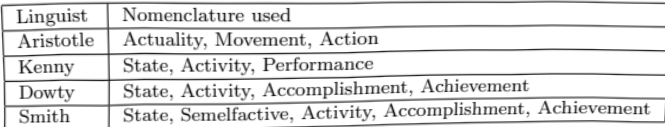

> table

## Page 5

5

sentence (syntactic features or characteristics). Identification of such features may be described as finding parameters of event types or parameterization of event tupes.

11。a。1一espoused by Vendler. These include [Verkuyl 1996; Carlson 1981; Moens 1987;Hoeksema 1983; Mourelatos 1978; Ter Meulen 1983; 1997] and others. We will only briefly touch upon such work in this paper. Our objective is to impress upon the reader that identification of features of event classes is considered an important task by linguists.

For example, [Verkuyl 1996] describes Vendler's classes with two binary features or parameters: continuousness: whether an event has duration, and boundedness:whether an event has a (natural) terminal point or endpoint. Using these two features, the four Vendler classes can be parameterized as follows.

state : -bounded, -continuous

activity: -bounded, +continuous

achievement：+bounded, -continuous

accomplishment:+bounded, +continuous

[Hoeksema 1983; Mourelatos 1978] introduce the notion of countability while discussing event classes. This is similar to the mass-count opposition in nouns.Terminating events can be counted, but non-terminating processes cannot. Hoeksema introduces two binary features: count and duration to obtain Vendler's classes as seen below. The feature duration refers to whether the event takes place over time.

state : -count, -duration

activity: -count, +duration

achievement : +count, -duration

accomplishment:+count, +duration

[Moens 1987] refines Vendler's classes by adding a class much like Smith's semelfac tives [Smith 1997]. He suggests that, in addition to states, there are four event types:culmination, culminated process, point, and process. He uses two binary features or parameters: consequence identifying termination or culmination, and atomic or non-atomic (which Moens called extended). Atomic is also called momentous or pointed. Moen's classification is given below, along with the features and examples.

culmination: +consequence, +atomic (examples: recognize, win the race)

culminated process : +consequence, -atomic (examples:build a house)

point : -consequence, +atomic (example: hiccup, tap, wink)

process: -consequence, -atomic (example: run, swim, play the piano)

state : (examples: understand, love, resemble)

Moens also claims that culminated process is an event class whose members are made up of smaller atomic units. In particular, a culminated process is a process with a consequent state. This insight that events can be decomposed into sub-events was used later by others working on the lexical analysis of events e.g., [Pustejovsky

ACM Transactions, Vol. V, No. N, March 2022.

## Page 6

6

Table II. Features used by linguists to classify events

1991b; 1991a]. Others such as [van Voorst 1988; Grimshaw 1990; Tenny 1994] have claimed that arguments of verbs are related to sub-events.

We summarize the various features that linguists have used to classify events in Table II. Of course, we do not discuss many other proposals for features in this brief discussion. Classification of events and their parameterization of verbs or predicates (or clauses) are only the first steps in developing a deeper linguistic understanding of events. In particular, in order to understand the linguistic representation of events, linguists need to go beyond classification schemes.

2.3 Events in Logical Representation of Semantics

Mathematical logic is used to represent the semantics of language. In particular,we use logic to represent the meaning of single sentences. Early work on events,e.g., Panini (as discussed by [Parsons 1990] and [Hamilton et al. 1961]) stated that language encodes two kinds of information-actions and non-actions. Verbs represent actions and nouns represent non-actions or things.

[Davidson 2001] proposes that one needs an event variable e to represent events in mathematical logic. This variable e is used to represent relations represented by the event denoted by the verb and other constituents in the sentence, such as modifiers.Davidson claims that logically speaking, events are like things in that they can be represented by a variable and this variable can be modified and quantified. A question that arises is: how many arguments should an event predicate (in logic)take [Kenny 2003]? Just like nominal modifiers modify nouns, event modifiers can modify event predicates. An event predicate can take any number of modifiers just like noun (nominal) modifiers. Examples of event modifiers are: time, place,manner and instrument. Davidson proposed that an event predicate may take one or more required arguments (is this true?) and any number of adjuncts or optional modifiers. Consider the following examples from [Davidson 2001]. The English sentence and the corresponding logical representation or logical form is given for each example.

a. John buttered the toast.

∃e buttered(Jones, the_toast, e)

b. John buttered the toast slowly.

∃e buttered(Jones, the_toast, e) ∧ slowly(e)

c. John buttered the toast slowly, in the bathroom.

∃e buttered(Jones, the_toast, e) ∧ slowly(e) ∧ in_the_bathroom(e)

d. John buttered the toast slowly, in the bathroom, with a knife.

∃e buttered(Jones, the_toast, e)∧slowly(e)∧in_the_bathroom(e)∧with_a_knife(e)

e. John buttered the toast slowly, in the bathroom, with a knife, at midnight.∃e buttered(Jones, the_toast, e)∧slowly(e)∧in_the_bathroom(e)∧with_a_knife(e)∧

ACM Transactions, Vol. V, No. N, March 2022.

**table** (confidence 0.91)

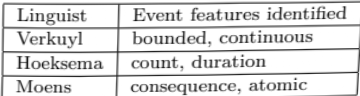

> table

## Page 7

7

at_midnight(e)

Thus we can see that Davidson's approach places the event variable e in the main predicate of a clause and distributes it among the modifiers of the clause in logical representation. In writing the meaning in Davidsonian logic, the author creates predicates such as the_toast and in_the_bathroom, just for illustration, without going into details.

Davidsonian representation allows events to be represented in logic (logical semantics) without requring verbs to have multiple arities, i.e., without taking different arguments in different situations. Because the event is represented as a variable,the event variable e can be included in the representation of logical meaning of each modifier or adjunct. Another benefit is that using Davidson's representation, one can analyze events represented syntactically as nouns (nominals) or verbs [Parsons 1990]. For example, one can refer to an event using the verb to burn or the noun a burn. Parsons also observes that using a variable to represent an event allows quantification over events the same way quantification applies to things. The following examples are from[Parsons 1990].

a. In every burning, oxygen is consumed.

∀e burning(e) →∃e'(consuming(e') ∧ object(e, oxygen) ∧ in(e, e')

b. Agatha burned the wood.

∃e burning(e) ∧ subject(e, Agatha) ∧ object(e, wood)

c. Orygen was consumed.

∃e' consuming(e') ∧ object(e', oxygen)

We do not go into details of containment of events as expressed by in in the first example above, and also the representation of passives as in the third example above.In these three examples, the author uses predicates such as object and subject which represent more fine-grained relationship with the main predicate (corresponding to the verb usually) than the examples earlier. Extending this work, [Parsons 1990;Higginbotham 1985; Vlach 1981] have demonstrated that using Davidson's e variable allows one to express tense dependency between perception verbs and their infinitival compliments in a natural way.

[Parsons 1990] extends Davidson's approach to logical representation by adding an extra term corresponding to the event type of the predicate. He distinguishes between two types of eventualities: eventualities that culminate called Cul containing achievements and accomplishments, and those that do not, called Hold containing states and activities.

2P2中54一

∃e buttering(e) ∧ agent(e, Jones) ∧ theme(e, toast) ∧ (∃t (t < now∧ Cul(e, t))

IV1LTUhTLUS1ICe.

∃e knowing(e) ∧ experiencer(e, Mary) ∧ theme(e, Fred) ∧ Hold(e, now))

In the logical representation in these examples, the author uses predicates such as theme, agent and experiencer which are usually are called cases in linguistics [Fillmore 1977]. In addition, the author uses a variable t to express time. now is a here.

ACM Transactions, Vol. V, No. N, March 2022

## Page 8

8

[Hobbs 1985] also proposes a logical form based on Davidson's approach. The main motivation behind Hobb's approach is to be able to produce satisfactory semantic representation when an event is expressed as a noun, or when we want to express the meaning of tenses, modalities, and adverbial modifiers. He also explains how so-called opaque adverbials like almost in the sentence, John is almost a man. can be represented by the Davidsonian approach, which Hobbs extends.He also shows how the ambiguity between de re and de dicto meanings of sentences [Quine 1956] that discuss beliefs can be explained by his approach to logical form representation of sentences. The representation by Hobbs is quite similar to other such representations based on Davidson, although there are some fine points of differences, that we do not discuss here. From a practical point of view, several research efforts in computational linguistics have adopted Hobb's logical form, and one such recent approach is by [Rudinger and Van Durme 2014] who attempt to map Stanford dependency parses [De Marneffe et al. 2006] into Hobbsian logical form, and discover that sometimes it is possible to do so, but in other cases the mapping requires semantic information that is not present in such dependencies indentified by the Stanford parser.

2.4Event structure

Early efforts at identification of event structure in linguistics was usually limited to explaining essential grammatical phenomena. However, others later proposed complex structures that go beyond simple structures such as Davidson's approach of representing an event by a single logical variable and its components by additional predicates. Understanding the structure of an event entails (i) understanding the argument structure of the word (or, phrase) used to express the event in surface form, (ii) understanding the components in the conceptual or semantic description of an event, and (iii) understanding the relation or mapping between syntactic realization of an event and its conceptual components. In fact, analysis of argument structure includes all three steps and requires finding the relation between meaning of a verb (or a clause) and the syntactic realization of arguments. [Grimshaw 1990;Williams 1981] introduce argument structure as a distinct level of representation in linguistics. Other prominent representations proposed include f-structures [Bresnan 1982], linear event structures [van Voorst 1988], lexical conceptual structures (LCS)[Jackendoff 1985; Rappaport and Levin 1988] and two related structures: event structures and qualia structures for arguments [Pustejovsky 1991a].

There are two sides to event structure: syntactic and semantic. When specifying event structure, at the semantic level, the description must be richer than semantic role descriptions [Gruber 1965; Fillmore 1968]. [Levin 1985] argues that named roles or thematic roles are too coarse-grained to provide useful semantic interpretation of a sentence. It is also necessary to capture semantic distinctions in a much more fine-grained manner compared to prior theories of [Katz and Fodor 1963; Wilks 1975; Quillian 1968]. ***A sentence or two on these theories*** By this time it was clear that sophisticated approaches to specifying event structure must build upon the rich taxonomy of verb classes [Levin 1985] and descriptive vocabulary work [Talmy 1985] and [Jackendoff 1985].

ACM Transactions, Vol. V, No. N, March 2022.

## Page 9

9

2.4.1 Lericalization Patterns by Talmy. [Talmy 1985] discusses the systematic relations in language between meaning and surface expression. In particular, Talmy focuses on verbs and in particular, verbs that describe motion or location. He sketches a “motion" event in order to explore issues in lexicalization. The basic motion event consists of one object called figure moving or located with respect to another object called the referent or the ground. The motion event has additional components such as path and motion, manner and cause. Talmy gives examples of cases where the verb at once can express, in addition to the action or motion, one or more of figure, path, manner or cause. If a sematic component such as manner or cause is expressed directly by the verb, it is called conflation of manner (or cause) into the verb. Some verbs incorporate aspect, which represents the "pattern of distribution of at ion though time." In some languages, verbs can incorporate personation as well. Personation is a specification of the person involved, e.g., self or non-self. Some verbs incorporate what is called valence, where in conceptualizing an event that involves several different entities in distinct roles, a verb is able to direct greater attention to some one of these entities that to the others, or perhaps adopt a specific perspective. Sometimes, semantic components are not incorporated into the verb, but are expressed through what Talmy calls satellites. A satellite is an immediate constituent of the verb root other than inflections, auxiliaries or nominal arguments.

Talmy enumerates 35 different semantic components. In addition to the six listed above, these include main purpose, result, polarity, aspect, personation, temporal and spatial setting, gender, valence, etc. Talmy also isolates surface elements within a verb complex such as the root verb, inflections, appositions, subordinate clauses and satellites. He then examines which semantic elements are expressed by which surface elements. He finds that the relationship is mostly not one-to-one. A combination of semantic elements may be expressed by a single surface element, or a single semantic element by a combination of surface elements. In a similar manner,semantic elements of different types can be expressed by the same type of surface elements or by several different ones.

Talmy's work does not enumerate lexical entries for specific verbs, but provides detailed discussion on semantic facets of meanings of a verb. The main thrust of Talmy's work is to demonstrate that semantic elements and surface elements relate to each other in specific patterns, both typological and universal. In work prior to Talmy's, most work has treated language's lexical elements as atomic givens,without involving semantic components that comprise them. These studies treated the properties that such whole forms can manifest, in particular, word order, grammatical relations and case roles. Talmy's cross-linguistic study determines semantic components' surface presence, site (their host constituent or grammatical relation)and combination within a site. In addition, Talmy's tracing of surface occurrence patterns extends beyond treating single semantic component at a time to treating a concurrent set of components.

Lexical semantics must strive to represent at least some of the various semantic components that Talmy enumerates. In addition, it must incorporate ways of mapping from syntax to semantics or vice versa. In a very simple system, a set of detailed rules may be able to enumerate the mappings from syntax to semantics

ACM Transactions, Vol. V, No. N, March 2022.

## Page 10

10

and vice versa. In a complex modern system, it is necessary that a machine learning technique will automatically acquire the mappings. This usually requires a lot of labeled examples for a machine learning program to learn such mappings. We discuss some such as efforts later in the paper.

2.4.2 Jackendoff's Lexical Conceptual Structure.

2.4.3 Generative Lexicon by Pustejousky. Consider the following illustrative examples.

a) Mary walked.

b) Mary walked to the store.

c) Mary walked for 30 minutes.

Sentence a) describes a process, which is an activity of of indefinite length, i.e., the sentence does not say how long the activity of walking took. Although b) does not give an explicit time duration for the walking event, it depicts an accomplishment and provides a logical culmination to the duration of the event of walking because the event is over when Mary reached the store. Sentence c) talks about a bounded process in which, the event of walking terminating although it does not provide an explicit termination point, but provides a bound to the time extent of the activity in terms of a duration adverbial. This example motivates the observation that the use of prepositional phrases or duration adverbials can change the (aspectual)classification of an event. To explain such phenomena better, it is beneficial to have more complex event structures or lexical analysis of event words. [van Voorst 1988]hypothesizes that the direct object plays a role in delimitation of an event, i.e.,whether it has a culmination or not. [Pustejovsky 1991b; 1991a] builds upon such observations and hypothesizes that it is necessary to know the how an event can be broken down into sub-events. He provides the following reasons for sub-eventual analysis.

Sub-eventual analysis of predicates allows verbal decomposition leading to more complex lexical semantics.

-Scope of adverbial modification, for some adverbials, can be explained better using event sub-structures.

Semantic arguments of items within a complex event structure can be mapped onto argument structures better.

Pustejovsky describes a generative lexicon in the sense that meanings are described in terms of a limited number of so-called generative devices or primitives by drawing upon Aristotle's species of opposition [Lloyd 1968]. For example, to express the meaning of the word closed as in The door is closed, The door closed or John closed the door, one needs the concept of opposition between closed and not-closed. This essential opposition in the meaning of a lexical item is described by Pustejovsky in terms of what is called the qualia structure of the lexical item. Thus, there are three primary components to the event structure proposed by Pustejovsky.

—Event type: The event type of the lexical item is given in terms of the classification schemes discussed earlier.

ACM Transactions, Vol. V, No. N, March 2022.

## Page 11

11

-Rules for event composition: Since an event may be expressed by more than a single verb, the meanings of several lexical items may have to be composed to obtain a description. For example, how does PP attachment change the meaning of the central event in context?

-Mapping rules from event structure to argument structure: Pustejovsky describes a number of rules or principles for such mapping. These rules describe how how semantic participants are realized syntactically.

Pustejovsky provides lexical meaning in terms of four separate structures.

-Argument structure: The behavior of a word as a function, with its arity. This provides the predicate argument structure for a word, which specifies how it maps to syntax.

Event structure: It identifies a specific event type for a word or a phrase, following [Vendler 1967].

Qualia structure: It provides the essential attributes of an object that need to be expressed lexically.

-Inheritance structure: It specifies how the word is globally related to other concepts in the lexicon.

In summary, Pustejovsky endows complexity to lexical entries for verbs as well as non-verbs so that semantic weight does not fall on verbs alone in the lexicon and when composing the meaning of a sentence from its constituents. Pustejovsky's approach also reduces the number of lexical entries necessary for individual verbs because the lexical entries become more general. Pustejovosky focuses on creating more muscular compositional semantics rather than decomposing a verb's meaning into a specified number of primitives.

2.5 Semantic Arguments and Syntactic Positions

Frequently, specific semantic arguments of a verb (also called thematic arguments)appear in characteristic syntactic positions. This has led to theories or proposals regarding mapping between the two. These theories state that specific semantic arguments belong in specific syntactic positions and that there is 1-1 relationship between semantic argument and (initial²) syntactic position. Such proposals or theories include the Universal Alignment Hypothesis [Perlmutter 1978] and Uniformity of Theta Assignment Hypothesis [Baker 1988]. These are supposed to be universal in that they applied across languages and across verbs. For example, agents appear in subject positions across languages and verbs. This mapping is thus universal.However, other mappings are not so universal. For example, the theme can appear in object, subject or indirect object position; and the experiencer can appear in subject or object position.

A theory that explains lexicon-to-syntax mapping also needs to explain the existence of argument alterations. In other words, it should explain the possibility that the same semantic role can appear in different syntactic positions for the same verb. Usually, linguists classify verbs into a number of semantic classes (different

2The syntactic or surface position of a constituent may change under certain circumstances, e.g.,when one formulates a question from a canonical or declarative sentence.

ACM Transactions, Vol. V, No. N, March 2022.

## Page 12

12

(verb:orth "abandon":subc((np-pp :pval("to"))(np)))
(noun :oath "abandon":features ((countable :pval ("with"))))
(verb:orth "abstain":subc((intrans) (pp:pval("from"))(p-in-sc :pval("from"))))(verb:oath "accept":subc((np)(that-s) (np-as-np)))
(verb :orth promote :subc ((np-pp :pval (to for into from)) (np-pp-pp :pval(for to into from))(possing)(np)(np-as-np)(np-tobe)))

Fig. 1. Sample Comlex verb entries

from the ones we talked about earlier) and for each class, a set of mapping relations and a set of argument alterations are specified [Levin 1993; Levin and Hovav 1995;Pinker 1989]. However, other researchers claim that such semantic classification is difficult to obtain because semantically similar verbs may behave differently across languages [Rosen 1984], a given verb in a language may have multiple syntactic realizations [Rosen 1984; 1996], and semantically similar verbs may allow several syntactic realizations [Rosen 1996].

3. LEXICAL RESOURCES FOR ACTION OR EVENT REPRESENTATION

The discussions on lexical representation of verbs so far have been based on efforts where a small number of examples were studied intently by linguists before making the various proposals. Starting the 1980s but more so in the 1990s, when computer scientists started to focus more on analysis of large text corpora, it became evident to some that the lexical analysis of pure linguists can be extended by knowledge gathered from such corpora. This led to development of the Comlex lexicon [Grishman et al. 1994], WordNet [Miller 1995; Fellbaum 2010], VerbNet [Schuler 2005],FrameNet [Fillmore and Baker 2001a; 2001b; Fillmore et al. 2003; Fillmore 2006]and other resources. Some of these may have started without an automatic analysis of corpora, but soon corpora were used to refine and enhance the initial lexical resources. Comlex was a substantial resource whose creators spent a lot of effort in enumerating subcategorization features. WordNet is a large lexical resource or ontology, which encompasses words from all categories. WordNet includes verbs,but is not verb-specific. VerbNet, of course, is focussed on verbs alone. FrameNet is also focussed on verbs. Both VerbNet and FrameNet attempt to represent all verbs, not only those which are used to represent "events". However, the term event itself is not clearly defined and most anything that is described by a verb can be considered an event in some context or another.

3.1 Comlex and Nomlex Lexicons

Comlex was created at New York University as a computational lexicon providing detailed syntactic information on approximately 38,000 words [Grishman et al.1994]. Of course, not all of these were verbs or words that describe actions. The feature set Comlex provided were more detailed than commerically available dictionaries at the time such as the Oxford Advanced Learner's Dictionary (OALD)[Hornby 1980] and Longman's Dictionary of Contemporary Englisch (LDOCE) [Pro 1981]. The initial word list was derived from OALD. The lexicon used a Lisp-like notation for dictionary entries. We see some sample entries for verbs in Comlex in Figure 1.

ACM Transactions, Vol. V, No. N, March 2022.

## Page 13

(vp-frame s :cs ((s 2 :that-comp optional))

:gs (:subject 1 :comp 2)

:ex "they thought (that) he was always late")
(vp-frame to-inf-sc :cs ((vp :2 :mood to-infinitive :subject 1))
:features (:control subject)

:gs (:subject 1 :comp 2)

:ex "1 wanted to come.")

(vp-frame to-inf-rs :cs ((vp 2 :mood to-infinitlve :subject 1))
:features (:raising subject)

:gs (:subject () :comp 2)

:ex "they seemed to wilt.")

Fig. 2. Sample Comlex Subcategorization Frames

Comlex paid particular attention to providing detailed subcategorization or complement information for verbs, and nouns and adjectives that take complements.Comlex was influenced by prior work on lexicon such as the Brandeis Verb Lexicon [Grimshaw and Jackendoff 1981], the ACUILEX project [Sanfilippo 1994], the NYU Lingustic String Project [Sager 1981], the OALD and the LDOCE, and it incorporated distinctions made in these dictionaries. Comlex had 92 different subcategorization features for verbs. The features recorded differences in grammatical functions as well as constituent structure. In particular, Comlex captured four different types of control: subject control, object control, variable control and arbitrary control. It was also able to express the fact that a verb may have different control features for different complement structures, or different prepositions within the complement. Figure 2 shows a few complements used in Comlex. Here : cs is the constituent structure, : gs is the grammatical structure and :ex are examples.The authors created a initial lexicon manually and then refined it using a variety of sources, both commercial and corpus-based.

The Nomlex dictionary of nominalizations was also developed at NYU [Macleod et al. 1998; Meyers et al. 1998]. It enumerated allowed complements for nominalizations, and also related nominal complements of the corresponding verbs. A nominalization is the noun form of a verb. For example, the verb promote is nominalized as nominalization. Similarly, the nominalizations of the verb appoint are appointment and appointee. Nomlex entries are similar in syntax to Comlex entries. Each Nomlex entry has a :nom-type feature which specifies four types of nominalizations: action (appointment, destruction) or state (knowledge), subject (teacher), object (appointee) and verb-part for those nominalizations that incorporate a verbal particle (takeover). Meyers et al. [Meyers et al. 1998] presented a procedure what mapped syntactic and semantic information for an active clause containing a verb e.g., (IBM appointed Alice Smith as vice president) into a set of patterns for nominalization (IBM's appointment of Alice Smith as vice president or Alice Smith's appointment as vice president). The lexical entry for the verb appoint used in Comlex is given in Figure 1. The lexical entry in Nomlex for the action nominalization appointment is given in Figure 3.

ACM Transactions, Vol. V, No. N, March 2022.

## Page 14

14

(nom :orth promotion:verb promote 

:nom-type((verb-nom))

:verb-subj((n-n-mod) (det-poss))

:verb-subc ((nom-np :object ((det-poss)(n-n-mod)(pp-of)))
(nom-np-as-np:object ((det-poss) (pp-of)))
(nom-possing :nom-subc ((p-possing:pval (of))))
(nom-np-pp:object ((det-poss)(n-n-mod) (pp-of))
:pval (into from for to))
(nom-np-pp-pp:object((det-poss)(n-n-mod) (pp-of))
:pval(for into to):pval2(from))))

Fig. 3. The lexical entry for the action nominalization appointment in Nomlex. The entry for the verb appoint is given in Figure 1

3.2 Levin's Verb Classes

Levin's verb classes [Levin 1993] explicitly provide the syntax for each class, but do not provide semantic components. The classes are based on the ability or inability of a verb to occur in pairs of syntactic frames, with the assumption that syntactic frames reflect the underlying semantics. For example, break verbs and cut verbs are similar because they can all take part in transitive and middle constructions.However, only break verbs can occur in simple intransitive constructs. Similarly,cut verbs can occur in conative constructs and break verbs cannot. The explanation given is that cut describes a sequence of actions that result in the goal of separating an object into pieces. It is possible that one can perform the actions without achieving the result (e.g., John cut at the loaf). For break, the result is a changed state where the object becomes separated into pieces. If the result is not achieved,we cannot say that the action of breaking took place. The examples below are taken from [Kipper et al. 2000].

-Transitive Construction: (a) John broke the window., (b) John cut the bread.

—-Middle Construction: (a) Glass breaks easily., (b) This loaf cuts easily.

—Intransitive Construction: (a) The window broke., (b) * The bread cut.

-Conative Construction: (a) *John broke at the window., (b) John valiantly cut at the frozen loaf, but his knife was too dull to make a dent in it.

Levin's original classes had some inconsistencies. For example, many verbs were listed in multiple classes, some of which had conflicting syntactic frames. [Dang et al. 1998] refined the original classification to remove some of these problems to build a more fine-grained, syntactically and semantically coherent refined class called intersective Levin classes. Levin's classes also are focussed mostly on verbs taking noun (NP) and prepositional phrase (PP) complements, and are weak on coverage of ADJP, ADVP, sentential complement, etc. VerbNet is built using these classes.

Organization of verbs into such classes capture generalizations about their properties. Such classes also help create better NLP systems. Many NLP systems benefit from using the mapping from surface realization of arguments to predicateargument structure that is available in such classes. These classes also capture abstractions (e.g., syntactic and semantic properties) and as a result, they are

ACM Transactions, Vol. V, No. N, March 2022.

ACM Transactions, Vol. V, No. N, March 2022.

## Page 15

15

helpful in many operational contexts where the available corpora are small in size and thus, it is not possible to extract detailed lexical information about verbs from such small corpora. The predictive power of the classes can compensate for the lack of sufficient data. Lexical classes have been helpful in tasks such as subcategorization acquisition [Dorr 1997; Prescher et al. 2000; Korhonen and Briscoe 2004],automatic verb acquisition [Swift 2005], semantic role labeling [Swier and Stevenson 2004], and word sense disambiguation [Dang 2004]. ***Add newer citations for application. Look at after 2004 proceedings of NAACL-HLT***

3.3 WordNet

The WordNet project [Miller 1995; Fellbaum 2010] started in the mid-1980s at Princeton University and over time, has become the most widely used lexical resource in English, especially when one needs a lexical resource that can be used by a program. Wordnet was primarily designed as a semantic network and later modified to be a lexical database.

WordNet groups words into synsets (synonym set) and contains relations among these synsets. A synset contains all the word forms that can refer to a given concept or sense. For each sense of each word, WordNet also provides a short,general definition called its gloss and example usages.

As the name hints, the WordNet can be thought of as a large graph where the words and synsets are nodes. These nodes linked by edges that represent lexical and semantic-conceptual links, which we discuss briefly below. Individual words may also be linked with antonym links. Superclass-subclass relations link entire synsets. WordNet has entries for verbs, nouns, adjectives and adverbs.

To get a better feel for what WordNet is like, let us look at the online version of WordNet³at Priceton University. When we search for the word assault in the online WordNet, the results come in two parts: noun and verb, because assault can be either a verb or a noun. The results that show up for verb are given in Figure 4. The verb senses of assault belongs to three synsets. In other words, it has three senses or can refer to three different concepts. Each sunset is composed of several verbs. The second of these synsets contains one sense of each of the verbs assail,set on and attack.

A verb may have four types of entries in WordNet: hypernyms, toponyms, entailment and coordinate terms. These terms are defined here. A verb Y is a hypernym of the verb X if the activity X is a (kind of) Y. For example, to perceive is an hypernym of to listen. A verb Y is a troponym of the verb X if the activity Y is doing X in some manner. For example, to lisp is a troponym of to talk. A verb Y is entailed by X if by doing X one must be doing Y. For example, to sleep is entailed by to snore. Coordinate terms are those verbs that share a common hypernym,e.g., to lisp and to yell. If we want to see the direct troponym of the second synset for the verb meaning of assault, we get what we see in Figure 5.1CVEA1OE004+71

WordNet has been used in many applications. However, it is most commonly used as a computational lexicon or “ontology" of English (or, another language)for word sense disambiguation, a task that assigns the most appropriate senses (i.e. synsets) to words in specific contexts. Although WordNet is large and de

3available at http://wordnetweb.princeton.edu

ACM Transactions, Vol. V, No. N, March 2022.

## Page 16

16

S:(v) assail, assault, set on, attack (attack someone physically or emotionally)
S:(v) rape, ravish, violate, assault, dishonor, dishonour, outrage (force (someone) to have sex against their will)
S:(v) attack, round, assail, lash out, snipe, assault (attack in speech or writing)

Fig. 4. Online WordNet search for the word attack. We show only the verb entries, with gloss for each entry.

S: (v) bait (attack with dogs or set dogs upon)

S:(v) sic, set (urge to attack someone)

S: (v) bulldog (attack viciously and ferociously)

S:(v) rush (attack suddenly)

S: (v) blindside (attack or hit on or from the side where the 
attacked person's view is obstructed)

S: (v) savage (attack brutally and fiercely)

S: (v) reassail (assail again)

S: (v) jump (make a sudden physical attack on)

S: (v) beset, set upon ((5) )

S:(v) rape,ravish, violate, assault,dishonor, dishonour, outrage 
(force (someone) to have sex against their wil1)
S:(v) desecrate, profane, outrage, violate (violate the sacred 
character of a place or language)

S:(v) molest (harass or assault sexually; make indecent advances to)

Fig. 5. The direct toponym set for the second sunset for the verb assault seen in Figure

tailed, WordNet does not have information required by NLP applications such as predicate-argument structure. Although WordNet contains a sufficiently wide range of common words, it does not cover special domain vocabulary. It is general in nature, and therefore difficult to use if specialized vocabulary is needed. Also,WordNet senses are sometimes overly fine-grained even for human beings and as a results, some researcher argue that it cannot achieve very high performance in the tasks where it is applied. Although WordNet is the most widely used online lexical database in NLP applications, is also limited in its coverage of verbs.

The English WordNet currently contains approximately 117,659 synsets, each sunset corresponding to a sense of a word. It has 11,529 verbs that belong to 13,767 synsets. It also contains 117,798 nouns that belong to 82,115 synsets. WordNets have been developed or are being developed in a large number of languages such as Catalan, French, Spanish, Japanese, Chinese, Danish, Korean and Russian.Notable collaborative efforts include Euro Wordnet [Vossen 2004; 1998a; 1998b],Asian Wordnet [Charoenporn et al. 2008; Robkop et al. 2010; Sornlertlamvanich et al. 2009] and Indo WordNet [Sinha et al. 2006] projects. The Indo WordNet focuses on 18 major languages of India. For example, as of June 20124 there are 15,000 synsets in the Assamese WordNet, 24,000 in Bengali, 16,000 in Bodo, 27,000in Gujarati, and 31,500 in Oriya. WordNets in most other languages are not as

4http://en.wikipedia.org/wiki/IndoWordNet ACM Transactions, Vol. V, No. N, March 2022.

## Page 17

17

sophisticated as the one in English.

3.4 FrameNet

FrameNet [Baker et al. 1998; Fillmore et al. 2003; Ruppenhofer et al. 2006] is another substantial publicly available lexical resource that has come into existence independently. It is based on the theory of frame semantics [Fillmore 1976; Petruck 1996; Fillmore and Baker 2001a; 2001b; Fillmore 2006] where a frame corresponds to a stereo-typical scenario involving an interaction and participants, where participants play some kind of roles. The idea is that the meanings of most words are best understood in context. FrameNet proposes a small context, called a semantic frame, a description of a type of event, relation or entity and the participants in it. A frame has a name and this name is used to identify a semantic relation that groups together the semantic roles.

Although frames mostly correspond to verbs, there are frames that can be identified by nouns and adjectives. FrameNet also has a large number of annotated sentences. Each annotated sentence exemplifies a possible syntactic realization of the semantic role associated with a frame for a given target word. FrameNet extracts syntactic features and corresponding semantic roles from all annotated sentences in the FrameNet corpus, it builds a large set of rules that encode possible syntactic realizations of semantic frames.

FrameNet aims to document the range of semantic and syntactic combinatory possibilities— valences–of each word in each of its senses, through computer-assisted annotation of example sentences and automatic tabulation of the annotation results. The FrameNet lexical database, currently contains more than 10,000 lexical units (defined below), more than 6,000 of which are fully annotated, in nearly 800hierarchically-related semantic frames, exemplified in more than 170,000 annotated sentences. See the FrameNet website⁵ for the latest statistics. FrameNet has been used as a semantic role labeling, used in applications such as information extraction, machine translation, event recognition, sentiment analysis, etc., like the other publicly available lexical resources.

An example of a frame is Attack. This frame has several frame elements. The core frame elements are assailant and victim. There are a large number of noncore frame elements. These include Circumstances, Containing_event, Direction,Duration, Explanation, Frequency, Manner, Means, Place, Purpose, Result, Time,Weapon, etc. For each of these frame elements there can be seen in one or more annotated sentences. Here is an example annotated sentence.

[Assailant The gang] ASSAULTED[victim him]
[Time during the drive to Rickmansworth][Place in Hertfordshire]... (1)

The frame Attack is associated with a large number of associated units. These include verbs and nouns. Example verbs are ambush, assail, assault, attack, bomb,bombard, charge, hit, infiltrate, invade, raid, storm and strike. Examples of nouns are airstrike, ambush, assailant, assault, attack, etc. The frame Attack inherits from

[Time during the drive to Rickmansworth][Place in Hertfordshire]... (1)

5https://framenet.icsi.berkeley.edu/fndrupal/home

ACM Transactions, Vol. V, No. N, March 2022.

## Page 18

18

a frame called Intentionally-affect. It is inherited by frames Besieging, Counterattack, Invading and Suicide_attack.

FrameNet annotates each frame element (or its representation, actually) in at least three layers: a frame element name (e.g., Food), a grammatical function (e.g.,Object) and a phrase type (e.g., NP). Only the frame elements are shown in the Web-based interface to reduce visual clutter, although all three are available in the XML downloads. FrameNet has defined more than 1000 semantic frames. These frames are linked together using frame relations which relate more general frames to specific ones. This allows for reasoning about events and intentional actions.

Because frames are semantic, they are often similar across languages. For example, frames about buying and selling involve frame elements Buyer, Seller, Goods and Money in every language. FrameNets have been developed for languages such as Portuguese, German, Spanish, Chinese, Swedish and Japanese.

At the current time, there are 1159 frames in FrameNet. There are approximately 9.6 frame elements per frame. There are 12595 lexical units of which 5135 are nouns,4816 are verbs, 2268 are adjectives. There are 12.1 lexical units per frame.

There have been some attempts at extending the coverage of FrameNet. One such effort is by [Rastogi and Van Durme 2014] who use a new broad-coverage lexicalsemantic resource called PPDB to add lemmas as pontential triggers for a frame and to automatically rewrite existing example sentences with these new triggers.PPDB, The Paraphrase Database, is a lexical, phrasal and syntactic paraphrase database [Ganitkevitch et al. 2013]. They use PPDB's lexical rules along with a 5-gram Kneser-Ney smoothed language model trained using KenLM [Heafield et al.2013] on the raw English sequence of the Annotated Gigaword corpus [Napoles et al. 2012].

3.5 PropBank

PropBank [Kingsbury and Palmer 2002; 2003; Palmer et al. 2005] is an annotated corpus of verb propositions and their arguments. PropBank does not annotate events or states of affairs described using nouns. PropBank-style annotations usually are closer to the syntactic level, whereas FrameNet-style annotations are more semantically motivated although, as discussed earlier, FrameNet provides layers of annotations including syntactic parses. PropBank annotates one million words of the Wall Street Journal portion of the Penn Treebank [?] with predicate-argument structure for verbs using semantic role labels for each verb argument.

Although the same tags are used across all verbs (viz., ArgO, Arg1, · . . , Arg5),these tags have verb-specific meaning. FrameNet requires that the use of a given argument label is consistent across different uses of a specific verb, including its syntactic alternations. Thus, Arg1 (italicized) in“John broke the window broke"is the same window that is annotated as the Arg1 in“The window broke" even though it is the syntactic subject in one case and the syntactic object in another.FrameNet does not guarantee that an argument label is used consistently across different verbs. For example, Arg2 is used as label to designate the destination of the verb “bring", but the extent of the verb “rise". Generally, the arguments are simply listed in the order of their prominence for each verb. However, PropBank tries to use Arg0 as the consistent label for the “prototypical agent"and Arg1 for the“prototypical patient"as discussed in[Dowty 1991].

ACM Transactions, Vol. V, No. N, March 2022.

## Page 19

19

Table III. PropBank entry for attack.01, a sense of the verb attack

Table IV. Roles for the verbs purchase, buy and sell in PropBank

PropBank divides words into lexemes using a very coarse-grained sense disambiguation scheme. Two senses are considered distinct only if their argument labels are different. In PropBank each word sense is called a frameset. PropBank's model of predicate-argument structure differs from dependency parsing. In dependency parsing, each phrase can be dependent only on one other phrase. But, in PropBank, a single phrase can be arguments to several predicates. PropBank provides a lexicon which divides each word into coarse-grained senses or framesets, and provides examples usages in a variety of contexts. For example, the to make an attack,criticize strongly sense of the predicate lemma (or, verb) attack is given in Table III along with an example.

PropBank tries to keep rolesets consistent across related verbs. Thus, for example, the buy roleset is similar to the purchase and sell rolesets. See Table IV, taken from [Kingsbury and Palmer 2002].

One can clearly see that it may be possible to merge such similar framesets together to obtain something similar to the verb roles in FrameNet's Commerce frameset.

Although similar, PropBank differs from FrameNet we have discussed earlier in several ways. PropBank is a resource focussed on verbs whereas FrameNet is focussed on frame semantics that generalizes descriptions across similar verbs as well as nouns and other words (e.g., adjectives) as discussed earlier. PropBank was created with the idea of serving as training data to be used with machine learning algorithms for the task of semantic role labeling. It requires all arguments to a verb to be syntactic constituents in nature. In addition, PropBank differentiates among senses of a verb if the senses take different sets of arguments. There is a claim that due to such differences, semantic role labeling is easier using a corpus annotated with PropBank type annotation compared to FrameNet type annotation.

ACM Transactions, Vol. V, No. N, March 2022.

**table** (confidence 0.98)

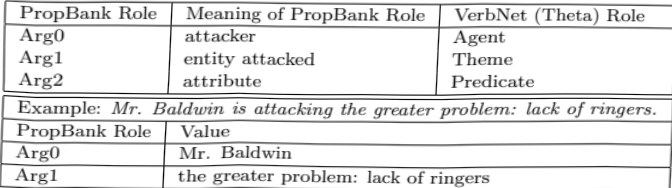

> table

**table** (confidence 0.98)

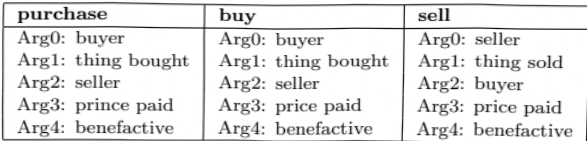

> table

## Page 20

20

3.6 VerbNet

VerbNet [Kipper et al. 2000; Kipper et al. 2000; Kipper-Schuler 2005] attempts to provide a definitive resource for lexical entries for English verbs. It is compatible with WordNet, but has lexical entries with explicit syntactic and semantic information about verbs, using Levin's verb classes [Levin 1993]. It uses verb classes to capture generalizations and for efficient encoding of the lexicon. Its syntactic frames for verb classes are represented using a fine-grained variation of Lexicalized Tree Adjoining Grammers [Joshi 1985; Schabes 1990; Dang et al. 1998] augmented with semantic predicates, allowing for creating compositional meanings for more complex constituents such as phrases and clauses. VerbNet provides traditional semantic information such as thematic roles and semantic predicates, with syntactic frames and selectional restrictions. it also allows for extension of verb meaning through adjunction of particular syntactic phrases.

A verb entry corresponds to a set of classes, corresponding to the different senses of the verb. For each verb sense, there is a verb class as well as specific selectional restrictions and semantic characteristics that may not be captured by class membership. VerbNet also contains references to WordNet synsets. Verb classes capture generalizations about verb behavior. Each verb class lists the thematic roles that the predicate-argument structure of its members allows, and provides descriptions of the syntactic frames corresponding to allowed constructs, with selectional restrictions given for each argument in each frame. Verb classes are hierarchically organized. It required some manual restructuring of Levin's classes. Each event E is decomposed into a three-part structure according to [Moens 1987; Moens and Steedman 1988]. VernNet uses a time function for each predicate specifying whether the predicate is true during the preparatory, culmination or consequent/result stage of an event. This structure allows VerbNet to express the semantics of classes of verbs like Change of State verbs. For example, in the case of the verb break, it is important to distinguish between the state of the object before the end of the action and the new state that results afterwards.

Table V is an example of a simplified VerbNet entry from its website⁶. The original VerbNet was extended using extensions proposed by [Korhonen and Briscoe 2004]. This resulted in the addition of a large number of new classes, and also a much more comprehensive coverage of English verbs. Table VI provides statistics of VerbNet's coverage in its initial version, VerbNet as described in [Kipper et al.2000; Kipper et al. 2000; Kipper et al. 2008], and its current version as in its official Website.

The absence of any lexicon or resource that provides for accurate and comprehensive predicate-argument structure (or semantic role labels) for English verbs has been long considered a critical element that was needed to produce robust natural language processors. This was shown clearly by [Han et al. 2000] who evaluated an English-Korean machine translation system. The authors showed that among several factors impacting on the low quality of translations, one that was most influential was the inability to predicate-argument structure. Even with a grammatical parse of the source sentence ad complete vocabulary coverage, the translation was

6http://verbs.colorado.edu/~mpalmer/projects/verbnet.html ACM Transactions, Vol. V, No. N, March 2022.

## Page 21

21

Table V. Simplified VerbNet entry for Hit-18.1 class. Every class is numbered.

Table VI. VerbNet statistics

frequently bad. This is because, the authors found, that although the parser recognized the constituents that are verb arguments, it was unable to precisely assign the arguments to appropriate positions. This led to garbled translations. Simply preserving the proper argument position labels and not changing other things,resulted in substantial improvement in acceptable translations. When using one parser, the improvement was 50%; with a second parser, the improvement was dramatic 300%. Thus, the purpose in developing lexical resources such as FrameNet and PropBank, PropBank especially so, is to provide for training data annotated with predicate-argument positions with labels. Such data can be used with machine learning techniques.

3.7 Combining FrameNet, VerbNet and WordNet

There have been attempts to integrate lexical resources to obtain more robust resources with wider coverage. We discuss one such effort here. [Shi and Mihalcea 2005] integrate FrameNet, VerbNet and WordNet discussed earlier into a single and richer resource with the goal of enabling robust semantic parsing. The reason for building connections among the three lexical resources is that similar syntactic patterns often introduce different semantic interpretations and similar meanings can be realized in many different ways. The improved resource provides three enhancements: (1) It extends the coverage of FrameNet, (2) It augments VerbNet's lexicon with frame semantics, and (3) It implements selectional restrictions using WordNet semantic classes. They use knowledge about words and concepts from WordNet, information about different situations from FrameNet, and verb lexicon with selectional restrictions from VerbNet. They extract syntactic features and

ACM Transactions, Vol. V, No. N, March 2022.

**table** (confidence 0.98)

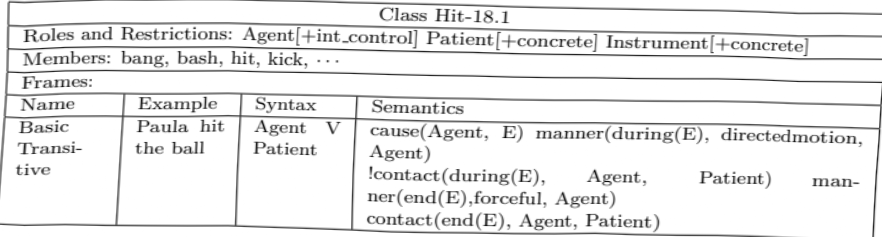

> table

**table** (confidence 0.97)

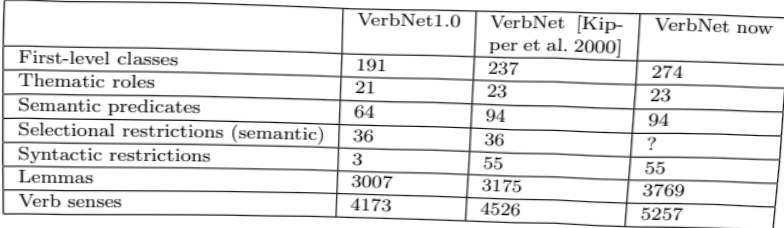

> table

## Page 22

22

corresponding semantic roles from all annotated sentences in FrameNet to build a large set of rules that encode the possible syntactic realization of semantic frames.They identify the VerbNet verb class that corresponds to a FrameNet frame and this allows them to parse sentences that include verbs not covered by FrameNet.This they do by exploiting a transitivity relation via VerbNet classes: verbs that belong to the same Levin classes are likely to share the same FrameNet frame, and their frame semantics can be analyzed even if not explicitly defined in FrameNet.They use information from WordNet in several stages in the parsing process. The argument constraints encoded in VerbNet (e.g., +animate, +concrete) are mapped to WordNet semantic classes, to provide selectional restrictions for better frame selection and role labeling in a semantic parser. In addition, the mapping between WordNet verb entries and FrameNet lexical units allows them to extend the parser coverage, by assigning common frames to verbs that are related in meaning according to the WordNet semantic hierarchies. The authors found that their mapping algorithms produced 81.25% correct assignment of VerbNet entries with a correct FrameNet frame. They also were able to map 78.22% VerbNet predicate-argument structures with some syntactic features and selectional restrictions to the corresponding FrameNet semantic roles.

3.8 OntoNotes and Other Large-scale Annotated Corpora

The OntoNotes project [Hovy et al. 2006; Sameer et al. 2007; Weischedel 2011]has created an infrastructure for much richer domain independent representation of shallow meaning for use in natural language processing tasks, including event detection and extraction, in English, Chinese and Arabic. OntoNotes annotates documents at several layers: syntax, propositions, word senses including nominalizations and eventive noun senses, named entities, ontology linking and co-reference.It has been designed to be a well-annotated large-scale corpus from which machine learning programs can learn many different aspects of meaning felicitously.

OntoNotes uses Penn TreeBank parses [Marcus et al. 1993], PropBank propositional structures [Kingsbury and Palmer 2002; 2003; Palmer et al. 2005]on top of Penn Treebank, and uses the Omega ontology [Philpot et al. 2005]for word sense disambiguation. As we know, the Penn Treebank is annotated with information from which one can extract predicate-argument structures. The developers of OntoNotes use a parser that recovers these annotations [Gabbard et al. 2006]. The Penn Treebank also has markers for "empty" categories that represent displaced constituents. Thus, to create OntoNotes, its developers use another parser [Collins 1999; 2003] to extract function words. They also use a maximum entropy learner and voted preceptons to recover empty categories. PropBank, as we know, annotates the one-million word Wall Street Journal part of the Penn Treebank with semantic argument structures for verbs. As we have noted earlier, the creators of OntoNote and others have discovered that WordNet's very fine grained sense distinctions make inter-annotator agreement or good tagging performance difficult. To achieve better performance, OntoNotes uses a method [Palmer et al. 2004; Palmer et al. 2007] for sense inventory creation and annotation that includes links between grouped word senses and the Omega ontology [Philpot et al. 2005]. OntoNotes represents sense distinctions in a hierarchical structure, like a decision tree, where coarse-grained distinctions are made at the root and increasingly fine-grained re

ACM Transactions, Vol. V, No. N, March 2022.

## Page 23

23

strictions until reaching WordNet senses at the leaves. Sets of senses under specific nodes of the tree are grouped together into single entries, along with syntactic and semantic criteria for their groupings; these are presented to annotators for improved annotation agreement, obtaining up to 90% inter-annotator agreement. OntoNote follows a similar method for annotation of nouns.

To allow access to additional information such as subsumption, property inheritance, predicate frames from other sources, links to instances and so on, OntoNotes also links to an ontology. This requires decomposing the hierarchical structure of OntoNotes into subtrees which then can be inserted at the appropriate conceptual node in the ontology. OntoNotes represents its terms in the Omega ontology [Philpot et al. 2005]. Omega7has been assembled by merging a variety of sources such as WordNet, Mikrokosmos [Mahesh et al. 1995], and a few upper ontologies such as DOLCE [Gangemi et al. 2002], SUMO [Niles and Pease 2001], and Penman Upper Model [Hovy 2003]. OntoNote also includes and cross-references verb frames from PropBank, FrameNet, WordNet and Lexical Conceptual Structures [Habash and Dorr 2002]. OntoNotes also has coreferences. It connects coreferring instances of specific referring expressions, primarily NPs that introduce or access a discourse entity.

For the purpose of our paper, it is important to know that OntoNotes tries to annotate nouns that carry predicate structure, e.g., those whose structure is derived from their verbal form. In particular, OntoNotes annotates nominalization and eventive senses of nouns. OntoNotes applies two strict criteria for identifying a sense of a noun as a nominalization [Weischedel 2011].

-The noun must relate transparently to a verb, and typically display a nominalizing morpheme such as -ment (govern/government), -ion (contribute/contribution),though it allows some zero-derived nouns such as kill, the noun derived from kill,the verb.

-The noun must be able to be used in a clausal noun phrase, with its core verbal arguments related by semantically empty or very“light" licensers, such as genitive markers (as in The Roman's destruction of the city.. or with the verb's usual particle or prepositional satellites as in John's longing for fame and fortune...

Just like nominalization senses, OntoNotes has strict definition of eventive senses.They have two definitional criteria (1) and (2), and a diagnostic test (3), for determining ifa noun sense is eventive.

(1) Activity causing a change of state: A noun sense is eventive when it refers to a single unbroken activity or process, occurring during a specific time period, that effects a change in the world of discourse.

—

procere not merely to the result of the activity or the process.

2一-t更子正里t。
describes the following heuristic lexico-syntactic diagnostic test to apply to many 
nouns. The test has four parts to it as discussed briefly below.

7http://omega.isi.edu

ACM Transactions, Vol. V, No. N, March 2022.

## Page 24

24

Create a natural sounding sentence using the construction X had <NP> where <NP>is a noun phrase headed by the noun in question, e.g., John had a party.-Check if the sentence can be used in present progressive as in John is having a party. If the sentence is felicitous, it adds to the noun being inventive. If it sounds odd, it adds to the evidence that the noun is stative.

-Check if the sentence can be used in a pseudo-cleft construction such as What John did was have a party. If it is felicitous, the noun is more likely to be eventive. If not, it is more likely to be stative.

-Check if the sentence suggests iterative or habitual action using the simple present such as John has α party every Friday. If so, it adds evidence that the noun is eventive. If the sentence suggests that the situation is taking place at that very moment that it is uttered, it adds evidence that the noun is stative as in John has a cold.

In addition to OntoNotes, there have been other efforts at obtaining large-scale annotated corpora such at the GLARF project [Meyers et al. 2001] that tries to capture information from various Treebanks and superimpose a predicate argument structure. The Unified Linguistic Annotation (ULA) project [Pustejovsky et al.2005] is a collaborative effort that aims to merge PropBank, NomBank, the Penn Discourse Treebank [Prasad et al. 2008] and TimeBank [Pustejovsky et al. 2003]with co-reference information.

4. EXTRACTING EVENTS FROM TEXTUAL DOCUMENTS

Different models of events have been used in computational linguistics work geared toward information extraction.

-A type of model that has been carefully developed over many years, treats an event as a word that points to a node in a network of predominantly temporal relations. An example is the so-called TimeML event that is found in documents that are annotated using the TimeML guidelines [Pustejovsky et al. 2003; Sauri et al. 2005; Saurí et al. 2005]. In a TimeML annotated corpus, every event is annotated. Thus, when working with the TimeML model, an extraction program attempts to extract every event.

-A second type of event model enumerates a few types of events to be extracted (where the types selected in a somewhat ad-hoc manner) with an event being described or pointed to by one or more words, along with additional associated words or phrases that specify arguments of the event. An example is the ACE model of events [, where an event is a complex structure with arguments which themselves may be complex structures. Event extraction in the context of MUC-7(are there other related MUCs?) or ACE, requires one to extract only a limited number of event types, e.g., movement event type, conflict event type, justice event type (see Section... below). The structure for these event types is provided by the contest organizers.

-Authors have used very specialized definitions of events when working with biomedical text, with details of a few specialized types of biomedical events,along with the participants.

ACM Transactions, Vol. V, No. N, March 2022.

## Page 25

25

-When detecting events in informal very short text such as microblogs of Facebook posts, researchers have used definitions that focus on extracting events from many short documents over which an event may be described.

We discuss TimeML events next followed by events. We discuss biomedical event extraction in Section 0??, and extraction of events from Twitter in Section 0??.

4.1 TimeML Events

TimeML is a rich specification language for event and temporal expressions in natural language text. In the TimeML [Pustejovsky et al. 2003; Sauri et al. 2005]annotation scheme, an event is a general term for situations that happen or occur.Events can be punctual or momentary, or last for a period of time. Events in TimeML format may also include predicates describing states or circumstances in which something holds true. Only those states that participate in an opposition structure, as discussed in Subsection 2.4.3, are annotated. In general, an event can be expressed in terms of verbs, nominalizations, adjectives, predicative clauses, or prepositional phrases. TimeML allows an event, annotated with the EVENT tag,to be one of seven types: occurrence, state, report, i-action, i-state, aspectual and perception. The first five are special cases. The last two, Occurrence and State are used for general cases that do not fall in the special ones.

-Reporting: A reporting event describes an action declaring something, narrating an event, informing about a situation, and so on. Some verbs which express this kind of event are say, report, tell, explain, and state. An example sentence with the verb say is Punongbayan said that the 4, 795-foot-high volcano was spewing gases up to 1,800degrees.

-I-Action: I stands for intensionat8. According to the TimeML annotation guidelines, an i-action is a dynamic event that takes an event-denoting argument,which must be explicitly present in the text. Examples of verbs that are used to express i-actions include attempt, try, promise and offer. An example sentence with the verb try is Companies such as Microsoft or a combined worldcom MCI are trying to monopolize Internet access.

-I-State: I-State stands for intensional state. Like an I-Action, an I-State event takes an argument that expresses an event. Unlike an I-Action, the I-State class is used for events which are states. An example sentence that uses the verb believe is We believe that his words cannot distract the world from the facts of Iraqi aggression. Other verbs used to express i-states include intend, want, and think.

—Aspectual: An aspectual predicate takes an event as an argument, and points to a part of the temporal structure of the event. Such a part may be the beginning,the middle or the end of an event. Verbs such as begin, finish and continue are such aspectual predicates. An example sentence with the verb begin is All non-essential personnel should begin evacuating the sprawling base.

8 According to the English Wikipedia: In logic and mathematics, an intensional definition gives the meaning of a term by specifying all the properties required to come to that definition, that is,the necessary and sufficient conditions for belonging to the set being defined.

ACM Transactions, Vol. V, No. N, March 2022.

## Page 26

26

-Perception: This class includes events involving the physical perception of another event. Such events are typically expressed by verbs such as see, watch,glimpse, hear, listen, and overhear. An example sentence with the verb see is Witnesses tell Birmingham police they saw a man running.

Occurrence: An occurrence is a general event that occurs or happens in the world. An example of an occurrence is given in the following sentence: The Defense Ministry said 16 planes have landed so far with protective equipment against biological and chemical warfare. The occurrence has been highlighted in bold.

State: A state describes circumstances in which something obtains or holds true.An example sentence that shows two states is It is the US economic and political embargo which has kept Cuba in a box.

TimeML allows one to mark up temporal expressions using the TIMEX3 tag.Temporal expressions are of three types:(a) Fully specified temporal expressions such as June 11, 2013, (b) Underspecified temporal expressions such as Monday, (c)Durations such as three days. TimeML uses the SIGNAL tag to annotate sections of text, usually function words, that indicate how temporal objects are related to each other. The material marked by SIGNAL may contain different types of linguistic elements: indicators of temporal relations such as prepositions such as on and during, other temporal connectives such as when, etc. The TIMEX3 and SIGNAL tags were introduced by [Setzer and Gaizauskas 2000; Setzer 2001].

A major innovation of TimeML is the LINK tags that encode relations between temporal elements of a document and also help establish ordering between the events in a document. There are three types of links: TLINK showing temporal relationships between events, or between an event and a time; SLINK or a subordination link to show context that introduces relations between two events, or an event and a signal; ALINK or an aspectual link to show relationship between an aspectual event and its argument event. TLINK allows for 13 temporal relations introduced by [Allen 1983; 1984]. SLINK is used to express contexts such as use of modal verbs, negatives, positive and negative evidential relations, factives which require the event argument to be true, and counterfactives which require the event argument to be false. ALINK expresses initiation, culmination, termination or continuation relationships between an event and its argument event. Finally, TimeML is able to express three types of causal relations: an event causing an event, an entity causing an event, and the special situation where the use of the discourse marker and as a signal to introduce a TLINK indicating that one event happened before another as in He kicked the ball and it rose into the air.

The creators of TimeML have spent significant efforts to develop a fairly large corpus annotated with TimeML tags. This corpus is called the TIMEBANK corpus [Pustejovsky et al. 2003] and has 300 annotated articles. This corpus has been used to learn to extract events and temporal relations among events.

4.2 ACE Events

In the ACE model, only “interesting" events are annotated in corpora and thus extracted by a trained program. ACE annotators specify the event types they want to be extracted. For example, in one information extraction contest, an ACE 2005

ACM Transactions, Vol. V, No. N, March 2022.

## Page 27

27

event9 was of 8 types, each with one has one or more sub-types. The types are given below. ***Maybe, give some examples***

—Life: Be-born, marry, divorce, injure and die

—Movement: Transport

—Transaction: Transfer-ownership, Transfer money

—Business: Start-organization, Merge-organization, Declare-bankruptcy

—Contact: Meet, Phone-write

一Conflict: Attack, demonstrate

1-Personnel: Start position, End position, Nominate, Elect, and

—Justice: Arrest-Jail, Release-Parole, Trial-Hearing, Charge-Indict, Sue, Convict,Sentence, Fine, Execute, Extradite, Acquit, Appeal, Pardon.

Each event also has four categorial attributes. The attributes and their values are given below.

—Modality: Asserted and Other where Other includes, but is not limited to: Believed events; Hypothetical events; Commanded and requested events; Threatened, Proposed and Discussed events; and Promised events.

—Polarity: Positive and Negative.

—-Genericity: Specific, Generic

—Tense: Past, Present, Future and Unspecified.

ACE events have arguments. Each event type has a set of possible argument roles,which may be filled by entities, time expressions or other values. Each event type has a set of possible argument roles. There are a total of 35 role types although no single event can have all 35 roles. A complete description of which roles go with which event type can be found in the annotation guidelines for ACE 2005 events10.In an ACE event, time is noted if when explicitly given.

Others have defined events or event profiles themselves to suit their purpose.For example, Cybulska and Vossen [Cybulska and Vossen 2010; 2011] describe an historical information extraction system where they extract event and participant information from Dutch historical archives. They extract information using what they call profiles. For example, they have developed 402 profiles for event extraction although they use only 22 of them in the reported system. For extraction of participants, they use 314 profiles. They also 43 temporal profiles and 23 location profiles to extract temporal and locational information. Profiles are created using semantic and syntactic information as well as information gleaned from Wordnet [Miller 1995].

4.2.1 Additional Annotation Schemes.

9http://projects.1dc.upenn.edu/ace/docs/English-Events-Guidelines_v5.4.3.pdf 10http://projects.1dc.upenn.edu/ace/docs/English-Events-Guidelines_v5.4.3.pdf

ACM Transactions, Vol. V, No. N, March 2022.

## Page 28

28

4.2.1.1 ERE Annotations. The ACE annotation scheme, discussed earlier, was developed by NIST in 1999, and the ERE (Entities, Relations and Events) scheme was defined as a simpler version of ACE [Aguilar et al. 2014]. One of ERE's goals is also to make annotating easier and annotations more consistent across annotators.ERE attempts to achieve these goals by removing the most problematic annotations in ACE and consolidating others. We will discuss the three types annotations now:Entities, Relations and Events.

For example, consider Entities. ACEand ERE both have Person, Organization,Geo-Political Entity and Location as types of entities. ACE has two additional types, Weapon and Vehicle, which ERE does not have. ERE doesn't distinguish between Facility and Location types and merge them into Location. ERE has a type called Title for titles, honorifics, roles and professions. ACE has subtypes for entity mentions, which ERE does not. In addition to subtypes, ACE classifies entity mentions into classes (e.g., Specific, Generic and Underspecified), ERE has only Specific. ACE and ERE also have differences in how extents and heads are marked, and levels of entity mentions.

The purpose of Relation annotation in both ACE and ERE is to extract a representation of the meaning of the text, not necessarily tied to the underlying syntactic or lexical representation. Both schemes include Physical, Part-Whole, Affiliation and Social relations although the details are a bit different. Both tag relations inside a single sentence and tags only explicit mentions. Nesting of tags is not allowed.Each relation can have up to two ordered Argument slots. Neither model tags negative relations. However, ERE annotates only asserted ("real") events whereas ACE allows others as well, e.g., Believed Events, Hypothetical Events, Desired Events and Requested Events. There is no explicit trigger word in ACE, which annotates the full clause that serves as the trigger for a relation whereas ERE attempts to minimize the annotated span by allowing for the tagging of an optional trigger word or phrase. ACE justifies tagging of each Relation by assigning Syntactic Clauses to them, such as Possessive, PreMod and Coordination. The three types of Relations inn ERE and ACE have sub-types: Physical, Part-Whole, and Social and Affliation, but ERE collapses ACE types and sub-types to make them more concise,possibly less specific. [Aguilar et al. 2014] discuss the similarities and differences between ACE and ERE in detail.

Events in both ACE and ERE are defined as ‘specific occurrences' involving 'specific participants'. Like entities and relations, ERE is less specific and simplified compared to ACE. Both annotation schemes annotate the same event types: Life,Movement, Transaction, Business, Confict, Contact, Personnel, and Justice.

4.2.1.2 RED Annotations. [Ikuta et al. 2014] use another annotation scheme called Richer Event Description (RED), synthesizing co-reference [Pradhan et al.2007; Lee et al. 2012] and THYME-TimeML temporal relations [Styler IV et al.2014]. [Ikuta et al. 2014] discusses challenges in annotating documents with the RED schema, in particular cause-effect relations. The usual way to annotate causeeffect relations is using the counter-factual definition of causation in philosophy [Lewis 1973; Halpern and Pearl 2005]:

“X causes Y"means if X had not occurred, Y would not have happened.

## Page 29

29

However, [Ikuta et al. 2014] found that this definition leads to many difficult and sometimes erroneous annotations, and that's why while performing RED annotations, they used another definition [Menzies 1999; 2008] which treats causation as “a local relation depending on intrinsic properties of the events and what goes on between then, and nothing else". In particular, the definition is

“X causes Y"means Y was inevitable given X.

In fact, in the annotations performed by [Ikuta et al. 2014],they use the new definition to make judgements, but use the old definition as a precondition to the newone.

4.2.2 TAC-KBP Annotations. The Knowledge Base Population Track (TACBKP) was started by NIST in 2009 to evaluate knowledge bases (KBs) created from the output of information extraction systems. The primary tasks are a) Entity linking—linking extracted entities to entities in knowledge bases, and b) Slot filling—adding information to entity profiles, information that is missing from the knowledge base [McNamee et al. 2010]. Wikipedia articles have been used as reference knowledge bases in evaluating TAC-KBP tasks. For example, given an entity,the goal is to identify individual nuggets of information using a fixed list of inventory relations and attributes. For example, given a celebrity name, the task is to identify attributes such as schools attended, occupations, important jobs held,names of immediate family members, etc., and then insert them into the knowledge base. Many people compare slot filling to answering a fixed set of questions, obtaining the answers and filling in the appropriate slots in the knowledge base. Slot filling in TAC-KBP differs from extraction in ACE and ERE notations in several ways such as TAC-KBP seeks out information for named entities only, chiefly PERs and ORGs, TAC-KBP seeks to obtain values for slots and not mentions, and events are handled as uncorrelated slots, and assessment is like in question-answering.

Our focus on this paper has been on extracting events, and we know that to extract events properly, we need to explicitly extract event mentions, and also extract associated attributes such as agents, locations, time of occurrence, duration,etc. Rather than explicitly modeling events, TAC-KBP does so implicitly as it captures various relations associated with for example the agent of the event. For example, given a sentence “Jobs is the founder and CEO of Apple", TAC-KBP may pick"Apple" as the focal entity and identify" Jobs" as the filler of its founder slot, and"Jobs"as the filler of its CEO slot. However, an ACE or ERE annotation program will ideally pick the event as Founding, with Jobs as an argument (say the first argument or arg1, or the Actor) of the event, and "Apple" as another argument, say arg2.

4.3 Extracting Events

Many even extraction systems have been built over the years. A big motivator for development of event extraction systems seem to be various contests that are held every few years, although there has been considerable amount of non-contest related research as well. Although we discuss extraction of events represented by various formats, the methods are not really different from each other. That is why we discuss TimeML events in more detail and present the others briefly in this

ACM Transactions, Vol. V, No. N, March 2022.

## Page 30

30

section.

4.3.1 Extracting TimeML Events. We describe a few of the approaches that tempt to do so have been published [Saurí et al. 2005; Bethard and Martin 2006;Chambers et al. 2007; Llorens et al. 2010; Grover et al. 2010], and we pick just a few representative papers.

4.3.1.1 The Evita System. : [Saurí et al. 2005] implemented an event and event feature extraction system called EVITA and showed that a linguistically motivated rule-based system, with some help using statistical disambiguation perfumed well on this task. Evita is claimed to be a unique tool within the TimeML framework in that it is very general, being not based on any pre-established list of event patterns and being domain-independent. Evita can also identify, based on linguistic cues,grammatical information associated with event referring expressions, such as tense,aspect, polarity and modality, as stated in the TimeML specification. Evita does not directly identify event participants, but can work with named entity taggers to link arguments to events.

Evita breaks down the event recognition problem to a number of sub-tasks. Evita preprocesses the input text using the Alembic Workbench POS tagger, lemmatizer to find lexical stems, and chunkier to obtain phrase chunks, verbal, nominal and adjectival, the three that are commonly used as event referring expressions [?]. For each subtask after pre-processing, it combines linguistic- and statistically-based knowledge. Linguistic knowledge is used in local and limited contexts such as verb phrases and to extract morphological information. Statistical knowledge is used to disambiguate nominal events. The sub-tasks in event recognition in Evita are:determination of event candidates and then the events, identification of grammatical features of events, additional clustering of event chunks for event detection and grammatical feature identification in some situations.

For event identification, Evita looks at the lexical items tagged by the preprocessing step. It uses different strategies for identifying events in the three categories: verbs, nouns and adjectives. For identifying events in a verbal chunk, Evita performs lexical look-up and limited contextual parsing in order to exclude weak stative predicates such as be and generics such as verbs with bare plural subjects.Identifying events expressed by nouns involves a phase of lexical look-up and disambiguation using WordNet, and by mapping events SemCor and TimeBank 1.2 to WordNet synsets. Evita consults 25 subtrees from WordNet where all the synsets denote events. One of these, the largest, is the tree underneath the sunset that contains the word event. If the result of this lexical look-up is not conclusive (i.e.,if a nominal occurs as both event and non-event in WordNet), a disambiguation step is applied, based on rules learned by a Bayesian classifier trained on SemCor.To identify events from adjectives, Evita uses a conservative approach, where it tags only those adjectives that were annotated as such in TimeBank 1.2, when such adjectives occur as the head of a predicative complement.

To identify grammatical features (e.g., tense, aspect, modality, polarity and nonfinite morphology) of events, Evita uses different procedures based on the part of speech of the event denoting expression. But, in general it involves using morphol

ACM Transactions, Vol. V, No. N, March 2022.

## Page 31

31

ogy, pattern matching, and applying a large number (e.g., 140 such rules for verbal chunks) simple linguistic rules. However, to identify the event class, it performs lexical look-up and word sense disambiguation. Clustering is used to identify chunks from the preprocessing stage, that contribute information about the same event,e.g., when some modal auxiliaries and use of copular verbs. Clustering is activated by specific triggers such as the presence of a chunk headed by an auxiliary verb or a copular verb.

Evaluation of Evita was performed by comparing its performance against TimeBanck 1.2. The reported performance was that Evita had 74.03%precision, 87.31%recall and an F-measure of 80.12% in event detection. Accuracy (precision?) for polarity, aspect and modality was over 97% in each case.

4.3.1.2 Bethard and Martin's approach (2006). : [Bethard and Martin 2006] use TimeBank-annotated events and identify which words and phrases are events. They consider event identification as a classification task that works on word-chunks.They use the BIO formulation that augments each class label with whether the word is the Beginning, Inside or Outside of a chunk [Ramshaw and Marcus 1995].

They use a number of features, categorized into various classes, for machine learning. These include affix features (e.g., three or four characters from the beginning and end of each word), morphological features (e.g., base form of the word, and base form of any verb associated with the word if the word is a noun or gerund,for example), word-class features (e.g., POS tags, which noun or verb cluster a word belongs to where the clusters are obtained using co-occurrence statistics in the manner of [Pradhan et al. 2004]), governing features (e.g., governing light verb,determiner type—cardinal or genitive, for example), and temporal features (e.g.,a BIO label indicating whether the word is contained inside a TIMEX2 temporal annotation, a governing temporal preposition like since, till, before, etc.). They also use negation features and Wordnet hypernyms as features. For classification,they use the TinySVM implementation of SVM by [Kudo and Matsumoto 2001].

They perform experiments with TimeBank documents using a 90% stratified sampling for training and 10% for testing. They obtained 82% precision and 71% recall,with an F-measure of 0.759. They did compare their algorithm with an version of Evita they programmed themselves; this system obtained 0.727 F-measure, and thus Bethard and Martin's approached performed about 4% better. When Bethard and Martin's system was extended to identifying semantic class of an event, it did not perform as well, obtaining precision of 67%, recall of 51%, and F-measure of 0.317. However, the system was much better at identifying the classes of verbs with F-measure of 0.707 compared to finding classes of nouns with an F-measure of 0.337 only.

4.3.1.3 Llorens' et al.'s approach:. TIPSem (Temporal Information Processing based on Semantic information) is a system that participated in the TemEval2 Competition [Verhagen et al. 2010] in 2010, which presented several tasks to participants, although we are primarily interested in the event extraction task.TIPSem achieved the best F1 score in all the tasks in TempEval-2 for Spanish, and for English it obtained the best F1 metric in the task of extracting events, which required the recognition and classification of events as defined by TimeML EVENT

ACM Transactions, Vol. V, No. N, March 2022.

## Page 32

32

tag.

TIPSem learns Conditional Random Field (CRF) models using features for different language analysis levels, although the approach focuses on semantic information, primarily semantic roles and semantic networks. Conditional Random Fields present a popular and efficient machine learning technique for supervised sequence labeling[Lafferty et al. 2001].

The features used for training the CRF models are similar to one used by others such as Bethard and Martin, although details vary. However, they add semantic role labels to the mix of features. In particular, they identify roles for each governing verb. Semantic role labeling [Gildea and Jurafsky 2002; Moreda et al. 2007;Punyakanok et al. 2004] identifies for each predicate in a sentence, semantic roles and determine their arguments (agent, patient, etc.) and their adjuncts (locative,temporal, etc.). The previous two features were combined in TIPSem to capture the relation between them. The authors think this combination introduces additional information by distinguishing roles that are dependent on different verbs. The importance of this falls especially on the numbered roles (A0, A1, etc.) meaning different things when depending on different verbs.

The test corpus consists of 17K words for English and 10K words for Spanish,provided by the organizers of TempEval-2. For English, they obtained precision of 0.81, recall of 0.86 and F-measure of 0.83 for recognition with event classification accuracy of 0.79; for Spanish the numbers were 0.90, 0.86, 0.88 for recognition and 0.66 for classification accuracy. We provide these numbers although we know that it is difficult to compare one system with another, for example Bethard and Martin's system with TIPSem since the corpora used are difference.

4.3.1.4 TempEval-3: 2012. As inTempEval-2, TempEval-3 [UzZaman et al.2012] participants took part in a task where they had to determine the extent of the events in a text as defined by the TimeML EVENT tag. In addition, systems may determine the value of the features CLASS, TENSE, ASPECT, POLARITY,MODALITY and also identify if the event is a main event or not. The main attribute to annotate is CLASS.

The TempEval-3 dataset was mostly automatically generated, using a temporal merging system. The half-million token text corpus from English Gigaword2 was automatically annotated using TIPSem, TIPSem-B [Llorens et al. 2010] and TRIOS [UzZaman and Allen 2010]. These systems were re-trained on the TimeBank and AQUAINT corpus, using the TimeML temporal relation set. The outputs of these three state-of-the-art system were merged using a merging algorithm [UzZaman et al. 2012]. The dataset used comprised about 500K tokens of “silver" standard data and about 100K tokens of "gold" standard data for training, compared to the corpus of roughly 50K tokens corpus used in TempEval 1 and 2.

There were seven participants and all the participants except one used machine learning approaches. The top performing system was ATT-1 [Jung and Stent 2013]with precision 81.44, recall 80;67 and F1 of 81.05 for event recognition, and 71.88 for event classification. Close behind was the ATT-2 system[Jung and Stent 2013] with precision, recall and F-1 of 81.02, 80.81 and 80.92 for event recognition respectively,and 71.10 for event classification. Both systems used MaxEnt classifiers with

Obviously, different sets of features impact on the performance of event recogACM Transactions, Vol. V, No. N, March 2022.

## Page 33

33

nition and classification [Adafre and de Rijke 2005; Angeli et al. 2012; Rigo and Lavelli 2011]. In particular,[?] also examined performance based on different sizes of n-grams in a small scale (n=1,3). Inspired by such work, in building the ATT systems, the creators intended to systematically investigate the performance of various models and for each task, they trained twelve models exploring these two dimensions, three of which we submitted for TempEval-3, and of these three performed among the top ten in TempEval-3 Competition.

The ATT-1 models include lexical, syntactic and semantic features, ATT-2 models include only lexical and syntactic features, and ATT-3 models include only lexical features, i.e., words. They experimented with context windows of 0, 1, 3,and 7 words preceding and following the token to be labeled. For each window size, they trained ATT-1, ATT-2 and ATT-3 models. The ATT-1 models had 18basic features per token in the context window for up to 15 tokens, so up to 270basic feaures for each token to be labeled. The ATT-2 models had 16 basic features per token in the context window, so up to 240 basic features for each token to be labeled. The ATT-3 models had just 1 basic feature per token in the context window, so up to 15 basic features for each token to be labeled.

For event extraction and classification, and event feature classification, they used the efficient binary MaxEnt classifier for multi-class classification, available in the machine learning toolkit LLAMA [Haffner 2006]. They also used LLAMA's preprocessor to build unigram, bigram and trigram extended features from basic features.

For event and time expression extraction, they trained BIO classifiers. It was found that the absence of semantic features causes only small changes in F1. The absence of syntactic features causes F1 to drop slightly (less than 2.5% for all but the smallest window size), with recall decreasing while precision improves somewhat.F1 is also impacted minimally by the absence of semantic features, and about 2-5%by the absence of syntactic features for all but the smallest window size.1

。i一。量4especially in terms of precision (precision, recall and F2 of 81.95, 75.57 and 78.63for event recognition, and 69.55 F1 for event classification) . It is also surprising that the words only models with window sizes of 3 and 7 performed as well as the models with a window size of 15. These results are promising for“big data text analytics, where there may not be time to do heavy preprocessing of input text or to train large models.

4.3.2 Extracting Events Using Other Representations. We have already discussed several approaches to extraction of events represented by TimeML representation. Extracting events that use other representation is not very different, but different representations have existed and exist, and therefore we briefly present some such attempts. Some of these predate the time TimeML became popular. For example, the various Message Understanding Conferences (MUCs, seven were organize by DARPA from 1987 to 1997), asked participants to extract a small number of relations and events. For instance, MUC-7, the last one, called for the extraction of 3 relations (person-employer, maker-product, and organization-location) and 1event spacecraft launches.rentspacecrafttauTtCteS..,....₃.

For example, the MUC-7 and ACE events did not attempt to cover all events,

ACM Transactions, Vol. V, No. N, March 2022.

## Page 34

34

but a limited number of pre-specified event types or classes that participants need to detect during a contest period, based on which the contestants submit papers for publication. The number and the type of arguments covered are also limited and are pre-specified before the competitions start.

4.3.2.1 The REES System:. [Aone and Ramos-Santacruz 2000] discuss a relation and event extraction system covering areas such as political, financial, business, military, and life-related topics. The system consists of tagging modules, a co-reference resolution module, and a temple generation module. They store the events generated in MUC-7[Chinchor and Marsh 1998] format, which is not very unlike the ACEformat.

Events are extracted along with their event participants, e.g., who did what to whom when and where? For example, for a BUYING event, REES extracts the buyer, the artifact, the seller, and the time and location of the BUYING event.REES covers 61 types of events. There are 39 types of relations.

The tagging component consists of three modules: NameTagger, NPTagger and EventTagger. Each module relies on the same pattern-based extraction engine,but uses different sets of patterns. The NameTagger recognizes names of people, organizations, places, and artifacts (only vehicles in the implemented system).The NPTagger then takes the output of the NameTagger and first recognizes nonrecursive Base Noun Phrase (BNP) [Ramshaw and Marcus 1995], and then complex NPs for only the four main semantic types of NPs, i.e., Person, Organization, Location, and Artifact (vehicle, drug and weapon). The EventTagger recognizes events applying its lexicon-driven, syntactically-based generic patterns.

REES uses a declarative, lexicon-driven approach. This approach requires a lexicon entry for each event-denoting word, which is generally a verb. The lexicon entry specifies the syntactic and semantic restrictions on the verb's arguments.After the tagging phase, REES sends the output through a rule-based co-reference resolution module that resolves: definite noun phrases of Organization, Person,and Location types, and singular personal pronouns. REES outputs the extracted information in the form of either MUC-style templates or XML.

One of the challenges of event extraction is to be able to recognize and merge those event descriptions which refer to the same event. The Template Generation module uses a set of declarative, customizable rules to merge co- referring events into a single event.

The system's recall, precision, and F-Measure scores for the training set (200texts) and the blind set (208 texts) from about a dozen news sources. On the so-called training set, the system achieved F-measure of 64.75 for event extraction and 75.35 for relation extraction. The blind set F-Measure for 31 types of relations (73.95

4.3.2.2 Ahn's approach. As seen earlier in Subsection 4.2, the way ACE events are specified, they have a lot of details that need to be extracted. [Ahn 2006]follows several steps to extract events and uses machine learning algorithms at every step. The steps are pre-processing of text data, identifying anchors, assigning event types, extracting arguments identifying attributes of events such as modality,polarity, genericity and tense, and finally identifyings event co-referents of the same

ACM Transactions, Vol. V, No. N, March 2022.

## Page 35

35

individuated event. In other words, Ahn attempts to cover all the steps sequentially,making the simplifying assumption that they are unrelated to each other.

A single place in a textual document which may be considered the primary place of reference or discussion about an event is called the event anchor. Ahn treats finding the anchor for an event within a document as a word classification task,using a two-stage classification process. He uses a binary classifier to classify a word as being an event anchor or not. He then classifies those identified as event anchors into one of the event classes. Ahn used one classifier for binary classification and then another classifiers to classify only the positive instances.

Ahn treats identifying event arguments as a pair classification task. Each event mention is paired with each of the entity, time and value mentions occurring in the same sentence to form a single classification instance. There were 35 role types in the ACE 2006 task, but no event type allows arguments of all types. Each event type had its own set of allowable roles. The classification experiment run was a multi-class classification where a separate multi-class classifier was used for each event type. Ahn trains a separate classifier for each attribute. Genericity, modality,and polarity are each binary classification tasks, while tense is a multi-class task.For event coreference, Ahn follows the approach given in [Florian et al. 2004]. Each event mention in a document is paired with every other event mention, and a classifier assigns to each pair of mentions the probability that the paired mentions corefer. These probabilities are used in a left-to-right entity linking algorithm in which each mention is compared with all already-established events (i.e., event mention clusters) to determine whether it should be added to an existing event or start a new one.

Ahn experimented with various combinations of a maximum entropy classifier MegaM [Daumé III 2004] and a memory-based nearest neighbor classifier called TIMBL [Daelemans et al. 2004], for the various tasks.

The ACE specification provided a way to measure the performance of an event extraction system. The evaluation called ACE value is obtained by scoring each of the component tasks individually and then obtaining a normalized summary value.Overall, using the best learned classifiers for the various subtasks, they achieve an ACE value score of 22.3%,where the maximum score is 100%. The value is low,but other systems at the time had comparable performance.

4.3.2.3 Naughton 2008:. [Naughton et al. 2008] describe an approach to classify sentences in a document as specifying one or more events from a certain ACE 2006class. They classify each sentence in a document as containing an instance of a certain type or not. Unlike [Ahn 2006], they are not interested in identifying arguments or any additional processing. Also, unlike Ahn who classifies each word as possibly being an event anchor for a specific type of ACE event, Naughton et al. perform a classification of each sentence in a document as being an onevent sentence or an off-event sentence. An on-event sentence is a sentence that contains one or more instances of the target event type. An off-event sentence is a sentence that does not contain any instances of the target event type. They use several approaches to classify a sentence as on-event or off-event. These include the following: SVM-based machine learning [Joachims 1998], language modeling approaches using count smoothing, and a manual approach which looks for Wordnet

ACM Transactions, Vol. V, No. N, March 2022.

## Page 36

36

业号11111D专11业yPQ111了重继o秒秒都中22-R

Naughton et al. found that 1) use of a large number of features to start but then reduction of these features using information gain, and 2) use of SVM produces the best results although all versions of SVM (i.e., with all features with no reduction,just the terms without complex features, or a selection of terms and other features)all work very well. A "surprising"finding was that the “manual" trigger-based classification approach worked almost as well as the SVM based approaches.

4.4 Determining Event Coreference

When an event is mentioned in several places within a document, finding which references are to the same event is called determining event coreference. These are co-referents to the event. Determining when two event mentions in text talk about the same event or co-refer is a difficult problem. As [Hovy et al. 2013] point out that the events may be actual occurrences or hypothetical events.

4.4.1 Florian's Approach to Coreference Resolution. [Florian et al. 2004] present a statistical language-independent framework for identifying and tracking named,nominal and pronominal references to entities within unrestricted text documents,and chaining them into groups corresponding to each logical entity present in the text. The model can use arbitrary feature types, integrating a variety of lexical,syntactic and semantic features. The mention detection model also uses feature streams derived from different named entity classifiers.

For mention detection, the approach used is based on a log-linear Maximum Entropy classifier [Berger et al. 1996] and a linear Robust Risk Minimization classifier [Zhang et al. 2002]. Then they use a MaxEnt model for predicting whether a mention should or should not be linked to an existing entity, and to build entity chains.Both classifiers can integrate arbitrary types of information and are converted into suitable for sequence classification for both tasks.

For entity tracking, the process works from left to right. It starts with an initial entity consisting of the first mention of a document, and the next mention is processed by either linking it with one of the existing entities, or starting a new entity.Atomic features used by the entity linking algorithm include string match, context,mention count, distance between the two mentions in words and sentences, editing distance, properties of pronouns such gender, number and reflexiveness. The best combination of features was able to obtain slightly more than 73% F-1 value using both RRM and MaxEnt algorithms for mention detection.

Entity tracking was evaluated in terms of what is called the ACE value. A gauge of the performance of an EDT system is the ACE value, a measure developed especially for this purpose. It estimates the normalized weighted cost of detection of specific-only entities in terms of misses, false alarms and substitution errors.Florian et al. achieved an ACE value of 73.4 out of 100 for the MaxEnt classifier and 69.7 for the RRM classifier.

[Ahn 2006] follows the approach by [Florian et al. 2004] for entity coreference determination. He uses a binary classifier to determine if any two event mentions in the document refer to the same event. Thus, he pairs each event with every other event, and the classifier assigns each pair a probability that they are the same. The probability is used with entity linking/matching algorithm to determine event co

ACM Transactions, Vol. V, No. N, March 2022.

## Page 37

37

reference. Event co-referencing requires event mentions to be clustered to event clusters. Event mentions in a cluster are the same event. The system described here obtained an ACE value of between 88-91%, where the maximum ACE value is 100%.

[Ahn 2006] uses the following features for event co-reference determination. Let the candidate be the earlier event mention and the anaphor be the later mention.

-The anchors for the candidate and the anaphor, the full or original form, and also in lowercase, and POS tag.

Type of the candidate event and the anaphor event.

-Depth of candidate anchor word in parse tree.

-Distance between the candidate and anchor, measured in sentences.

-Number, heads, and roles of shared arguments, etc.

4.4.2 Bejan and Harabagiu. Supervised approaches to solving event coreference use linguistic properties to decide if a pair of event mentions is coreferential [Humphreys et al. 1997; Bagga and Baldwin 1999; Ahn 2006; Chen and Ji 2009]. These models depend on labeled training data, and annotating a large corpus with event coreference information requires substantial manual effort. In addition, since these models make local pairwise decisions, they are unable to capture a global event distribution at topic or document collection level. [Bejan and Harabagiu 2010] present how nonparametric Bayesian models can be applied to an open-domain event coreference task in an unsupervised manner.

The first model extends the hierarchical Dirichlet process [Teh et al. 2006] to take into account additional properties associated with event mentions. The second model overcomes some of the limitations of the first model, and uses the infinite factorial hidden Markov model [Gael et al. 2009] coupled to the infinite hidden Markov model [Beal et al. 2001] in order to consider a potentially infinite number of features associated with observable objects which are event mentions here, perform an automatic selection of the most salient features, and capture the structural dependencies of observable objects or event mentions at the discourse level. Furthermore, both models can work with a potentially infinite number of categorical outcomes or events in this case.

Two event mentions corefer if they have the same event properties and share the same event participants. To find coreferring event mentions, Bejan and Harabagiu describe words that may be possible event mentions with lexical features, class features such as POS and event classes such [Pustejovsky et al. 2003] as occurrence,state and action, Wordnet features, semantic features obtained by a semantic parse [Bejan and Hathaway 2007] and the predicate argument structures encoded in PropBank annotations [Palmer et al. 2005] as well as semantic annotations encoded in the FrameNet corpus [Baker et al. 1998].1e11a1G1VCUCO1Pu3D010I00ar-**

The first model represents each event mention by a finite number of feature types and is also inspired by the Bayesian model proposed by [Haghighi and Klein 2007].In this model, a Dirichlet process (DP) [Ferguson 1973] is associated with each document, and each mixture component (i.e., event) is shared across documents since In the process of generating an event mention, an event index z is first sampled by using a mech- anism that facilitates sampling from a prior for in- finite mixture

ACM Transactions, Vol. V, No. N, March 2022.

## Page 38

38

models called the Chinese restaurant franchise (CRF) representation, as reported in[Teh et al.2006].

The second model they use is called the iHMM-iFHMM model (infinite hidden Markov model-infinite factorial hidden Markov model). The iFHMM framework uses the Markov Indian buffet process (mIBP) [Gael et al. 2009] in order to represent each object as a sparse subset of a potentially unbounded set of latent features [Ghahramani and Griffiths 2005; Van Gael et al. 2008], Specifically, the mIBP defines a distribution over an unbounded set of binary Markov chains, where each chain can be associated with a binary latent feature that evolves over time according to Markov dynamics. The iFHMM allows a flexible representation of the latent structure by letting the number of parallel Markov chains be learned from data, it cannot be used where the number of clustering components is infinite. An iHMM represents a nonparametric extension of the hidden Markov model (HMM) [Rabiner 1989] that allows performing inference on an infinite number of states. To further increase the representational power for modeling discrete time series data, they develop a nonparametric extension that combines the best of the two models, and lets the two parameters M and K be learned from data Each step in the new iHMM-iFHMM generative process is performed in two phases: (i) the latent feature variables from the iFHMM framework are sampled using the mIBP mechanism; and (ii) the features sampled so far, which become observable during this second phase,are used in an adapted version of the beam sampling algorithm [?] to infer the clustering components (i.e., latent events).

They report results in terms of recall (R), precision (P), and F-score (F) by employing the mention-based B3 metric [Bagga and Baldwin 1998], the entity-based CEAF metric Luo 2005], and the pairwise F1 (PW) metric. Their experiments for show that both of these models work well when the feature and cluster numbers are treated as free parameters, and the selection of feature values is performed automatically.

4.4.3 Hovy et al. [Hovy et al. 2013] argue that events represent complex phenomena and can therefore co-refer fully, being identical, like other researchers have discussed, or co-refer partially, being quasi-identical or only partially identical. Two event mentions fully co-refer if their activity, event or state representation is identical in terms of all features used (e.g., agent, location or time). Two event mentions are quasi-identical if they partially co-refer, i.e., most features are the same, but there may be additional details to one or the other.

When two events fully co-refer, Hovy et al. state they may be lexically identical (i.e., the same senses of the same word, e.g., destroy and destruction), synonymous words, one mention is a wider reading of the other (e.g., The attack took place yesterday and The bombing killed four people), one mention is a paraphrase of the other with possibly some syntactic differences (e.g., He went to Boston and He came to Boston), and one mention deictically refers to the other (e.g., the party and that event). Quasi-identity or partial co-reference may arise in two ways: membership identity or subevent identity. Membership identity occurs when one mention, say A, is a set of multiple instances of the same type of event, and the other mention,say B, is one of the individual events in A (e.g., I attended three parties last week.The frst one was the best.). Subevent identity is found when one mention, say A,

ACM Transactions, Vol. V, No. N, March 2022.

## Page 39

39

is a stereotypical sequence (or script) of events whereas the other mention, say B, is one of the actions or events within the script (e.g., The family ate at the restaurant.The dad paid the waitress at the end.).

Hovy et al.attempt to build a corpus containing event co-reference links with high quality annotations, i.e., annotations with high inter-annotator agreement, to be useful for machine learning. They have created two corpora to assist with a project on automated deep reading of texts. One corpus is in the domain of violent events (e..g., bombings, killens and wars), and the other one containing texts about the lives of famous people. In both of these corpora, they have annotated a limited number of articles with full and partial co-references.

4.4.4 Delmonte. [Delmonte 2013] claims that performing event co-reference with high accuracy requires deep understanding of the text and statistically-based methods, both supervised and unsupervised, do not perform well. He claims that this is the case because because it is absolutely necessary to identify arguments of an event reliably before event co-references can be found. Arguments are difficult to identify because many are implicit and linguistically unexpressed. Successful even co-reference identification needs determination of spatio-temporal anchoring and locations in time and space are also very often implicit.

The system he builds uses a linguistically based semantic module, which has a number of different submodules which take care of Spatio-Temporal Reasoning,Discourse Level Anaphora Resolution, and determining Topic Hierarchy. The coreference algorithm works as follows: for each possible referent it check all possible coreference links, at first using only the semantic features, which are: wordform and lemma identity; then semantic similarity measured on the basis of a number of similarity criteria which are lexically based. The system searches WordNet synsets and assign a score according to whether the possible referents are directly contained in the same synset or not. A different score is assigned if their relation can be inferred from the hierarchy. Other computational lexical resources they use include FrameNet and Frames hierarchy; SumoMilo and its semantic classification.

After collecting all possible coreferential relations, the system filters out those links that are inconsistent or incompatible. Argument structure and spatiotemporal relations are computed along with dependence relations; temporal logical relations as computed using an adaptation of Allen's algorithm. The system also computes semantic similarity, where high values are preferred. The paper does not give any results to support the initial hypothesis, although the ideas are interesting.

4.4.5 Cybulska and Vossen. [Cybulska and Vossen 2015] use granularity in computing event coreference. The intuition is, that an event with a longer duration,that happens on a bigger area and with multiple particpants (for instance a war between Russia and Ukraine) might be related to but will probably not fully corefer with a lower level event of shorter duration and with single participants involved (e.g, A Russian soldier has shot dead a Ukrainian naval officer)..2103L1卷U0L0D011e4号41*

Coreference between mentions of two events is determined by computing compatibility of contents of event attributes. The attributes used are event trigger, time,location, human and non-human participant slots [Cybulska and Vossen 2014a].Granularity size is mentioned in terms of durations of event actions [Gusev et al.

ACM Transactions, Vol. V, No. N, March 2022.

## Page 40

40

2011] and granularity levels of event participants, time and locations. Granularity is given in terms of partonomic relations or through the part-of relation, between entities and events, using the taxonomy of meronymic relations by [Winston et al.1987]. Granularity levels of the human participant slot are contained within Winstons et al. Member-Collection relations. The temporal granularity levels make part of Winstons Portion-Mass relationships and locational levels are in line with Place-Area relations in Winstons taxonomy.

Cybulska and Vossen experimented with a decision-tree supervised pairwise binary classifier to determine coreference of pairs of event mentions. They also ran experiments with a linear SVM and a multinomial Naive Bayes classifier but the decision-tree classifier outperformed both of them.

For the experiments, Cybulska and Vossen use the ECB+ dataset [Cybulska and Vossen 2014b]. The ECB+ corpus contains a new corpus component, consisting of 502 texts, describing different instances of event types. They provide results in terms of several metrics: recall, precision and F-score, MUC [Vilain et al. 1995],B3 [Bagga and Baldwin 1998], mention-based CEAF [Luo 2005], BLANC Recasens and Hovy 2011], and CoNLL F1 [Pradhan et al.2011], and find that the introduction of the granularity concept into similarity computation improves results for every metric.

5. BIOMEDICAL EVENT EXTRACTION

Researchers are interested in extracting information from the huge amount of biomedical literature published on a regular basis. Of course, one aspect of information extraction is event extraction, the focus of this paper. In the biomedical context, an event extraction system tries to extract details of bimolecular interactions among biomedical entities such as proteins and genes, and the processes they take part in, as described in terms of textual documents. Manually annotated corpora are used to train machine learning techniques and evaluate event extraction techniques.

There have been several workshops on biomedical natural language processing.We focus on the BioNLP Shared Tasks in recent years that had competitions on event extraction. There have been three BioNLP Shared Task competitions so far:2009, 2011, and 2013. The BioNLP 2009 Shared Task [Kim et al. 2009] was based on the GENIA corpus [Kim et al. 2003] which contains PubMed¹¹ abstracts of articles on transcription factors in human blood cells. There was a second BioNLP Shared Task competition organized in 2011 to measure the advances in approaches and associated results [Kim et al. 2011]. The third BioNLP ST was held in 2013.We discuss some notable systems from BioNLP ST 2011 and 2013.

Before the BioNLP Shared Tasks, event extraction in the biomedical domain usually classified each pair of named entities (usually protein names) co-occurring in the text as interacting or not. BioNLP Shared Tasks extended such an approach by adding relations such as direction, type and nesting. An event defines the type of interaction, such as phosphorylation, and is usually marked in the text with a trigger word (e.g., phosphorylates) describing the interaction. This word forms the core of the event description. A directed event has roles that have inherent

11http://www.ncbi.nlm.nih.gov/pubmed ACM Transactions, Vol. V, No. N, March 2022.

## Page 41

41

directionality such as cause or theme, the agent or target of the biological process.In addition, events can act as arguments of other events, creating complex nested structures. For example, in the sentence Stat3 phosphorylation is regulated by Vav,a phosphorylation-event is the argument of the regulation-event.

The BioNLP Shared Tasks provide task definitions, benchmark data and evaluations, and participants compete by developing systems to perform the specified tasks. The theme of BioNLP-ST 2011 was a generalization of the 2009 contest,generalized in three ways:text types, event types, and subject domains. The 2011event-related tasks were arranged in four tracks: GENIA task (GE) [Kim et al.2011], Epigenetics and Post-translational Modifications (EPI) [Ohta et al. 2011]Infectious Diseases (ID)[Pyysalo et al. 2011], and the Bacteria Track [Bossy et al.2011; Jourde et al. 2011].

Of the four event-related shared tasks in BioNLP 2011, the first three were related to event extraction. The Genia task was focused on the domain of transcription factors in human blood cell. Trascription is a complex but just the first step in the process in which the instructions contained in the DNA in the nucleus of a cell are used to produce proteins that control most life processes. Transcription factors are proteins that control the transcription process. The EPI task was focused on events related to epigenetics, dealing with protein and DNA modifications, with 14 new event types, including major protein modification types and their reverse reactions.Epigenesis refers to the development of a plant or animal from a seed, spore or egg,through a sequence of steps in which cells differentiate and organs form. The EPI task was designed toward pathway extraction and curation of domain databases [Wu et al. 2003; Ongenaert et al. 2008]. A biological pathway refers to a sequence of actions among molecules in a cell that leads to a certain product or a change in the cell. The ID task was focused on extraction of events relevant to biomolecular mechanisms of infectious diseases from full length publications. Tasks other than ID focused on abstracts only.

In this paper, we discuss the systems and approaches for only the 2011 GE Task.This is because several of the winning systems for the GE Task did well in the other two relevant tasks as well. The Genia Task is described in Table VII. The table shows for each event type, the primary and secondary arguments to be extracted.For example, a phosphorylation event is primarily extracted with the protein to be phosphorylated, which is the addition of a phosphate group to a protein or other organic molecule. As secondary information, the specific site to be phosphorylated may be extracted. From a computational viewpoint, the event types represent different levels of complexity. When only primary arguments are considered, the first five event types in Table VII are classified as simple events, requiring only unary arguments. The binding and regulation types are more complex. Binding requires the detection of an arbitrary number of arguments, and Regulation requires detection of recursive event structure.

Consider the sentence In this study we hypothesized that the phosphorylation of TRAF2 inhibits binding to the CD40 cytoplasmic domain. Here there are two protein (entity) names: TRAF2 and CD40. The word phosphorylation refers to an event; this string is a trigger word. Thus, the goal of the GE task was to identify a structure like the ones in Tables VIII and IX . In the tables, Ti represents a

ACM Transactions, Vol. V, No. N, March 2022.

## Page 42

42

Table VII. Event types and their arguments in the Genia event task. The type of arguments,primary and secondary, to be extracted from the text, are also given.

Table VIII. Structure of an Event in BioNLP 2011 Contest, corresponding to Task 1 (GE)

Table IX. Structure of an Event in BioNLP 2011 Contest, corresponding to Task 2 (EPI)

trigger word, and Eirepresents an event associated with the corresponding trigger word. There are three events, E1 is the phosphorylation event, E2 is the binding event and E3 is the negative regulation event. For each trigger word, we see the starting and ending character positions in the entire string. For each event, we see the participants in it. The second task identifies an additional site argument.

1B=2。。。。[Kim et al. 2011] note an improvement of 10%over the basic GE task, in 2011(Task GEa), compared to 2009. The results of the GE tasks show that automatic extraction of simple events-those with unary arguments, e.g., gene expression, lo

ACM Transactions, Vol. V, No. N, March 2022.

**table** (confidence 0.99)

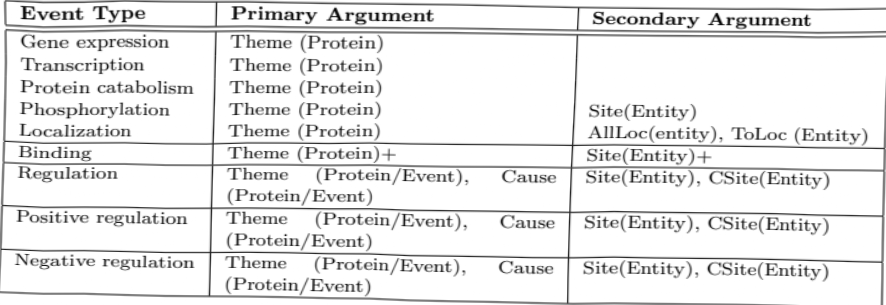

> table

**table** (confidence 0.87)

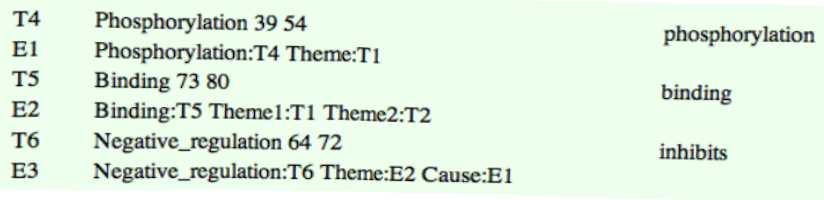

> table

**table** (confidence 0.93)

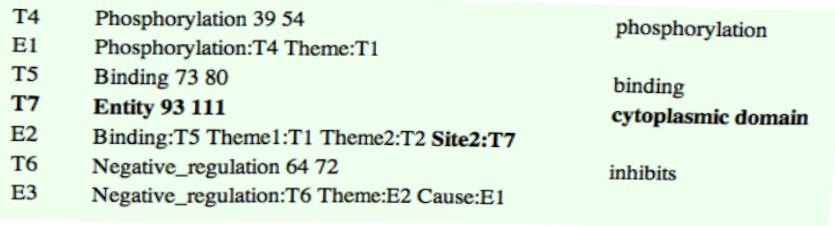

> table

## Page 43

43

Table X. Best results for various sub-tasks in BioNLP_ST 2011. Recall/precision/F-score %

calization and phosphorylation—can be achieved at about 70% in F-score, but the extraction of complex events, e.g., binding and regulation is very challenging, with only 40% performance level. The GE and ID results show that generalization to full papers is possible, with just a small loss in performance. The results of phosphorylation events in GE and EP are similar (GEp vs. EPIp), which leads [Kim et al.2011] to conclude that removal of the GE domain specificity does not reduce event extraction performance by much. EPIc results indicate that there are challenges to extracting similar event types that need to be overcome; EPIf results indicate that there are difficult challenges in extracting additional arguments. The complexity of the ID task is similar to that of the GE task; this shows up in the final results,also indicating that it is possible to generalize to new subject domains and new argument (entity) types.

Below, we provide a brief description of some of the approaches to biomedical event extraction from the BioNLP 2011 contests.

5.1 Technical Methods Used in BioNLP Shared Tasks 2011

The team that won the GE Task was the FAUST system [Riedel et al. 2011], followed by the UMass system [Riedel and McCallum 2011], then the UTurku system [Björne and Salakoski 2011]. The performance of these three systems on the various tasks is given in Table XI. In addition, we have the Stanford system in the table because it performed fairly well on the tasks.

The UMass system [Riedel and McCallum 2011] looks at a sentence as having an event structure, and then projects it onto a labeled graph. See Figure 6 for a target event structure and the projected graph for the sentence fragment Phosphorylation of TRAF2 inhibits binding to CD40. The system searches for a structure that connects the event and its participating entities and imposes certain constraints on the structure. Thus, the UMass system treats the search for such a structure as an optimization problem. To formulate this optimization problem, the system represents the structure in terms of a set of binary variables, inspired by the work of [Riedel et al. 2009; Björne et al. 2009]. These binary variables are based on the projection of the events to the labeled graph. An example of a binary variable is ai,1.r to indicate that between positions i and l in the sentence, there is an edge

ACM Transactions, Vol. V, No. N, March 2022.

**table** (confidence 0.97)

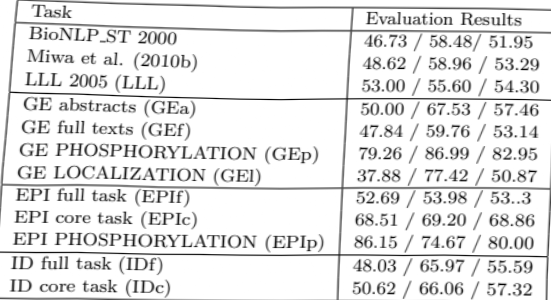

> table

## Page 44

44

Table XI. Evaluation results (recall / precision / f-score for Task 1 in Whole data set (W),Abstracts only (A) and Full papers only (F)

(a)Regulation Casse Thama Phosphorylation Binding Thama Theme 
Trerne 235A 789L aua phosphorylation of TRAF2 inhibits binding to the CD40+Phospnorylation Fiegulaton Thame Binãg d5,g,nems Thermet -Tharma Thame Causa SameBinding b4.9

Figure 1: (a) sentence with target event structure; (b) projection to labelled graph.

Fig. 6. (a) Sentence with target event structure, (b) Projection to labeled graph. ***Redraw the image***

labeled r from a set of possible edge labels R. Another such binary variable is ti,p,9that indicates that at position é, there is a binding event with arguments p and q.Given a number of such variables, it is possible to write an objective function to optimize in order to obtain events and entity bindings. The system decomposes the biomedical event extraction task into three sub-tasks:(a) event triggers and outgoing edges on arguments, (b) event triggers and incoming edges on arguments,and (c) and protein-protein bindings. The system obtains an objective function for each of the sub-tasks. It solves the three optimization problems one by one in a loop, till no changes take place, or up to a certain number of iterations. The approach uses optimizing by dual decomposition [Komodakis et al. 2007; Rush et al.2010] since the dual of the original optimization problem is solved.

The Stanford system [McClosky et al. 2011] exploits the observation that event ACM Transactions, Vol. V, No. N, March 2022.

**table** (confidence 0.99)

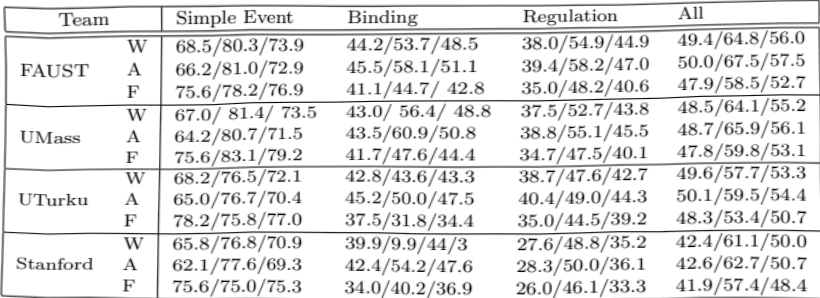

> table

## Page 45

45

structures bear a close relation to dependency graphs [Jurafsky and Martin 2000,Chapter 12]. They cast bimolecular events in terms of these structures which are pseudo-syntactic in nature. They claim that standard parsing tools such as maximum-spanning tree parsers and parse rerankers can be applied to perform event extraction with minimum domain specific training. They use an off-the-shelf dependency parser, MSTParser [McDonald et al. 2005; McDonald and Pereira 2006],but extend it with event-specific features. Their approach requires conversion to and from dependency trees, at the beginning and and at the end. The features in the MSTParser are quite local (i.e., able to examine a portion of each event at a time); the decoding necessary can be performed globally, allowing the dependency parser some trade-offs. Event parsing is performed using three modules: 1) anchor detection to identify and label event anchors, 2) event parsing to form candidate event structures by linking entries and event anchors, and 3) event reranking to select the best candidate event structure. First, they parse the sentences with a reranking parser [Charniak and Johnson 2005] with the biomedical parsing model from [McClosky 2010],using the set of Stanford dependencies De Marneffe and Manning 2008]. After the parsing, they perform anchor detection using a technique inspired by techniques for named entity recogntion to label each token with an event type or none, using a logistic regression classifier. The classifier uses features inspired by [Björne et al. 2009]. They change a parameter to obtain high recall to overgenerate event anchors. Multiword event anchors are reduced to their syntactic head. The event anchors and the included entities become a “reduced" sentence,input to the event parser. Thus, the event parser gets words that are believed to directly take part in the events. This stage uses the MSTParser with additional event parsing features. The dependency trees are decoded and converted back to event structures. Finally, for event reranking, the system gets n best list of event structures from each decoder in the previous step of event parsing. The reranker uses global features of an event structure to restore and output the highest scoring structure. The reranking approach is based on parse reranking [Ratnaparkhi 1999], but is based on features of event structures instead of syntactic constituency structure. They use the cvlm estimator [Charniak and Johnson 2005] when learning weights for the reranking model. Since the reranker can work with outputs of multiple decoders, they use it as an ensemble technique as in [Johnson and Ural 2010].

The FAUST system [Riedel et al. 2011] shows that using a straightforward model combination strategy with two competitive systems, the UMass system [Riedel and McCallum 2011] and the Stanford system [McClosky et al. 2011] just described,can produce a new system with substantially high accuracy. The new system uses the framework of stacking [Alpaydin 2010, Chapter 17]. The new system does it by including the predictions of the Stanford system into the UMass system, simply as a feature. Using this simple model of stacking, the FAUST system was able to obtain first place in three tasks out of four where it participated.

The Turku Event Extraction System [Björne and Salakoski 2011; Björne et al.2012] can be easily adapted to different event schemes, following the theme of event generalization in BioNLP 2011. The system took part in eight tasks in BioNLP 2011 and demonstrated the best performance in four of them. The Turku system

ACM Transactions, Vol. V, No. N, March 2022.

## Page 46

46

divides event extraction into three main steps: i) Perform named entity recognition in the sentence, ii) Predict argument relations between entities, and iii) Finally,separate entity/argument sets into individual events. The Turku system uses a graph notation with trigger and protein/gene entities as nodes and relations (e.g.,theme) as edges. In particular, an event in the graph representation is a trigger node along with its outgoing edges. The steps are shown in Figure 7. The Turku system uses Support Vector Machines [Vapnik 1995; Tsochantaridis et al. 2006]at various stages to perform each of the sub-tasks. To use an SVM classifier, one needs to convert text into features understood by the classifier. The Turku system performs a number of analyses on the sentences, to obtain features, which are mostly binary. The features are categorized into token features (e.g., Porter-stem [Porter 1980], Penn Treebank part-of-speech tags [Marcus et al. 1993], character biand tri-grams, presence of punctuation on numeric characters), sentence features (e.g., the number of named entities in the sentence), dependency chains (up to a depth of three, to define the context of the words),dependency with n-grams (joining a token with two flanking dependencies as well as each dependency with two flanking tokens),trigger features (e.g.,the trigger word a gene or a protein)and external features (e.g., Wordnet hypernyms, the presence of a word in a list of key terms). Applicable combinations of these features are then used by the three steps in event detection: trigger detection, edge detection and unmerging. Trigger words are detected by classifying each token as negative or as one of the positive trigger classes using SVMs. Sometimes several triggers overlap, in which case a merged class (e.g. phosphorylation-regulation) is used. After trigger prediction,triggers of merged classes are split into their component classes. Edge detection is used to predict event arguments or triggerless events and relations, all of which are defined as edges in the graph representation. The edge detector defines one example per direction for each pair of entities in the sentence, and uses the SVM classifier to classify the examples as negatives or as belonging to one of the positive classes. When edges are predicted between these nodes, the result is a merged graph where overlapping events are merged into a single node and its set of outgoing edges. To produce the final events, these merged nodes need to be pulled apart into valid trigger and argument combinations. Unmerging is also performed using the SVM classifier. Speculation and negation are detected independently, with binary classification of trigger nodes using SVMs. The features used are mostly the same as for trigger detection, with the addition of a list of speculation-related words.

6. EXTRACTING EVENTS FROM SOCIALLY GENERATED DOCUMENTS

With the explosive expansion of the Internet during the past twenty years, the volume of socially generated text has skyrocketed. Socially generated text includes blogs and microblogs. For example, Twitter12, started in 2006, has become a social phenomenon. It allows individuals with accounts to post short messages that are up to 140 characters long. Currently, more than 340 million tweets are sent out every day13. While a majority of posts are conversational or not particularly meaningful,

12http://www.twitter.com 

13http://blog.twitter.com/2012/03/twitter-turns-six.htm 
ACM Transactions, Vol. V, No. N, March 2022.

## Page 47

47

A Protein Protein Protein STAT3Ser(727)phosphorylation may involve Vav and Rac-1B parsing <nn <nsubj dobj>
appos><aux -dobj>conj_and>
STAT3NN Ser(727)NN phosphorylation NN may VB involve VB vav NN and CC Rac-1NN C trigger detection Protein Entity Phosphorylation Regulation Protein Protein STAT3Ser(727)phosphorylation may involve Vav and Rac-1D edge detection <Theme 
Cause>
<site.<Theme Cause>,Protein Entity Phosphorylation Regulation Protein Protein STAT3Ser(727)phosphorylation may involve Vav and Rac-1E unmerging 
<Theme Regulation Cause>
<Theme 
<site.<Theme Cause>
Protein Entity Phosphorylation Regulation Protein Protein STAT3Ser(727)phosphorylation may involve Vav and Rac-1F speculation and negation detection 
Spec 
<Theme Regulation Cause>
<Theme 
<site.<Theme Cause>
Protein Entity Phosphorylation Regulation Protein Protein STAT3Ser(727)phosphorylation may involve Vav and Rac-1

format, site arguments are paired with core arguments that have the same target protein.

Fig. 7. Turku BioNLP Pipeline

ACM Transactions, Vol. V, No.N, March 2022.

## Page 48

48

about 3.6% of the posts concern topics of mainstream news14. Twitter has been credited with providing the most current news about many important events before traditional media, such as the attacks in Mumbai in November 2008. Twitter also played a prominent role in the unfolding of the troubles in Iran in 2009 subsequent to a disputed election, and the so-called Twitter Revolutions1⁵ in Tunisia and Egypt in2010-11.

Most early work on event extraction of information from documents found on the Internet has focussed on news articles [Chambers and Jurafsky 2011; Doddington et al. 2004; Gabrilovich et al. 2004]. However, as noted earlier, social networking sites such as Twitter and Facebook have become important complimentary sources of such information. Individual tweets, like SMS messages, are usually short and self-contained and therefore are not composed of complex discourse structures as is the case with texts containing narratives. However, extracting structured representation of events from short or informal texts is also challenging because most tweets are about mundane things, without any news value and of interest only to the immediate social network. Individual tweets are also very terse, without much context or content. In addition, since Twitter users can talk about any topic, it is not clear a priori what event types may be appropriate for extraction.

The architecture of the system called TwiCal for event extraction [Ritter et al.2012] from Twitter messages is given in Figure 8. Given a stream of raw tweets,TwiCal extract events with associated named entities and times of occurrence. First the tweets are POS tagged using a tagger [Ritter et al. 2012], especially trained with Twitter data. Then named entities are recognized [Ritter et al. 2011] using a recognizer trained with Twitter data as well. After this, phrases that mention events (or, event triggers or event phrases or just events) are extracted using supervised learning. [Ritter et al. 2012] annotated 1,000 tweets with event phrases, following guidelines for annotation of EVENT tags in Timebank [Pustejovsky et al. 2003].The system recognizes event triggers as a sequence labeling task using Conditional Random Fields [Lafferty et al. 2001]. It uses a contextual dictionary, orthographic features, features based on the Twitter-tuned POS tagger, and dictionaries of event terms gathered from WordNet [Saurí et al. 2005]. Once a large number of events have been extracted by this CRF learner, TwiCal categorizes these events into types using an unsupervised approach based on latent variable models, inspired by work on modeling selectional preferences [Ritter et al. 2010; Séaghdha 2010; Kozareva and Hovy 2010; Roberts and Harabagiu 2011] and unsupervised information extraction [Bejan et al. 2009; Chambers and Jurafsky 2011; Yao et al. 2011]. This automatic discovery of event types is similar to topic modeling, where one automatically identifies the extant topics in a corpus of text documents. The automatically discovered types (topics) are quickly inspected by a human effort to filter out incoherent ones, and the rest are annotated with informative labels. Examples of event types discovered along with top event phrases and top entities are given in Table XII. The resulting set of types are applied to categorize millions of extracted events without the use of any manually annotated examples. For inference, the system uses collapsed Gibbs sampling [Griffiths and Steyvers 2004] and prediction

14http://www.pearanalytics.com/blog/tag/twitter/15http://en.wikipedia.org/wiki/Twitter_Revolution ACM Transactions, Vol. V, No.N, March 2022.

## Page 49

49

Temporal 
Resolution 
S 
Tweets POS Tag NER Ranking Signifieance Dal 
Event Tngger

Fig. 8. TwiCal Architecture

Table XII. Some of Examples of event types extracted by TwiCal

Table XIII. Examples of events extracted by TwiCal

is performed using a streaming approach to inference [Yao et al. 2009]. To resolve temporal expressions, TwiCal uses TempEx [Mani and Wilson 2000], which takes as input a reference date, some text and POS tags, and marks temporal expressions with unambiguous calendar references. Finally, the system measures the strength of association between each named entity and date based on the number of tweets they co-occur in, in order to determine if the event is significant. Examples of events extracted by TwiCal are given in Table XIII. Each event is a 4-tuple including a named entity, event phrase, calendar date and event type.

The TwiCal system describe above used topic modeling using latent variables as one of the several computational components; it is used to capture events captured using supervised learning into types or topics. [Weng and Lee 2011] point out some drawbacks of using such an approach. The main problem is that frequently the result generated by Latent Dirichlet Analysis (LDA) is difficult to interpret because it simply gives a list of words associate with the topic. For example, when [Weng and Lee 2011] attempt to find the four most important topics using LDA based on a Twitter collection emanating from Singapore on June 16, 2010, they find the topics listed in Table XIV. Therefore, Weng et al. present another approach to detect events from a corpus of Twitter messages. Their focus is on detection and therefore,

ACM Transactions, Vol. V, No. N, March 2022.

**table** (confidence 0.98)

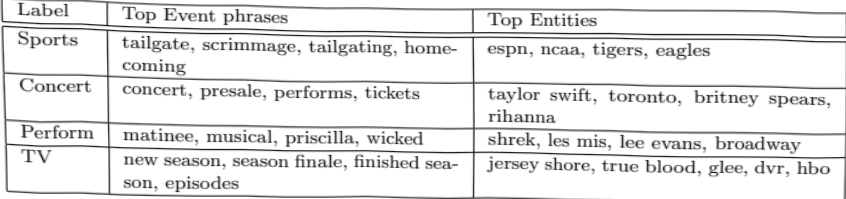

> table

**table** (confidence 0.97)

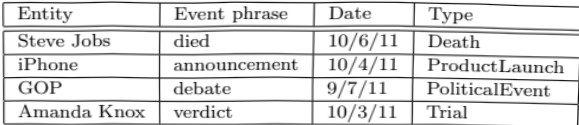

> table

## Page 50

50

not on extraction of components that describe an event. Event detection is based on the assumption that when an event is taking place, some related words show an increase in usage. In this scheme, an event is represented by a number of keywords showing a burst in appearance count [Yang et al. 1998; Kleinberg 2003]. Although it is clear that tweets report events, but such reports are usually overwhelmed by high food of meaningless “babbles". In addition, the algorithms for event detection must be scalable to handle the torrent of Twitter posts. The EDCoW (Event Detection with Clustering of Wavelet-based Signals) system builds signals for individual words by applying wavelet analysis ] on frequency-based raw signals of words occurring in the Twitter posts. These signals capture only the bursts in the words' appearance. The signals are computed efficiently by wavelet analysis [Kaiser 2011; Daubechies et al. 1992]. Wavelets are qickly vanishing oscillating functions and unlike sine and cosine functions used in Discrete Fourier Transformation (DFT) ]which are localized in frequency but extend infinitely in time, wavelets are localized both in time and frequency. Therefore, wavelet transformation is able to provide precise measurements about when and to what extent bursts take place in a signal. [Weng and Lee 2011] claim that this makes it a better choice for event detection when building signals for individual words. Wavelet transformation converts signals from time domain to time-scale domain where scale can be considered the inverse of frequency. Such signals also take less space for storage. Thus, the first thing EDCoW does is convert frequencies over time to wavelets, using a sliding window interval. It removes trivial words by examining signal auto-correlations.The remaining words are then clustered to form events with a modularity-based graph partitioning technique, which uses a scalable eigenvalue algorithm. It detects events by grouping sets of words with similar patterns of burst. To cluster,similarities between words need to be computed. It does so by using cross correlation, which is a common measure of similarity between two signals [Orfanidis 1985].Cross correlation is a pairwise operation. Cross correlation values among a number of signals can be represented in terms of a correlation matrix M, which happens to be a symmetric sparse matrix of adjacent similarities. With this graph setup,event detection can be formulated as a graph partitioning problem, i.e., to cut the graph into subgraphs. Each subgraph corresponds to an event, which contains a set of words with high cross correlation, and also that the cross correlation between words in different subgraphs are low. The quality of such partitioning is measures using a metric called modularity [Newman 2004; 2006]. The modularity of a graph is defined as the sum of weights of all the edges that fall within subgraphs (after partitioning) subtracted by the expected edge weight sum if the edges were placed at random. The main computation task in this component is finding the largest eigenvalue and corresponding eigenvector, of the sparse symmetric modularity matrix. This is solved using power iteration, which is able to scale up with the increase in the number of words in the tweets [Ipsen and Wills 2006]. EDCoW requires each individual event to contain at least two words. To differentiate big events from trivial ones, EDCoW quantifies the events' significance, which depends on two factors,the number of words and cross-correlation among the words related to the event.To make EDCoW work with TwiCal to see if it improves performance, the topic detection module will have to be replaced. EDCoW associates fewer words to topics

ACM Transactions, Vol. V, No. N, March 2022.

## Page 51

51

Table XIV. Examples of Topics Detected by LDA from Singapore based tweets on June 16, 2010

Table XV. Examples of Events Detected by EDCoW in June 2010

because it filters words away before associating with a topic. Table XVgives a few event words obtained by EDCoW and the corresponding event description. Please note that the event description was created by the authors and not the system.

6.1 Summarization

[Filatova and Hatzivassiloglou 2004] use event-based features to represent sentences and shows that their approach improves the quality of the final summaries compared to a baseline bag-of-words approach.

6.2 Question Answering

Event recognition is a core task in question-answering since the majority of web questions have been found to be relate to events and situations in the world [Sauríet al. 2005]. For example, to answer the question How many people were killed in Baghdad in March?, or Who was the Prime MInister of India in when China and India fought their only war?, the question-answering system may have to identify events across a bunch of documents before creating an answer.

7. FUTURE DIRECTIONS OF RESEARCH

It also seems like when doctors take notes on a patient's history or medical record,the information is not written in order of events or in temporal order all the time.It will be good to take notes from here and there and put them in an event ordered fashion or temporally ordered manner. Extracting an event based structure of the medical record would help understand the medical history better.

Most systems process sentences in isolation, like most event extraction systems at the current time. Therefore, events crossing sentence boundaries cannot be detected.

四1

10811onmandict10naTVU1Omucnpoi*--0*

ADAFRE, S. F. AND DE RIJKE, M. 2005. Feature engineering and pdost-processing for temporal ex resine Ecogniéing for Machine Learning in Natural Language Processing. 9–16

n一一一一一一一

**table** (confidence 0.91)

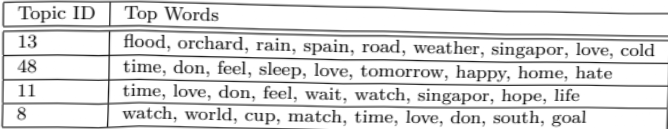

> table

**table** (confidence 0.96)

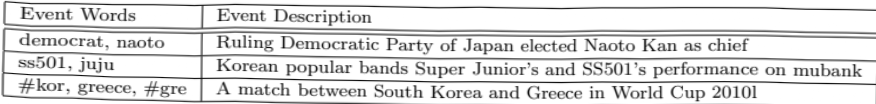

> table

## Page 52

52

AGUILAR, J., BELLER, C., MCNAMEE, P., AND VAN DURME, B.2014. A comparison of the events and relations across ace, ere, tac-kbp, and framenet annotation standards. 2nd Workshop on Events: Definition, Detection, Coreference and Representation, NAACL-HLT, 45.AHN, D. 2006. The stages of event extraction. In Proc. COLING/ACL 2006 Workshop on Annotating and Reasoning about Time and Events. 1-8.
ALLEN, J. F. 1983. Maintaining knowledge about temporal intervals. Communications of the ACM26. 11. 832-843.
ALLEN, J. F. 1984. Towards a general theory of action and time. Artificial intelligence 23, 2,
123-154.
ALPAYDIN, E. 2010. Introduction to machine learning. The MIT Press.ANGELI, G., MANNING, C. D., AND JURAFSKY, D. 2012. Parsing time: Learning to interpret time expressions. In Proceedings of the 2012 Conference of the North American Chapter of the Association for Computational Linguistics: Human Language Technologies. 446–455.AONE, C. AND RAMOs-SANTACRUz, M. 2000. Rees: a large-scale relation and event extraction system. In Proceedings of the sixth conference on Applied natural language processing. Association for Computational Linguistics, 76–83.
BAGGA, A. AND BALDWIN, B. 1998. Algorithms for scoring coreference chains. In The first international conference on language resources and evaluation workshop on linguistics coreference.
Vol.1.563–566.
BAGGA, A. AND BALDWIN, B. 1999. Cross-document event coreference: Annotations, experiments,and observations. In Proceedings of the Workshop on Coreference and its Applications. 1–8.Linguistics, 86–90.
BAKER, M. 1988. Incorporation: A theory of grammatical function changing. University of Chicago Press Chicago.
BARNEs, J. ET AL. 1984. The complete works of Aristotle: The revised Oxford translation. Vol.1.
Bollingen Foundation.
BEAL, M. J., GHAHRAMANI, Z., AND RASMUSSEN, C. E. 2001. The infinite hidden markov model.
In Advances in neural information processing systems. 577-584.
BEJAN, C., TITswORTH, M., HICKL, A., AND HARABAGIU, S. 2009. Nonparametric bayesian models for unsupervised event coreference resolution. Advances in Neural Information Processing Systems 23.
BEJAN, C. A. AND HARABAGIU, S. 2010. Unsupervised event coreference resolution with rich linguistic features. In Proceedings of the 48th Annual Meeting of the Association for Computational Linquistics. 1412-1422.
BEJAN, C. A. AND HATHAWAY, C. 2007. Utd-srl: a pipeline architecture for extracting frame semantic structures. In Proceedings of the 4th International Workshop on Semantic Evaluations.460-463.
BELVIN, R.1993. The two causative haves are the two possessive haves. MIT working papers in linguistics 20, 19–34.
BERGER, A. L., PIETRA, V. J. D., AND PIETRA, S. A. D. 1996. A maximum entropy approach to natural language processing. Computational linguistics 22, 1, 39–71.BETHARD, S. AND MARTIN, J. 2006. Identification of event mentions and their semantic class.Association for Computational Linguistics, 146–154.
BJÖRNE, J., GINTER, F., AND SALAKOSKI, T. 2012. University of turku in the bionlp'11 shared task. BMC bioinformatics 13, Suppl 11, S4.
BJÖRNE, J., HEIMONEN, J., GINTER, F., AIROLA, A., PAHIKKALA, T., AND SALAKOSKI, T. 2009.Extracting complex biological events with rich graph-based feature sets. In Proceedings of the Workshop on Current Trends in Biomedical Natural Language Processing: Shared Task.Association for Computational Linguistics, 10–18.

ACM Transactions, Vol. V, No. N, March 2022.

## Page 53

53

BJÖRNE, J. AND SALAKOsKI, T. 2011. Generalizing biomedical event extraction. In Proceedings of the BioNLP Shared Task 2011 Workshop. Association for Computational Linguistics, 183–191.BOSSY,R., JOURDE, J., BESSIERES, P., VAN DE GUCHTE, M., AND NÉDELLEC, C. 2011. BioNLP Shared Task 2011: Bacteria Biotope. In Proceedings of the BioNLP Shared Task 2011 Workshop. Association for Computational Linguistics, 56–64.
BRESNAN, J. 1982. The mental representation of grammatical relations. Vol. 170. MIT press Cambridge, MA.
CARLsoN, L. 1981. Aspect and quantification in tense and aspect. ed. by philip tedeschi and annie zaenen. Syntax and Semantics Ann Arbor, Mich. 14, 31-64.
CHAMBERs, N. AND JURAFSKY, D. 2011. Template-based information extraction without the templates. In Proceedings of ACL.
CHAMBERs, N., WANG, S., AND JURAFSKY, D. 2007. Classifying temporal relations between events.In Proceedings of the 45th Annual Meeting of the ACL on Interactive Poster and Demonstration Sessions. Association for Computational Linguistics, 173–176.
CHARNIAK, E. AND JoHNSON, M. 2005. Coarse-to-fine n-best parsing and maxent discriminative reranking. In Proceedings of the 43rd Annual Meeting on Association for Computational Linguistics. Association for Computational Linguistics, 173–180.
CHAROENPORN, T., SORNLERTLAMVANICH, V., MOKARAT,C., AND ISAHARA, H. 2008. Semiautomatic compilation of asian wordnet. In 14th Annual Meeting of the Association for Natural Language Processing. 1041-1044.
CHEN, Z. AND JI, H. 2009. Graph-based event coreference resolution. In Proceedings of the 2009Workshop on Graph-based Methods for Natural Language Processing. 54–57.CHINCHOR, N. AND MARSH, E. 1998. Muc-7 information extraction task definition. In Proceeding of the seventh message understanding conference (MUC-7), Appendices. 359–367.CoLLINs, M. 1999. Head-driven statistical models for natural language parsing. Ph.D. thesis,University of Pennsylvania.
CoLLINs, M. 2003. Head-driven statistical models for natural language parsing. Computational linguistics 29, 4, 589–637.
CYBULSKA, A. AND VosSEN, P. 2010. Event models for historical perspectives: Determining relations between high and low level events in text, based on the classification of time, location and participants. In Proceedings of LREC. 17–23.
CYBULSKA, A. AND VossEN, P. 2011. Historical event extraction from text. ACL HLT 2011Workshop on Language Technology for Cultural Heritage, Social Sciences, and Humanities (LaTeCH 2011), 39.
CYBULSKA, A. AND VosSEN, P. 2014a. Guidelines for ecb+ annotation of events and their coreference. Tech. rep., Technical report, Technical Report NWR-2014-1, VU University Amsterdam.CYBULSKA, A. AND VossEN, P. 2014b. Using a sledgehammer to crack a nut? lexical diversity and event coreference resolution. In Proceedings of the Ninth International Conference on Language Resources and Evaluation (LREC'14). 4545–4552.
CYBULSKA, A. AND VossEN, P. 2015. Translating granularity of event slots into features for event coreference resolution. In Proceedings of the 3rd Workshop on EVENTS at the NAACL-HLT.
1-10.
memory-based learner. Tilburg University.
ph.d. dissertation, university of pennsylvania.
DAUBECHIEs, I. ET AL. 1992. Ten lectures on wavelets. Vol. 61. SIAM.DAUMé III, H. 2004. Notes on cg and lm-bfgs optimization of logistic regression. Pahttp://hal3.name/megam.

ACM Transactions, Vol. V, No. N, March 2022.

## Page 54

54

DAVIDsON, D. 1967, 2001. Essays on actions and events. Vol. 1. Oxford University Press, USA.DE MARNEFFE, M.-C., MACCARTNEY, B., AND MANNING, C. D. 2006. Generating typed dependency parses from phrase structure parses. In Proceedings of LREC. Vol. 6. 449–454.DE MARNEFFE, M.-C. AND MANNING, C. D. 2008. The stanford typed dependencies representation. In Coling 2008: Proceedings of the workshop on Cross-Framework and Cross-Domain Parser Evaluation. Association for Computational Linguistics, 1-8.DELMONTE, R. 2013. Coping with implicit arguments and events coreference. NAA CL HLT 2013,1.
DODDINGTON, G., MITCHELL, A., PRZYBOCKI, M., RAMSHAW, L., STRASSEL, S., AND WEISCHEDEL,R. 2004. The automatic content extraction (ace) program-tasks, data, and evaluation. In Proceedings of LREC. Vol. 4. 837-840.
DoRR, B. 1997. Large-scale dictionary construction for foreign language tutoring and interlingual machine translation. Machine Translation 12, 4, 271-322.
DowTY, D. 1979. Word meaning and Montague grammar: The semantics of verbs and times in generative semantics and in Montague's PTQ. Vol. 7. Springer.
DowTY, D. 1991. Thematic proto-roles and argument selection. Language, 547–619.FELLBAUM, C. 2010. Wordnet. Theory and Applications of Ontology: Computer Applications 231-243.
FERGUSoN, T. S. 1973. A bayesian analysis of some nonparametric problems. The annals of statistics, 209–230.
FILAToVA, E. AND HATzIVASSILOGLOU, V. 2004. Event-based extractive summarization. In Proceedings of ACL Workshop on Summarization.
FILLMORE, C. 1968. The case for case. universals in linguistic theory, ed. by emmon bach &z robert t. harms, 1-88.
FILLMORE, C. 1976. Frame semantics and the nature of language. Annals of the New York Academy of Sciences 280, 1, 20–32.
FILLMORE, C. 1977. The case for case reopened. Syntax and semantics 8, 1977, 59–82.FILLMORE, C. 2006. Frame semantics. Cognitive linguistics: basic readings, 185–238.FILLMORE, C. AND BAKER, C. 2001a. Frame semantics for text understanding. In Proceedings of WordNet and Other Lerical Resources Workshop. Pittsburgh, NAACL, 3–5.FILLMORE, C. AND BAKER, C. 2001b. Frame semantics for text understanding. In Proceedings of WordNet and Other Lerical Resources Workshop. Pittsburgh, NAACL, 3–5.FILLMORE, C., JOHNSON, C., AND PETRUCK, M. 2003. Background to framenet. International journal of lericography 16, 3, 235–250.
FLORIAN, R., HASSAN, H., ITTYCHERIAH, A., JING, H., KAMBHATLA, N., LUO, X., NICOLOV, N.,AND RoUKos, S. 2004. A statistical model for multilingual entity detection and tracking. In HLT-NAACL.
GABBARD, R., KULICK, S., AND MARCUs, M. 2006. Fully parsing the Penn Treebank. In Proceedings of the Human Language Technology Conference of the NAACL, Main Conference.
184-191.
GABRILoVICH, E., DUMAIs, S., AND HORVITz, E. 2004. Newsjunkie: providing personalized newsfeeds via analysis of information novelty. In Proceedings of the 13th international conference on World Wide Web. ACM, 482-490.
GAEL, J. V., TEH, Y. W., AND GHAHRAMANI, Z.2009. The infinite factorial hidden markov model.In Advances in Neural Information Processing Systems. 1697-1704.
semantic Web, 223–233.
database. In HLT-NAACL. 758-764.
process. In Advances in neural information processing systems. 475–482.

ACM Transactions, Vol. V, No. N, March 2022.

## Page 55

55

GILDEA, D. AND JURAFSKY, D. 2002. Automatic labeling of semantic roles. Computational linguistics 28, 3, 245–288.
GRIFFITHs, T. L. AND STEYVERs, M. 2004. Finding scientific topics. Proceedings of the National academy of Sciences of the United States of America 101, Suppl 1, 5228–5235.GRIMsHAw, J. 1990. Argument structure. the MIT Press.
GRIMSHAw, J. AND JACKENDOFF, R. 1981. Brandeis verb lexicon. Electronic database funded by National Science Foundation Grant NSF IST-81-20403 awarded to Brandeis University.GRISHMAN, R., MACLEOD, C., AND MEYERs, A. 1994. Comlex syntax: Building a computational lexicon. In Proceedings of the 15th conference on Computational linguistics- Volume 1. Association for Computational Linguistics, 268–272.
GROoVER, C., ToBIN, R., ALEX, B., AND BYRNE, K. 2010. Edinburgh-ltg: Tempeval-2 system description. In Proceedings of the 5th International Workshop on Semantic Evaluation. Association for Computational Linguistics, 333–336.
GRUBER, J. 1965. Studies in lexical relations. Ph.D. thesis, Massachusetts Institute of Technology.GUSEV, A., CHAMBERS, N., KHAITAN, P., KHILNANI, D., BETHARD, S., AND JURAFSKY, D. 2011.Using query patterns to learn the duration of events. In Proceedings of the ninth international conference on computational semantics. 145–154.
HABASH, N. AND DORR, B. 2002. Handling translation divergences: Combining statistical and symbolic techniques in generation-heavy machine translation. Machine Translation: From Research to Real Users, 84–93.
HAFFNER, P. 2006. Scaling large margin classifiers for spoken language understanding. Speech Communication 48, 3, 239–261.
HAGHIGHI, A. AND KLEIN, D. 2007. Unsupervised coreference resolution in a nonparametric bayesian model. In Annual meeting-Association for Computational Linguistics. VoI. 45.848.HALPERN, J. Y. AND PEARL, J. 2005. Causes and explanations: A structural-model approach.part i: Causes. The British journal for the philosophy of science 56, 4, 843–887.HAMILTON, E., CAIRNS, H., ET AL. 1961. Plato, the collected dialogues. Vol. 71. Bollingen.HAN,C., LAVOIE, B., PALMER, M., RAMBOW, ., KITTREDGE, R., KORELSKY, T., KIM,N., AND KIM, M. 2000. Handling structural divergences and recovering dropped arguments in a korean/english machine translation system. Envisioning Machine Translation in the Information Future, 168–176.
HEAFIELD, K., PoUzYREVSKY, I., CLARK, J. H., AND KOEHN, P. 2013. Scalable modified kneserney language model estimation. In ACL (2). 690–696.
HIGGINBOTHAM, J. 1985. On semantics. Linguistic inquiry 16, 4, 547–593.HoBBs, J. R. 1985. Ontological promiscuity. In Proceedings of the 23rd annual meeting on Association for Computational Linguistics. Association for Computational Linguistics, 60–69.HoEKSEMA, J. 1983. Plurality and conjunction. Studies in modeltheoretic semantics 1, 63–83.HoRNBY, A., Ed. 1980. Oxford Advanced Learner's Dictionary of Current English. Vol. 1428.HovY, E. 2003. Using an ontology to simplify data access. Communications of the ACM 46, 1,Cambridge Univ Press.
HoVY, E., MARCUS, M., PALMER, M., RAMSHAW, L., AND WEISCHEDEL, R. 2006. Ontonotes: the 47-49.
90% solution. In Proceedings of the Human Language Technology Conference of the NAACL,Companion Volume: Short Papers. Association for Computational Linguistics, 57–60.Detection, Coreference and Representation. Vol. 2013. 21.
Resolution for Unrestricted Terts. 75–81.
。不下3不T7T表下事51空空0à

ACM Transactions, Vol. V, No. N, March 2022

## Page 56

56

IPSEN, I. C. AND WILLS, R. S. 2006. Mathematical properties and analysis of googles pagerank.Bol. Soc. Esp. Mat. Apl 34, 191−196.
JACKENDoFF, R. 1985. Semantics and cognition. Vol. 8. The MIT Press.JoACHIMs, T. 1998. Text categorization with support vector machines: Learning with many relevant features. Machine Learning:ECML-98, 137–142.
JoHNsoN, M. AND URAL, A. E. 2010. Reranking the Berkeley and Brown parsers. In Human Language Technologies: The 2010 Annual Conference of the North American Chapter of the Association for Computational Linguistics. Association for Computational Linguistics, 665–668.
JosHI, A. 1985. How much context sensitivity is necessary for characterizing structural descriptions: Tree adjoining grammars. Natural language parsing: Psychological, computational and theoretical perspectives, 206–250.
JOURDE, J., MANINE, A.-P., VEBER, P., FORT, K., BOSSY, R., ALPHONSE, E., AND BESSIERES, P.2011. BioNLP Shared Task 2011: Bacteria Gene Interactions and Renaming. In Proceedings of the BioNLP Shared Task 2011 Workshop. Association for Computational Linguistics, 65–73.JUNG, H. AND STENT, A. 2013. Att1: Temporal annotation using big windows and rich syntactic and semantic features. In Second Joint Conference on Lerical and Computational Semantics (*SEM).Vol.2.20-24.
JURAFSKY, D. AND MARTIN, J. H. 2000. Speech and language processing: An introduction to natural language processing, computational linguistics, and speech recognition.KAISER, G. 2011. A friendly guide to wavelets. Springer.
KATz, J. AND FoDOR, J. 1963. The structure of a semantic theory. Language 39, 2, 170–210.KENNY, A. 1963, 2003. Action, emotion and will. Psychology Press.KIM, J., OHTA, T., PYYSALO, S., KANO, Y., AND TsuJII, J. 2009. Overview of bionlp'09 shared task on event extraction. In Proceedings of the Workshop on Current Trends in Biomedical Natural Language Processing: Shared Task. Association for Computational Linguistics, 1–9.KIM, J., OHTA, T., TATEISI, Y., AND TsUJIl, J. 2003. Genia corpusa semantically annotated corpus for bio-textmining. Bioinformatics 19, suppl 1, il80-i182.
KIM, J., WANG, Y., TAKAGI, T., AND YONEZAWa, A. 2011. Overview of Genia event task in BioNLP Shared Task 2011. ACL HLT 2011, 7.
KINGSBURY, P. AND PALMER, M. 2002. From treebank to propbank. In Proceedings of the 3rd International Conference on Language Resources and Evaluation (LREC-2002). Citeseer,
1989-1993.
KINGSBURY, P. AND PALMER, M. 2003. Propbank: the next level of treebank. In Proceedings of Treebanks and lerical Theories. Vol. 3.
KIPPER, K., DANG, H., AND PALMER, M. 2000. Class-based construction of a verb lexicon. In Proceedings of the National Conference on Artificial Intelligence. Menlo Park, CA; Cambridge,
MA; London; AAAI Press; MIT Press; 1999, 691–696.
KIPPER, K., DANG, H., SCHULER, W., AND PALMER, M. 2000. Building a class-based verb lexicon using tags. In TAG+ 5 Fifth International Workshop on Tree Adjoining Grammars and Related Formalisms. Citeseer, 147–154.
KIPPER, K., KORHONEN, A., RYANT, N., AND PALMER, M. 2008. A large-scale classification of english verbs. Language Resources and Evaluation 42, 1, 21-40.
KIPPER-SCHULER, K. 2005. Verbnet: A broad-coverage, comprehensive verb lexicon, ph.d. dissertation, university of pennsylvania.
KLEINBERG, J. 2003. Bursty and hierarchical structure in streams. Data Mining and Knowledge Discovery 7, 4, 373–397.
KoMODAKIs, N., PARAGIOs, N., AND TzIRITAS, G. 2007. Mrf optimization via dual decomposition:Message-passing revisited. In Computer Vision, 2007. ICCV 2007. IEEE 11th International Conference on. IEEE, 1-8.
KoRHONEN, A. AND BRIscOE, T.2004. Extended lexical-semantic classification of english verbs. In Proceedings of the HLT-NAACL Workshop on Computational Lexical Semantics. Association for Computational Linguistics, 38–45.

ACM Transactions, Vol. V, No. N, March 2022.

## Page 57

57

KoZAREVA, Z. AND HoVY, E. 2010. Learning arguments and supertypes of semantic relations using recursive patterns. In Proceedings of the 48th Annual Meeting of the Association for Computational Linguistics. Association for Computational Linguistics, 1482–1491.KUDo, T. AND MATSUMOTo, Y. 2001. Chunking with support vector machines. In Proceedings of the second meeting of the North American Chapter of the Association for Computational Linguistics on Language technologies. 1-8.
LAFFERTY, J., MCCALLUM, A., AND PEREIRA, F. C. 2001. Conditional random fields: Probabilistic models for segmenting and labeling sequence data. In Proceedings of the International Conference on Machine Learning.
LEE, H., RECASENS, M., CHANG, A., SURDEANU, M., AND JURAFSKY, D. 2012. Joint entity and event coreference resolution across documents. In Proceedings of the 2012 Joint Conference on Empirical Methods in Natural Language Processing and Computational Natural Language Learning. 489–500.
LEVIN, B., Ed. 1985. Lerical Semantics in Review. Lexicon Project Working Papers 1, Center for Cognitive Science, MIT, Cambridge, MA.
LEVIN, B. 1993. English verb classes and alternations: A preliminary investigation. Vol. 348.University of Chicago press Chicago, IL.
LEVIN, B. AND HoVAV, M. 1995. Unaccusativity: At the syntax-lerical semantics interface. Vol. 26.
The MIT Press.
LEwIs, D. 1973. Causation. The journal of philosophy, 556–567.
LLORENS, H., SAQUETE, E., AND NAVARRO, B. 2010. Tipsem (english and spanish): Evaluating crfs and semantic roles in tempeval-2. In Proceedings of the 5th International Work:shop on Semantic Evaluation. Association for Computational Linguistics, 284–291.LLoYD, G. 1968. Aristotle: the growth and structure of his thought. Cambridge University Press.LUO, X.2005. On coreference resolution performance metrics. In Proceedings of the conference on Human Language Technology and Empirical Methods in Natural Language Processing. 25–32.MACLEOD, C., GRISHMAN, R., MEYERS, A., BARRETT, L., AND REEVES, R. 1998. Nomlex: A lexicon of nominalizations. In Proceedings of the 8th International Congress of the European Association for Lericography. Citeseer, 187–193.
MAHESH, K., NIRENBURG, S., ET AL. 1995. A situated ontology for practical nlp. In Proceedings of the IJCAI-95 Workshop on Basic Ontological Issues in Knowledge Sharing. Vol. 19. Citeseer,21.
MANI, I. AND WILSON, G. 2000. Robust temporal processing of news. In Proceedings of the 38th Annual Meeting on Association for Computational Linguistics. Association for Computational Linguistics, 69–76.
MARCUs, M., MARCINKIEWICz, M., AND SANTORINI, B. 1993. Building a large annotated corpus of english: The penn treebank. Computational linguistics 19, 2, 313–330.McCLoskY, D. 2010. Any domain parsing: automatic domain adaptation for natural language parsing, ph.d. thesis.
McCLOskY, D., SURDEANU, M., AND MANNING, C. D. 2011. Event extraction as dependency for Computational Linguistics, 41-45.
McDONALD, R. AND PEREIRA, F. 2006. Online learning of approximate dependency parsing algorithms. In Proceedings of EACL. Vol. 6.81–88.
tional Linguistics, 523–530.
MENZIEs, P. 1999. Intrinsic versus extrinsic conceptions of causation. In Causation and laws of (LREC).
nature. Springer, 313–329.
MENzIEs, P. 2008. Counterfactual theories of causation.

ACM Transactions, Vol. V, No. N, March 2022

## Page 58

58

MEYERS, A., GRISHMAN, R., KOSAKA, M., AND ZHAO, S. 2001. Covering treebanks with glarf. In Proceedings of the ACL 2001 Workshop on Sharing Tools and Resources- Volume 15. Association for Computational Linguistics, 51-58.
MEYERS, A., MACLEOD, C., YANGARBER, R., GRISHMAN, R., BARRETT, L., REEVES, R., ET AL.1998. Using nomlex to produce nominalization patterns for information extraction. In Proceedings: the Computational Treatment of Nominals, Montreal, Canada, (Coling-A CL98 workshop).Vol.2.
MLLER, G. 1995. Wordnet: a lexical database for english. Communications of the A CM 38, 11,
39-41.
MoENs, M. 1987. Tense, aspect and temporal reference, ph.d. dissertation.MOENS, M. AND STEEDMAN, M. 1988. Temporal ontology and temporal reference. Computational linguistics 14, 2, 15–28.
MoREDA, P., NAVARRO, B., AND PALOMAR, M. 2007. Corpus-based semantic role approach in information retrieval. Data  Knowledge Engineering 61, 3, 467–483.MouRELATOs, A. 1978. Events, processes, and states. Linguistics and philosophy 2, 3, 415–434.NAPOLES, C., GORMLEY, M., AND VAN DURME, B. 2012. Annotated gigaword. In Proceedings of the Joint Workshop on Automatic Knowledge Base Construction and Web-scale Knowledge Ertraction. Association for Computational Linguistics, 95–100.
NAUGHTON, M., STOKES,N., AND CARTHY, J. 2008. Investigating statistical techniques for sentence-level event classification. In Proceedings of the 22nd International Conference on Computational Linguistics- Volume 1. Association for Computational Linguistics, 617–624.NEwMAN, M. E.2004. Fast algorithm for detecting community structure in networks. Physical review E 69, 6, 066133.
NEwMAN, M. E. 2006. Modularity and community structure in networks. Proceedings of the National Academy of Sciences 103, 23, 8577–8582.
NILES, I. AND PEASE, A. 2001. Towards a standard upper ontology. In Proceedings of the international conference on Formal Ontology in Information Systems- Volume 2001. ACM, 2–9.OHTA, T., PYYSALO, S., AND TsUJII, J. 2011. Overview of the epigenetics and post-translational modifications (epi) task of bionlp shared task 2011. In Proceedings of the BioNLP Shared Task:2011 Workshop. Association for Computational Linguistics, 16–25.
ONGENAERT, M., VAN NESTE, L., DE MEYER, T., MENSCHAERT, G., BEKAERT, S., AND VAN CRIEKINGE, W. 2008. Pubmeth: a cancer methylation database combining text-mining and expert annotation. Nucleic Acids Research 36, suppl 1, D842-D846.ORFANIDIs, S. J. 1985. Optimum signal processing: an introduction. Macmillan New York.PALMER, M., BABKO-MALAYA, O., AND DANG, H. 2004. Different sense granularities for different applications. In Proceedings of Workshop on Scalable Natural Language Understanding.PALMER, M., DANG, H., AND FELLBAUM, C. 2007. Making fine-grained and coarse-grained sense distinctions, both manually and automatically. Natural Language Engineering 13, 2, 137.PALMER, M., GILDEA, D., AND KINGSBURY, P. 2005. The proposition bank: An annotated corpus of semantic roles. Computational Linguistics 31, 1, 71-106.
PARsoNS, T. 1990. Events in the Semantics of English. MIT Pr.
PERLMUTTER, D. M. 1978. mpersonal passives and the unaccusative hypothesis. In Proc. of the 4th Annual Meeting of the Berkeley Linguistics Society. UC Berkeley, 157–189.PETRuCK, M. 1996. Frame semantics. Handbook of pragmatics, 1-13.
PHILPOT, A., HoVY, E., AND PANTEL, P. 2005. The omega ontology. In Proceedings of the ONTOLEX Workshop at the International Conference on Natural Language Processing (IJCNLP).
PINKER, S. 1989. Learnability and cognition: The acquisition of argument structure. The MIT Press.
PoRTER, M. F. 1980. An algorithm for suffix stripping. Program: electronic library and information systems 14, 3, 130-137.

ACM Transactions, Vol. V, No. N, March 2022.

## Page 59

59

PRADHAN, S., RAMSHAW, L., MARCUS, M., PALMER, M., WEISCHEDEL, R., AND XUE, N.2011.Conll-2011 shared task: Modeling unrestricted coreference in ontonotes. In Proceedings of the Fifteenth Conference on Computational Natural Language Learning: Shared Task. 1–27.PRADHAN, S. S., RAMSHAW, L., WEISCHEDEL, R., MACBRIDE, J., AND MICCIULLA, L. 2007. Unrestricted coreference: Identifying entities and events in ontonotes. In Semantic Computing,2007. ICSC 2007. International Conference on. IEEE, 446–453.
PRADHAN, S. S., WARD, W., HACIOGLU, K., MARTIN, J. H., AND JURAFSKY, D. 2004. Shallow semantic parsing using support vector machines. In HLT-NAA CL. 233–240.PRASAD, R., DINESH, N., LEE, A., MILTSAKAKI, E., ROBALDO, L., JOSHI, A., AND WEBBER, B.2008. The penn discourse treebank 2.0. In Proceedings of the 6th International Conference on Language Resources and Evaluation (LREC 2008). Citeseer, 2961.PREsCHER, D., RIEZLER, S., AND RoOTH, M. 2000. Using a probabilistic class-based lexicon for lexical ambiguity resolution. In Proceedings of the 18th conference on Computational linguisticsVolume 2. Association for Computational Linguistics, 649–655.
PUNYAKANOK, V., RoTH, D., YIH, W.-T., ZIMAK, D., AND Tu, Y. 2004. Semantic role labeling via generalized inference over classifiers. 130–133.
PuSTEJOvSKY, J. 1991a. The generative lexicon. Computational linguistics 17, 4, 409–441.PusTEJovSKY, J. 1991b. The syntax of event structure. Cognition 41, 1, 47–81.PUSTEJOVSKY, J., CASTANO, J., INGRIA, R., SAURI, R., GAIZAUSKAS, R., SETZER, A., KATZ, G.,AND RADEV, D. 2003. Timeml: Robust specification of event and temporal expressions in text.
New Directions in Question Answering 2003, 28–34.
PUSTEJOVSKY, J., HANKS, P., SAURI, R., SEE, A., GAIZAUSKAS, R., SETZER, A., RADEV, D.,SUNDHEIM, B., DAY, D., FERRO, L., ET AL. 2003. The Timebank corpus. In Corpus Linguistics.
Vol.2003.40.
PuSTEJOVsKY, J., MEYERS, A., PALMER, M., AND POESIO, M. 2005. Merging propbank, nombank, timebank, penn discourse treebank and coreference. In Proceedings of the Workshop on Frontiers in Corpus Annotations II: Pie in the Sky. Association for Computational Linguistics,
5-12.
PYYSALO, S., OHTA, T., RAK, R., SULLIVAN, D., MAO, C., WANG, C., SOBRAL, B., TSUJII, J., AND ANANIADoU, S. 2011. Overview of the infectious diseases (id) task of bionlp shared task 2011.In Proceedings of the BioNLP Shared Task 2011 Workshop. Association for Computational Linguistics, 26–35.
QuILLIAN, M. R. 1968. Semantic Information Processing,. The MIT Press, Cambridge, MA,Chapter Semantic Memory, or CHAPTER.
QuINE, W. V. 1956. Quantifiers and propositional attitudes. the Journal of Philosophy, 177–187.RABINER, L. R. 1989. A tutorial on hidden markov models and selected applications in speech recognition. Proceedings of the IEEE 77, 2, 257–286.
RAMSHAw, L. A. AND MARCus, M. P. 1995. Text chunking using transformation-based learning.Third Workshop on Very Large Corpora (WVLC-3) at the Annual Meeting of the Association for Computational Linguistics, 82–94.
RAPPAPORT, M. AND LEVIN, B. 1988. What to do with theta-roles in thematic relations. Syntax RASTOGI, P. AND VAN DURME, B. 2014. Augmenting framenet via ppdb. NAACL 2014, Workshop and semantics 21, 7–36.
on Events: Definition, Detection, Coreference and Representation, 1.
Machine learning 34, 1-3, 151-175.
Natural Language Engineering 17, 04, 485–510.
Association for Computational Linguistics, 46–50.t王开1王元五元3万z天1à疗00

ACM Transactions, Vol. V, No. N, March 2022

## Page 60

60

RIEDEL, S., MCCLOSKY, D., SURDEANU, M., MCCALLUM, A., AND MANNING, C. D. 2011. Model combination for event extraction in bionlp 2011. In Proceedings of the BioNLP Shared Task:2011 Workshop. Association for Computational Linguistics, 51-55.RIGO, S. AND LAVELLI, A. 2011. Multisex-a multi-language timex sequential extractor. In 2011Eighteenth International Symposium on Temporal Representation and Reasoning. 163-170.RITTER, A., CLARK, S., ETzIONI, O., ET AL. 2011. Named entity recognition in tweets: an experimental study. In Proceedings of the Conference on Empirical Methods in Natural Language Processing. Association for Computational Linguistics, 1524–1534.RITTER, A., ErzIONI, O., ET AL. 2010. A latent dirichlet allocation method for selectional preferences. In Proceedings of the 48th Annual Meeting of the Association for Computational Linguistics. Association for Computational Linguistics, 424-434.
RITTER, A., ETzIONI, O., CLARK, S., ET AL. 2012. Open domain event extraction from twitter. In Proceedings of the 18th ACM SIGKDD international conference on Knowledge discovery and data mining. ACM, 1104-1112.
RITTER, E. AND RosEN, S. 1996. Strong and weak predicates: Reducing the lexical burden.
Linguistic Analysis 26, 1-2, 29–62.
RoBERrs, K. AND HARABAGIU, S. M. 2011. Unsupervised learning of selectional restrictions and detection of argument coercions. In Proceedings of the Conference on Empirical Methods in Natural Language Processing. Association for Computational Linguistics, 980–990.ROBKOP,K., THOONGSUP, S., CHAROENPORN, T., SORNLERTLAMVANICH, V., AND ISAHARA, H.2010. Wnms: Connecting the distributed wordnet in the case of asian wordnet. In Principles, Construction, and Applications of Multilingual Wordnets. Proceedings of the Fifth Global WordNet Conference (G WC 2010), India. Narosa Publishing.
RosEN, C. 1984. The interface between semantic roles and initial grammatical relations. Studies in relational grammar 2, 38-77.
RoSEN, S. 1996. Events and verb classification. Linguistics 34, 191–223.RosEN, S. 1999. The syntactic representation of linguistic events. Glot International 4, 2, 3–11.RUDINGER, R. AND VAN DURME, B. 2014. Is the stanford dependency representation semantic?
ACL2014,54.
RUPPENHOFER, J., ELLSWORTH, M., PETRUCK,M., JOHNSON,C., AND SCHEFFCZYK,J. 2006.Framenet ii: Extended theory and practice. International Computer Science Institute.RUSH, A. M., SoNTAG, D., CoLLINS, M., AND JAAKKOLA, T. 2010. On dual decomposition and linear programming relaxations for natural language processing. In Proceedings of the 2010Conference on Empirical Methods in Natural Language Processing. Association for Computational Linguistics, 1-11.
SAGER, N.1981. Natural language information processing. Addison-Wesley Publishing Company,Advanced Book Program.
SAMEER, S., HOVY, E., MARCUS, M., PALMER, M., RAMSHAW, L., AND WEISCHEDEL, R. 2007.Ontonotes: A unified relational semantic representation. International Journal of Semantic Computing 1, 04, 405-419.
SANFILIPPo, A. 1994. Lkb encoding of lexical knowledge. In Inheritance, defaults and the lericon.Cambridge University Press, 190–222.
SAURÍ, R., KNIPPEN, R., VERHAGEN, M., AND PUSTEJOVSKY, J. 2005. Evita: a robust event recognizer for qa systems. In Proceedings of the conference on Human Language Technology and Empirical Methods in Natural Language Processing. Association for Computational Linguistics,
700-707.
SAURI, R., LITTMAN, J., KNIPPEN, B., GAIZAUSKAS, R., SETZER, A., AND PUSTEJOVSKY, J.2005.Timeml annotation guidelines, http://www.timeml.org/timemldocs/annguide14.pdf.SCHABEs, Y. 1990. Mathematical and computational aspects of lexicalized grammars, ph.d. dissertation, university of pennsylvania.
SCHULER, K. 2005. Verbnet:A broad-coverage, comprehensive verb lexicon. Ph.D. thesis, Dissertations available from ProQuest, University of Pennsylvania.

ACM Transactions, Vol. V, No. N, March 2022.

## Page 61

61

SÉAGHDHA, D. O. 2010. Latent variable models of selectional preference. In Proceedings of the 48th Annual Meeting of the Association for Computational Linguistics. Association for Computational Linguistics, 435–444.
SETzER, A. 2001. Temporal information in newswire articles: an annotation scheme and corpus study. Ph.D. thesis, University of Sheffield Sheffield, UK.
SETzER, A. AND GAIZAUSKAS, R. J. 2000. Annotating events and temporal information in newswire texts. In LREC. Vol. 2000. 1287–1294.
SHI, L. AND MIHALCEA, R. 2005. Putting pieces together: Combining framenet, verbnet and wordnet for robust semantic parsing. Computational Linguistics and Intelligent Text Processing,100-111.
SINHA, M., REDDY, M., AND BHATTACHARYYA, P. 2006. An approach towards construction and application of multilingual indo-wordnet. In 3rd Global Wordnet Conference (GWC 06), Jeju Island, Korea.
SMITH, C. 1997. The parameter of aspect. Vol. 43. Springer.
SORNLERTLAMVANICH, V., CHAROENPORN, T., ROBKOP, K., MOKARAT, C., AND ISAHARA, H.2009.Review on development of asian wordnet.
STYLER IV, W. F., BETHARD, S., FINAN, S., PALMER, M., PRADHAN, S., DE GROEN, P. C.,ERICKSON, B., MiLLER, T., LIN, C., SAVOVA, G., ET AL. 2014. Temporal annotation in the clinical domain. Transactions of the Association for Computational Linguistics 2, 143–154.2004 Conference on Empirical Methods in Natural Language Processing. 95–102.In Proceedings of the Interdisciplinary Workshop on the Identification and Representation of Verb Features and Verb Classes. 115–120.
and syntactic description 3, 57–149.
Journal of the american statistical association 101, 476.
TENNY, C. 1994. Aspectual roles and the syntax-semantics interface. Vol.52. Springer Verlag.TER MEULEN, A. 1983. The representation of time in natural language. Studies in modeltheoretic semantics, Dordrecht, Foris Publications, 177–191.
TER MEULEN, A. 1997. Representing time in natural language: The dynamic interpretation of tense and aspect. The MIT Press.
TSOCHANTARIDIS, I., JOACHIMS, T., HOFMANN, T., ALTUN, Y., AND SINGER, Y.2006. Large margin methods for structured and interdependent output variables. Journal of Machine Learning Research 6, 2, 1453.
UzZAMAN, N. AND ALLEN, J. F. 2010. Trips and trios system for tempeval-2: Extracting temporal information from text. In Proceedings of the 5th International Workshop on Semantic UzZAMAN, N., LLORENS, H., ALLEN, J., DERCZYNSKI, L., VERHAGEN, M., AND PUSTEJOVSKY, J.Evaluation. 276–283.
2012. Tempeval-3: Evaluating events, time expressions, and temporal relations. arXiv preprint VAN GAEL, J., SAATCI, Y., TEH, Y. W., AND GHAHRAMANI, Z. 2008. Beam sampling for the arXiv:1206.5333.
infinite hidden markov model. In Proceedings of the 25th international conference on Machine learning. 1088–1095.
VAN VooRST, J. 1988. Event structure. Vol. 59. John Benjamins Publishing Co.VAPNIk, V. 1995. The nature of statistical learning theory. Data mining and knowledge discovVENDLER, Z. 1967. Linguistics in philosophy. Cornell University Press Ithaca.ery 6, 1-47.
ation for Computational Linguistics, 57–62.一一置表不置7置一一一一1度究空究

ACM Transactions, Vol. V, No. N, March 2022

## Page 62

62

VERKUYL, H. 1996. A theory of aspectuality: The interaction between temporal and atemporal structure. Vol. 64. Cambridge University Press.
VILAIN,M., BURGER, J., ABERDEEN, J., CONNOLLY,D., AND HIRSCHMAN, L. 1995. A modeltheoretic coreference scoring scheme. In Proceedings of the 6th conference on Message understanding. 45-52.
VLACH, F. 1981. The semantics of the progressive in tense and aspect. ed. by philip tedeschi and annie zaenen.
VossEN, P. 1998a. Euro WordNet: a multilingual database with lexical semantic networks. Kluwer Academic.
VossEN, P. 1998b. Introduction to eurowordnet. Computers and the Humanities 32, 2, 73–89.VossEN, P. 2004. Eurowordnet: a multilingual database of autonomous and language-specific wordnets connected via an inter-lingualindex. International Journal of Lericography 17, 2,
161-173.
WEIsCHEDEL, R. 2011. OntoNotes Release 4.0. Linguistic Data Consortium, University of Pennsylvania, http://www.1dc.upenn.edu/Catalog/docs/LDC2011T03/0ntoNotes-Release-4.0.pdf.WENG, J. AND LEE, B.-S. 2011. Event detection in twitter. In ICWSM.WILKs, Y. 1975. A preferential, pattern-seeking, semantics for natural language inference. Artificial Intelligence 6, 1, 53–74.
WILLIAMs, E. 1981. Argument structure and morphology. The linguistic review 1, 1, 81–114.WINSTON, M. E., CHAFFIN, R., AND HERRMANN, D. 1987. A taxonomy of part-whole relations.Cognitive science 11, 4, 417–444.
WU, C. H., YEH, L.-S. L., HUANG, H., ARMINSKI, L., CASTRO-ALVEAR, J., CHEN, Y., HU, Z.,KoURTESIs, P., LEDLEY, R. S., SuzEK, B. E., ET AL. 2003. The protein information resource.Nucleic acids research 31, 1, 345–347.
YANG, Y., PIERCE, T., AND CARBONELL, J. 1998. A study of retrospective and on-line event detection. In Proceedings of the 21st annual international ACM SIGIR conference on Research and development in information retrieval. 28–36.
YAO, L., HAGHIGH1, A., RIEDEL, S., AND MCCALLUM, A. 2011. Structured relation discovery using generative models. In Proceedings of the Conference on Empirical Methods in Natural Language Processing. 1456–1466.
YAO, L., MIMNo, D., AND McCALLUM, A. 2009. Efficient methods for topic model inference on streaming document collections. In Proceedings of the 15th ACM SIGKDD international conference on Knowledge discovery and data mining. 937–946.
ZHANG, T., DAMERAU, F., AND JOHNSON, D. 2002. Text chunking based on a generalization of winnow. The Journal of Machine Learning Research 2, 615–637.

ACM Transactions, Vol. V, No. N, March 2022.

In [12]:
# Combine text + images into one markdown doc, page by page — same idea
# as Docling's converted_document.md, but images land after their page's
# text (not at their exact in-paragraph position): the API only reports
# page_number per image, not order-within-page, so exact inline placement
# isn't reconstructable from the response as-is.
from collections import defaultdict

images_by_page = defaultdict(list)
for img in result.images:
    images_by_page[img.page_number].append(img)

md_parts = []
for page in result.pages:
    md_parts.append(f"## Page {page.page_number}\n\n{page.text}")
    for img in images_by_page.get(page.page_number, []):
        caption = img.caption or img.label
        md_parts.append(
            f"**{img.label}** (confidence {img.confidence:.2f})\n\n"
            f"![{caption}](data:{img.media_type};base64,{img.data_base64})\n\n"
            f"> {caption}"
        )

combined_md = "\n\n".join(md_parts)
with open(f"{FILE_NAME}_combined.md", "w") as f:
    f.write(combined_md)

from IPython.display import display, Markdown
display(Markdown(combined_md))


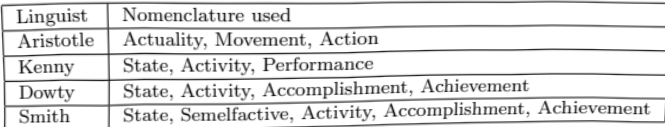

In [11]:
from IPython.display import Image, display
import base64

image_bytes = base64.b64decode(result.images[0].data_base64)
display(Image(data=image_bytes))

In [6]:
with open(pdf_path.with_suffix(".md"), "w", encoding="utf-8") as f:
    f.write(text)

In [2]:
# .load() downloads (or rehydrates from SeaweedFS) then runs agent-substrate's
# PDFLoader — no separate parsing library involved.
docs = await downloader.load(FILE_NAME, DATASET)
print(f"{len(docs)} pages extracted")

62 pages extracted


In [8]:
text = ''
for doc in docs:
    text += doc.to_text()

with open(f"{FILE_NAME}.txt", "w") as f:
    f.write(text)
from IPython.display import display, Markdown
display(Markdown(text))

Detecting and Extracting Events from Text
Documents
JUGAL KALITA, University of Colorado, Colorado Springs
Events of various kinds are mentioned and discussed in text documents, whether they are books,
news articles, blogs or microblog feeds. The paper starts by giving an overview of how events
are treated in linguistics and philosophy. We follow this discussion by surveying how events and
associated information are handled in computationally. In particular, we look at how textual
documents can be mined to extract events and ancillary information. These days, it is mostly
through the application of various machine learning techniques. We also discuss applications of
event detection and extraction systems, particularly in summarization, in the medical domain
and in the context of Twitter posts. We end the paper with a discussion of challenges and future
directions.
Categories and Subject Descriptors: ... [ ...]: ...
General Terms: ...
Additional Key Words and Phrases: Information Retrieval, Event Detection
1. INTRODUCTION
Among the several senses that The Oxford English Dictionary1, the most venerable
dictionary of English, provides for the word event, are the following.
1a the (actual or contemplated) fact of anything happening; the occurrence of.
2a anything that happens, or is contemplated as happening; an incident, occurrence.
2d (In modern use, chieﬂy restricted to) occurrences of some importance .
Although an event may refer to anything that happens, we are usually interested
in occurrences that are of some importance. We want to extract such events from
textual documents. In order to extract important events or events of a speciﬁc
type, it is likely that we have to identify all events in a document to start with.
Consider the ﬁrst paragraphs of the article on the Battle of Fredericksburg in the
English Wikipedia, accessed on May 5, 2012. We have highlighted the “events” in
the paragraph.
The Battle of Fredericksburg was fought December 11–15, 1862, in and
around Fredericksburg, Virginia, between General Robert E. Lee’s Con-
1http://www/oed.com
Jugal Kalita is a professor in the Department of Computer Science, University of Colorado, Col-
orado Springs, CO 80918 USA .
Permission to make digital/hard copy of all or part of this material without fee for personal
or classroom use provided that the copies are not made or distributed for proﬁt or commercial
advantage, the ACM copyright/server notice, the title of the publication, and its date appear, and
notice is given that copying is by permission of the ACM, Inc. To copy otherwise, to republish,
to post on servers, or to redistribute to lists requires prior speciﬁc permission and/or a fee.
c© 2022 ACM 1529-3785/2022/0700-0001 $5.00
ACM T ransactions, V ol. V, No. N, March 2022, Pages 1–62.
arXiv:1601.04012v1  [cs.CL]  15 Jan 20162 · ...
federate Army of Northern Virginia and the Union Army of the Po-
tomac, commanded by Maj. Gen. Ambrose E. Burnside. The Union
army’s futile frontal assaults on December 13 againstentrenched Con-
federate defenders on the heights behind the city is remembered as one
of the most one-sided battles of the American Civil War, with Union
casualties more than twice as heavy as those suﬀered by the Confed-
erates.
The paragraph contains two fairly long sentences with several “events”, men-
tioned using the following words: fought, commanded, assaults, entrenched, remem-
bered, casualties and suﬀered. Some of these “events” are described in terms of verbs
whereas the others are in terms of nouns. Here fought, commanded, assaults, bat-
tles deﬁnitely seem to be “events” that have durations or are durative. Entrenched
seems to talk about a state, whereas it is possible that suﬀered talks about some-
thing punctual (i.e., takes a moment or point of time) or can be durative (i.e., takes
a longer period of time) as well. The act of remembering by an individual is usually
considered to happen momentarily, i.e., forgotten things come back to mind at an
instant of time. But, in this paragraph it is given in passive voice and hence, it is
unclear who the actor is, possibly a lot diﬀerent people at diﬀerent points of time.
Thus, depending on who is asked, the “events” picked out may be slightly dif-
ferent, but the essence is that there are several events mentioned in the paragraph
and the objective in event extraction is to extract as many of them as possible in
an automated fashion. For example, someone may not pick out remembered as an
event that took place. Some others may not want to say thatentrenched is an event.
In addition, if one is asked to pick an important event, responses may vary from
person to person. Finally, if one is asked to summarize the paragraph, depending
on the person asked the summary may vary. A summary prepared by the author
of this article is given below.
The Battle of Fredericksburg, fought December 11-12, 1862, was one of
the most one-sided battles of the American Civil War, with heavy Union
casualties.
Obviously, there are many other possibilities for summarization. However, the idea
is that identiﬁcation of events and their participants may play a signiﬁcant role in
summarizing a document.
This paper discusses the extraction of events and their attributes from unstruc-
tured English text. It is an survey of research in extracting event descriptions from
textual documents. In addition, we discuss how the idea of event extraction can
be used in application domains such as summarization of a document. We also
discuss application of event extraction in the biomedical domain and in the context
of Twitter messages.
The rest of the paper is organized in the following manner. Section 2 provides a
description of research in linguistics and philosophy. The author believes that such
a background, at least at a basic level, is necessary to understand and develop the
approaches and algorithms for automatic computational detection and extraction
of events and their participants from textual documents. Section 4 discusses ap-
proaches used in extracting events from textual documents. Most approaches these
ACM Transactions, Vol. V, No. N, March 2022.... · 3
days use machine learning techniques.
2. EVENTS IN LINGUISTICS AND PHILOSOPHY
Real world events are things that take place or happen. In this section, we present
an overview of how real events are represented in terms of language. In particular,
we discuss classiﬁcation of events and features necessary for such classiﬁcation.
We follow this by presenting the preferred way among philosophers to represent
events in terms of logic. We bring this section to an end by presenting some of the
structures ascribed to events by linguists or philosophers working at an abstract
level.
The reason for the inclusion of this section in the paper is to set the context
for the discussions in the following sections on the practical task of extracting
events. Practical systems do not usually follow linguistic niceties although they
draw inspiration from linguistics or philosophy.
2.1 Classifying Events
There have been many attempts at classifying linguistic events. Below, we brieﬂy
discuss a few. The primary focus when linguists discuss events is on the verb present
in a sentence. Nouns, adjectives and other elements present in a sentence provide
arguments for the verb.
Aristotle (as presented in [Barnes et al. 1984]) classiﬁed verbs that denote some-
thing happening into three classes: actuality, movement and action. An actuality
represents the existence of a thing or things; this is called state by others (e.g.,
[Rosen 1999]). An examples of actuality can be seen in the sentence Jon is ill . A
movement is an incomplete process or something that takes time but doesn’t have
an inherent end. An example of movement is seen in the sentence Jon is running .
An action is something that takes time and has an inherent end. An example of an
action is present in the sentence Jon is building a house . In other words, Aristotle
distinguished between states and events and then events.
[Kenny 2003] lists verbs that belong to the three Aristotelian classes and develops
membership criteria for the classes. Kenny renamed the classes as states, activi-
ties (actions without inherent end) and performances (actions with inherent ends).
Kenny’s membership criteria are based on semantic entailments about whether the
event can be considered to have taken place when it is still in progress. For example,
during any point when we say Jon is running , we can consider that the activity of
running has taken place. In other words Jon is running entails Jon has run . Thus,
run is an activity. In contrast, when we say Joh is taking the ﬁnal , we cannot say
that Jon has taken the ﬁnal. In other words, the ﬁrst does not entail the second.
Thus, the main diﬀerence between an activity and a performance is what is called
delimitation. A delimited event has a natural end.
[Vendler 1967] developed a 4-way classiﬁcation scheme for linguistic events and
[Dowty 1979] developed a set of criteria for membership in the classes. The classes
enumerated by Dowty are: states, activities, achievements and accomplishments.
The deﬁnitions are given below.
—Activities: Events that take place over a certain period of time, but do not
necessarily have a ﬁxed termination point. Examples; Jon walked for an hour ,
ACM Transactions, Vol. V, No. N, March 2022.4 · ...
Linguist Nomenclature used
Aristotle Actuality, Movement, Action
Kenny State, Activity, Performance
Dowty State, Activity, Accomplishment, Achievement
Smith State, Semelfactive, Activity, Accomplishment, Achievement
Table I. Nomenclatures used by linguists to classify events
and Jon is driving the car .
—Accomplishments: Events that happen over a certain period of time and then
end. Examples: Jon built a house in a month , and Jon is taking the ﬁnal .
—Achievements: These are events that occur instantaneously and lack continuous
tenses. Examples: Jon ﬁnished the ﬁnal in 45 minutes and The vase broke .
—States: These are non-actions that hold for a certain period of time, but lack
continuous tenses. Examples: Jon knows the answer and Jon likes Mary .
[Smith 1997] adopts the same classiﬁcation as Vendler and Dowty, but divides
achievements into two classes. The ﬁrst one is still called achievements, but the
second one is called semelfactives. In this new scheme, achievements are instanta-
neous (that is, the beginning of the event is the same as its end) culminating events,
but semelfactives are events with no duration that result in no change of state. An
example of a semelfactive is: Jon knocked on the door .
Table I presents the nomenclatures introduced by various linguists in one place.
There are many variations of the schemes given here, although we do not discuss
them in this paper.
In the early work on event classiﬁcation, Aristotle, Vendler and others assume
that what needs to be classiﬁed is the verb. However, many have concluded that
it is impossible to classify a verb into a speciﬁc class. It is more appropriate to
say that a clause containing an event has a class, and the classiﬁcation of such a
clause depends not only upon the verb, but also on other material present in the
clause [Rosen 1996; Dowty 1979; 1991; Ritter and Rosen 1996]. In other words,
the classiﬁcation must be compositional or must depend on various features of the
clause, not exclusively verb-based. There is also substantial evidence that sentence
material other than the verb can change the overall event type. For example,
addition of a direct object can change an activity to an accomplishment [Rosen
1999], as in the following examples.
—Bill ran for ﬁve minutes/*in ﬁve minutes : activity
—Bill ran the mile *for 5 minutes/in 5 minutes : accomplishment
2.2 Parameters of Event Classes
Many authors in linguistics have delved deeper into the nature of event classes and
have tried to come up with features or characteristics that can be used to identify
whether something (verb or a clause) belongs to a particular event class or not.
These features or characteristics are necessary to describe the structure of events
in a theoretical sense. Description of event structure usually refers to the actual
words used (lexical features or characteristics) and also the structure of clause or
ACM Transactions, Vol. V, No. N, March 2022.... · 5
sentence (syntactic features or characteristics). Identiﬁcation of such features may
be described as ﬁnding parameters of event types orparameterization of event types.
A lot of the work on parameterization of event types/classes use the classes
espoused by Vendler. These include [Verkuyl 1996; Carlson 1981; Moens 1987;
Hoeksema 1983; Mourelatos 1978; Ter Meulen 1983; 1997] and others. We will only
brieﬂy touch upon such work in this paper. Our objective is to impress upon the
reader that identiﬁcation of features of event classes is considered an important
task by linguists.
For example, [Verkuyl 1996] describes Vendler’s classes with two binary features
or parameters: continuousness: whether an event has duration, and boundedness:
whether an event has a (natural) terminal point or endpoint. Using these two
features, the four Vendler classes can be parameterized as follows.
state : -bounded, -continuous
activity : -bounded, +continuous
achievement : +bounded, -continuous
accomplishment : +bounded, +continuous
[Hoeksema 1983; Mourelatos 1978] introduce the notion of countability while
discussing event classes. This is similar to the mass-count opposition in nouns.
Terminating events can be counted, but non-terminating processes cannot. Hoek-
sema introduces two binary features: count and duration to obtain Vendler’s classes
as seen below. The feature duration refers to whether the event takes place over
time.
state : -count, -duration
activity : -count, +duration
achievement : +count, -duration
accomplishment : +count, +duration
[Moens 1987] reﬁnes Vendler’s classes by adding a class much like Smith’s semelfac-
tives [Smith 1997]. He suggests that, in addition to states, there are four event types:
culmination, culminated process, point, and process. He uses two binary features
or parameters: consequence identifying termination or culmination, and atomic or
non-atomic (which Moens called extended). Atomic is also called momentous or
pointed. Moen’s classiﬁcation is given below, along with the features and examples.
culmination : +consequence, +atomic (examples: recognize, win the race)
culminated process : +consequence, -atomic (examples: build a house )
point : -consequence, +atomic (example: hiccup, tap, wink)
process : -consequence, -atomic (example: run, swim, play the piano )
state : (examples: understand, love, resemble)
Moens also claims that culminated process is an event class whose members are
made up of smaller atomic units. In particular, a culminated process is a process
with a consequent state. This insight that events can be decomposed into sub-events
was used later by others working on the lexical analysis of events e.g., [Pustejovsky
ACM Transactions, Vol. V, No. N, March 2022.6 · ...
Linguist Event features identiﬁed
Verkuyl bounded, continuous
Hoeksema count, duration
Moens consequence, atomic
Table II. Features used by linguists to classify events
1991b; 1991a]. Others such as [van Voorst 1988; Grimshaw 1990; Tenny 1994] have
claimed that arguments of verbs are related to sub-events.
We summarize the various features that linguists have used to classify events in
Table II. Of course, we do not discuss many other proposals for features in this brief
discussion. Classiﬁcation of events and their parameterization of verbs or predicates
(or clauses) are only the ﬁrst steps in developing a deeper linguistic understanding
of events. In particular, in order to understand the linguistic representation of
events, linguists need to go beyond classiﬁcation schemes.
2.3 Events in Logical Representation of Semantics
Mathematical logic is used to represent the semantics of language. In particular,
we use logic to represent the meaning of single sentences. Early work on events,
e.g., Panini (as discussed by [Parsons 1990] and [Hamilton et al. 1961]) stated
that language encodes two kinds of information– actions and non-actions. Verbs
represent actions and nouns represent non-actions or things.
[Davidson 2001] proposes that one needs an event variablee to represent events in
mathematical logic. This variable e is used to represent relations represented by the
event denoted by the verb and other constituents in the sentence, such as modiﬁers.
Davidson claims that logically speaking, events are like things in that they can be
represented by a variable and this variable can be modiﬁed and quantiﬁed. A
question that arises is: how many arguments should an event predicate (in logic)
take [Kenny 2003]? Just like nominal modiﬁers modify nouns, event modiﬁers can
modify event predicates. An event predicate can take any number of modiﬁers
just like noun (nominal) modiﬁers. Examples of event modiﬁers are: time, place,
manner and instrument. Davidson proposed that an event predicate may take one
or more required arguments (is this true?) and any number of adjuncts or optional
modiﬁers. Consider the following examples from [Davidson 2001]. The English
sentence and the corresponding logical representation or logical form is given for
each example.
a. John buttered the toast.
∃e buttered(J ones, the toast, e)
b. John buttered the toast slowly.
∃e buttered(J ones, the toast, e)∧ slowly(e)
c. John buttered the toast slowly, in the bathroom.
∃e buttered(J ones, the toast, e)∧ slowly(e)∧ in the bathroom(e)
d. John buttered the toast slowly, in the bathroom, with a knife.
∃e buttered(J ones, the toast, e)∧slowly(e)∧in the bathroom(e)∧with a knif e(e)
e. John buttered the toast slowly, in the bathroom, with a knife, at midnight.
∃e buttered(J ones, the toast, e)∧slowly(e)∧in the bathroom(e)∧with a knif e(e)∧
ACM Transactions, Vol. V, No. N, March 2022.... · 7
at midnight(e)
Thus we can see that Davidson’s approach places the event variable e in the main
predicate of a clause and distributes it among the modiﬁers of the clause in logical
representation. In writing the meaning in Davidsonian logic, the author creates
predicates such as the toast and in the bathroom, just for illustration, without
going into details.
Davidsonian representation allows events to be represented in logic (logical se-
mantics) without requiring verbs to have multiple arities, i.e., without taking diﬀer-
ent arguments in diﬀerent situations. Because the event is represented as a variable,
the event variable e can be included in the representation of logical meaning of each
modiﬁer or adjunct. Another beneﬁt is that using Davidson’s representation, one
can analyze events represented syntactically as nouns (nominals) or verbs [Parsons
1990]. For example, one can refer to an event using the verb to burn or the noun a
burn. Parsons also observes that using a variable to represent an event allows quan-
tiﬁcation over events the same way quantiﬁcation applies to things. The following
examples are from [Parsons 1990].
a. In every burning, oxygen is consumed .
∀e burning (e)→∃ e′(consuming(e′)∧ object(e, oxygen)∧ in(e, e′)
b. Agatha burned the wood.
∃e burning (e)∧ subject(e, Agatha)∧ object(e, wood)
c. Oxygen was consumed.
∃e′ consuming(e′)∧ object(e′, oxygen)
We do not go into details of containment of events as expressed byin in the ﬁrst ex-
ample above, and also the representation of passives as in the third example above.
In these three examples, the author uses predicates such as object and subject which
represent more ﬁne-grained relationship with the main predicate (corresponding to
the verb usually) than the examples earlier. Extending this work, [Parsons 1990;
Higginbotham 1985; Vlach 1981] have demonstrated that using Davidson’s e vari-
able allows one to express tense dependency between perception verbs and their
inﬁnitival compliments in a natural way.
[Parsons 1990] extends Davidson’s approach to logical representation by adding
an extra term corresponding to the event type of the predicate. He distinguishes be-
tween two types of eventualities: eventualities that culminate called Cul containing
achievements and accomplishments, and those that do not, called Hold containing
states and activities.
a. John buttered the toast .
∃e buttering (e)∧ agent(e, J ones)∧ theme(e, toast)∧ (∃t (t < now∧ Cul(e, t))
b. Mary knows Fred.
∃e knowing (e)∧ experiencer(e, M ary)∧ theme(e, F red)∧ Hold(e, now))
In the logical representation in these examples, the author uses predicates such
as theme, agent and experiencer which are usually are called cases in linguistics
[Fillmore 1977]. In addition, the author uses a variable t to express time. now is a
special indexical variable. We do not give detailed discussions of these ﬁne points
here.
ACM Transactions, Vol. V, No. N, March 2022.8 · ...
[Hobbs 1985] also proposes a logical form based on Davidson’s approach. The
main motivation behind Hobb’s approach is to be able to produce satisfactory
semantic representation when an event is expressed as a noun, or when we want
to express the meaning of tenses, modalities, and adverbial modiﬁers. He also
explains how so-called opaque adverbials like almost in the sentence, John is almost
a man. can be represented by the Davidsonian approach, which Hobbs extends.
He also shows how the ambiguity between de re and de dicto meanings of sentences
[Quine 1956] that discuss beliefs can be explained by his approach to logical form
representation of sentences. The representation by Hobbs is quite similar to other
such representations based on Davidson, although there are some ﬁne points of
diﬀerences, that we do not discuss here. From a practical point of view, several
research eﬀorts in computational linguistics have adopted Hobb’s logical form, and
one such recent approach is by [Rudinger and Van Durme 2014] who attempt to
map Stanford dependency parses [De Marneﬀe et al. 2006] into Hobbsian logical
form, and discover that sometimes it is possible to do so, but in other cases the
mapping requires semantic information that is not present in such dependencies
indentiﬁed by the Stanford parser.
2.4 Event structure
Early eﬀorts at identiﬁcation of event structure in linguistics was usually limited
to explaining essential grammatical phenomena. However, others later proposed
complex structures that go beyond simple structures such as Davidson’s approach
of representing an event by a single logical variable and its components by additional
predicates. Understanding the structure of an event entails (i) understanding the
argument structure of the word (or, phrase) used to express the event in surface
form, (ii) understanding the components in the conceptual or semantic description
of an event, and (iii) understanding the relation or mapping between syntactic
realization of an event and its conceptual components. In fact, analysis of argument
structure includes all three steps and requires ﬁnding the relation between meaning
of a verb (or a clause) and the syntactic realization of arguments. [Grimshaw 1990;
Williams 1981] introduce argument structure as a distinct level of representation in
linguistics. Other prominent representations proposed include f-structures [Bresnan
1982], linear event structures [van Voorst 1988], lexical conceptual structures (LCS)
[Jackendoﬀ 1985; Rappaport and Levin 1988] and two related structures: event
structures and qualia structures for arguments [Pustejovsky 1991a].
There are two sides to event structure: syntactic and semantic. When specifying
event structure, at the semantic level, the description must be richer than semantic
role descriptions [Gruber 1965; Fillmore 1968]. [Levin 1985] argues that named roles
or thematic roles are too coarse-grained to provide useful semantic interpretation
of a sentence. It is also necessary to capture semantic distinctions in a much more
ﬁne-grained manner compared to prior theories of [Katz and Fodor 1963; Wilks
1975; Quillian 1968]. ***A sentence or two on these theories*** By this time it
was clear that sophisticated approaches to specifying event structure must build
upon the rich taxonomy of verb classes [Levin 1985] and descriptive vocabulary
work [Talmy 1985] and [Jackendoﬀ 1985].
ACM Transactions, Vol. V, No. N, March 2022.... · 9
2.4.1 Lexicalization Patterns by Talmy. [Talmy 1985] discusses the systematic
relations in language between meaning and surface expression. In particular, Talmy
focuses on verbs and in particular, verbs that describe motion or location. He
sketches a “motion” event in order to explore issues in lexicalization. The basic
motion event consists of one object called ﬁgure moving or located with respect to
another object called the referent or the ground. The motion event has additional
components such as path and motion, manner and cause. Talmy gives examples of
cases where the verb at once can express, in addition to the action or motion, one
or more of ﬁgure, path, manner or cause. If a sematic component such as manner
or cause is expressed directly by the verb, it is called conﬂation of manner (or
cause) into the verb. Some verbs incorporate aspect, which represents the “pattern
of distribution of at ion though time.” In some languages, verbs can incorporate
personation as well. Personation is a speciﬁcation of the person involved, e.g., self
or non-self. Some verbs incorporate what is called valence, where in conceptualizing
an event that involves several diﬀerent entities in distinct roles, a verb is able to
direct greater attention to some one of these entities that to the others, or perhaps
adopt a speciﬁc perspective. Sometimes, semantic components are not incorporated
into the verb, but are expressed through what Talmy calls satellites. A satellite
is an immediate constituent of the verb root other than inﬂections, auxiliaries or
nominal arguments.
Talmy enumerates 35 diﬀerent semantic components. In addition to the six listed
above, these include main purpose, result, polarity, aspect, personation, temporal
and spatial setting, gender, valence, etc. Talmy also isolates surface elements within
a verb complex such as the root verb, inﬂections, appositions, subordinate clauses
and satellites. He then examines which semantic elements are expressed by which
surface elements. He ﬁnds that the relationship is mostly not one-to-one. A com-
bination of semantic elements may be expressed by a single surface element, or a
single semantic element by a combination of surface elements. In a similar manner,
semantic elements of diﬀerent types can be expressed by the same type of surface
elements or by several diﬀerent ones.
Talmy’s work does not enumerate lexical entries for speciﬁc verbs, but provides
detailed discussion on semantic facets of meanings of a verb. The main thrust of
Talmy’s work is to demonstrate that semantic elements and surface elements relate
to each other in speciﬁc patterns, both typological and universal. In work prior
to Talmy’s, most work has treated language’s lexical elements as atomic givens,
without involving semantic components that comprise them. These studies treated
the properties that such whole forms can manifest, in particular, word order, gram-
matical relations and case roles. Talmy’s cross-linguistic study determines semantic
components’ surface presence, site (their host constituent or grammatical relation)
and combination within a site. In addition, Talmy’s tracing of surface occurrence
patterns extends beyond treating single semantic component at a time to treating
a concurrent set of components.
Lexical semantics must strive to represent at least some of the various seman-
tic components that Talmy enumerates. In addition, it must incorporate ways of
mapping from syntax to semantics or vice versa. In a very simple system, a set of
detailed rules may be able to enumerate the mappings from syntax to semantics
ACM Transactions, Vol. V, No. N, March 2022.10 · ...
and vice versa. In a complex modern system, it is necessary that a machine learn-
ing technique will automatically acquire the mappings. This usually requires a lot
of labeled examples for a machine learning program to learn such mappings. We
discuss some such as eﬀorts later in the paper.
2.4.2 Jackendoﬀ’s Lexical Conceptual Structure.
2.4.3 Generative Lexicon by Pustejovsky. Consider the following illustrative ex-
amples.
a) Mary walked.
b) Mary walked to the store.
c) Mary walked for 30 minutes.
Sentence a) describes a process, which is an activity of of indeﬁnite length, i.e., the
sentence does not say how long the activity of walking took. Although b) does not
give an explicit time duration for the walking event, it depicts an accomplishment
and provides a logical culmination to the duration of the event of walking because
the event is over when Mary reached the store. Sentence c) talks about a bounded
process in which, the event of walking terminating although it does not provide an
explicit termination point, but provides a bound to the time extent of the activity
in terms of a duration adverbial. This example motivates the observation that
the use of prepositional phrases or duration adverbials can change the (aspectual)
classiﬁcation of an event. To explain such phenomena better, it is beneﬁcial to have
more complex event structures or lexical analysis of event words. [van Voorst 1988]
hypothesizes that the direct object plays a role in delimitation of an event, i.e.,
whether it has a culmination or not. [Pustejovsky 1991b; 1991a] builds upon such
observations and hypothesizes that it is necessary to know the how an event can be
broken down into sub-events. He provides the following reasons for sub-eventual
analysis.
—Sub-eventual analysis of predicates allows verbal decomposition leading to more
complex lexical semantics.
—Scope of adverbial modiﬁcation, for some adverbials, can be explained better
using event sub-structures.
—Semantic arguments of items within a complex event structure can be mapped
onto argument structures better.
Pustejovsky describes a generative lexicon in the sense that meanings are described
in terms of a limited number of so-called generative devices or primitives by drawing
upon Aristotle’s species of opposition [Lloyd 1968]. For example, to express the
meaning of the word closed as in The door is closed, The door closed or John closed
the door, one needs the concept of opposition between closed and not-closed. This
essential opposition in the meaning of a lexical item is described by Pustejovsky
in terms of what is called the qualia structure of the lexical item. Thus, there are
three primary components to the event structure proposed by Pustejovsky.
—Event type: The event type of the lexical item is given in terms of the classiﬁcation
schemes discussed earlier.
ACM Transactions, Vol. V, No. N, March 2022.... · 11
—Rules for event composition : Since an event may be expressed by more than a
single verb, the meanings of several lexical items may have to be composed to
obtain a description. For example, how does PP attachment change the meaning
of the central event in context?
—Mapping rules from event structure to argument structure : Pustejovsky describes
a number of rules or principles for such mapping. These rules describe how how
semantic participants are realized syntactically.
Pustejovsky provides lexical meaning in terms of four separate structures.
—Argument structure: The behavior of a word as a function, with its arity. This
provides the predicate argument structure for a word, which speciﬁes how it maps
to syntax.
—Event structure: It identiﬁes a speciﬁc event type for a word or a phrase, following
[Vendler 1967].
—Qualia structure: It provides the essential attributes of an object that need to be
expressed lexically.
—Inheritance structure: It speciﬁes how the word is globally related to other con-
cepts in the lexicon.
In summary, Pustejovsky endows complexity to lexical entries for verbs as well
as non-verbs so that semantic weight does not fall on verbs alone in the lexicon and
when composing the meaning of a sentence from its constituents. Pustejovsky’s
approach also reduces the number of lexical entries necessary for individual verbs
because the lexical entries become more general. Pustejovosky focuses on creating
more muscular compositional semantics rather than decomposing a verb’s meaning
into a speciﬁed number of primitives.
2.5 Semantic Arguments and Syntactic Positions
Frequently, speciﬁc semantic arguments of a verb (also called thematic arguments)
appear in characteristic syntactic positions. This has led to theories or proposals
regarding mapping between the two. These theories state that speciﬁc semantic
arguments belong in speciﬁc syntactic positions and that there is 1-1 relationship
between semantic argument and (initial2) syntactic position. Such proposals or the-
ories include the Universal Alignment Hypothesis [Perlmutter 1978] and Uniformity
of Theta Assignment Hypothesis [Baker 1988]. These are supposed to be universal
in that they applied across languages and across verbs. For example, agents appear
in subject positions across languages and verbs. This mapping is thus universal.
However, other mappings are not so universal. For example, the theme can appear
in object, subject or indirect object position; and the experiencer can appear in
subject or object position.
A theory that explains lexicon-to-syntax mapping also needs to explain the ex-
istence of argument alterations. In other words, it should explain the possibility
that the same semantic role can appear in diﬀerent syntactic positions for the same
verb. Usually, linguists classify verbs into a number of semantic classes (diﬀerent
2The syntactic or surface position of a constituent may change under certain circumstances, e.g.,
when one formulates a question from a canonical or declarative sentence.
ACM Transactions, Vol. V, No. N, March 2022.12 · ...
(verb :orth "abandon" :subc ((np-pp :pval ("to")) (np)))
(noun :oath "abandon" :features ((countable :pval ("with"))))
(verb :orth "abstain" :subc ((intrans) (pp :pval ("from")) (p-in-sc :pval ("from"))))
(verb :oath "accept" :subc ((np) (that-s) (np-as-np)))
(verb :orth promote :subc ( (np-pp :pval (to for into from)) (np-pp-pp
:pval (for to into from)) (possing)(np)(np-as-np)(np-tobe)))
Fig. 1. Sample Comlex verb entries
from the ones we talked about earlier) and for each class, a set of mapping relations
and a set of argument alterations are speciﬁed [Levin 1993; Levin and Hovav 1995;
Pinker 1989]. However, other researchers claim that such semantic classiﬁcation is
diﬃcult to obtain because semantically similar verbs may behave diﬀerently across
languages [Rosen 1984], a given verb in a language may have multiple syntactic
realizations [Rosen 1984; 1996], and semantically similar verbs may allow several
syntactic realizations [Rosen 1996].
3. LEXICAL RESOURCES FOR ACTION OR EVENT REPRESENTATION
The discussions on lexical representation of verbs so far have been based on eﬀorts
where a small number of examples were studied intently by linguists before making
the various proposals. Starting the 1980s but more so in the 1990s, when computer
scientists started to focus more on analysis of large text corpora, it became evident
to some that the lexical analysis of pure linguists can be extended by knowledge
gathered from such corpora. This led to development of the Comlex lexicon [Grish-
man et al. 1994], WordNet [Miller 1995; Fellbaum 2010], VerbNet [Schuler 2005],
FrameNet [Fillmore and Baker 2001a; 2001b; Fillmore et al. 2003; Fillmore 2006]
and other resources. Some of these may have started without an automatic analy-
sis of corpora, but soon corpora were used to reﬁne and enhance the initial lexical
resources. Comlex was a substantial resource whose creators spent a lot of eﬀort
in enumerating subcategorization features. WordNet is a large lexical resource or
ontology, which encompasses words from all categories. WordNet includes verbs,
but is not verb-speciﬁc. VerbNet, of course, is focussed on verbs alone. FrameNet
is also focussed on verbs. Both VerbNet and FrameNet attempt to represent all
verbs, not only those which are used to represent “events”. However, the term
event itself is not clearly deﬁned and most anything that is described by a verb can
be considered an event in some context or another.
3.1 Comlex and Nomlex Lexicons
Comlex was created at New York University as a computational lexicon provid-
ing detailed syntactic information on approximately 38,000 words [Grishman et al.
1994]. Of course, not all of these were verbs or words that describe actions. The
feature set Comlex provided were more detailed than commerically available dic-
tionaries at the time such as the Oxford Advanced Learner’s Dictionary (OALD)
[Hornby 1980] and Longman’s Dictionary of Contemporary Englisch (LDOCE) [Pro
1981]. The initial word list was derived from OALD. The lexicon used a Lisp-like
notation for dictionary entries. We see some sample entries for verbs in Comlex in
Figure 1.
ACM Transactions, Vol. V, No. N, March 2022.... · 13
(vp-frame s :cs ((s 2 :that-comp optional))
:gs (:subject 1 :comp 2)
:ex "they thought (that) he was always late")
(vp-frame to-inf-sc :cs ((vp :2 :mood to-infinitive :subject 1))
:features (:control subject)
:gs (:subject 1 :comp 2)
:ex "1 wanted to come.")
(vp-frame to-inf-rs :cs ((vp 2 :mood to-infinitlve :subject 1))
:features (:raising subject)
:gs (:subject () :comp 2)
:ex "they seemed to wilt.")
Fig. 2. Sample Comlex Subcategorization Frames
Comlex paid particular attention to providing detailed subcategorization or com-
plement information for verbs, and nouns and adjectives that take complements.
Comlex was inﬂuenced by prior work on lexicon such as the Brandeis Verb Lexi-
con [Grimshaw and Jackendoﬀ 1981], the ACUILEX project [Sanﬁlippo 1994], the
NYU Lingustic String Project [Sager 1981], the OALD and the LDOCE, and it
incorporated distinctions made in these dictionaries. Comlex had 92 diﬀerent sub-
categorization features for verbs. The features recorded diﬀerences in grammatical
functions as well as constituent structure. In particular, Comlex captured four
diﬀerent types of control: subject control, object control, variable control and ar-
bitrary control. It was also able to express the fact that a verb may have diﬀerent
control features for diﬀerent complement structures, or diﬀerent prepositions within
the complement. Figure 2 shows a few complements used in Comlex. Here :cs is
the constituent structure, :gs is the grammatical structure and :ex are examples.
The authors created a initial lexicon manually and then reﬁned it using a variety
of sources, both commercial and corpus-based.
The Nomlex dictionary of nominalizations was also developed at NYU [Macleod
et al. 1998; Meyers et al. 1998]. It enumerated allowed complements for nomi-
nalizations, and also related nominal complements of the corresponding verbs. A
nominalization is the noun form of a verb. For example, the verb promote is nom-
inalized as nominalization. Similarly, the nominalizations of the verb appoint are
appointment and appointee. Nomlex entries are similar in syntax to Comlex en-
tries. Each Nomlex entry has a :nom-type feature which speciﬁes four types of
nominalizations: action ( appointment, destruction) or state ( knowledge), subject
(teacher), object ( appointee) and verb-part for those nominalizations that incorpo-
rate a verbal particle ( takeover). Meyers et al. [Meyers et al. 1998] presented a
procedure what mapped syntactic and semantic information for an active clause
containing a verb e.g., ( IBM appointed Alice Smith as vice president ) into a set of
patterns for nominalization (IBM’s appointment of Alice Smith as vice president or
Alice Smith’s appointment as vice president). The lexical entry for the verb appoint
used in Comlex is given in Figure 1. The lexical entry in Nomlex for the action
nominalization appointment is given in Figure 3.
ACM Transactions, Vol. V, No. N, March 2022.14 · ...
(nom :orth promotion :verb promote
:nom-type((verb-nom))
:verb-subj ((n-n-mod) (det-poss))
:verb-subc ((nom-np :object ((det-poss)(n-n-mod)(pp-of)))
(nom-np-as-np :object ((det-poss) (pp-of)))
(nom-possing :nom-subc ((p-possing :pval (of))))
(nom-np-pp :object ((det-poss) (n-n-mod) (pp-of))
:pval (into from for to))
(nom-np-pp-pp:object ((det-poss) (n-n-mod) (pp-of))
:pval (for into to) :pval2 (from))))
Fig. 3. The lexical entry for the action nominalization appointment in Nomlex. The entry for the
verb appoint is given in Figure 1
.
3.2 Levin’s Verb Classes
Levin’s verb classes [Levin 1993] explicitly provide the syntax for each class, but do
not provide semantic components. The classes are based on the ability or inability
of a verb to occur in pairs of syntactic frames, with the assumption that syntactic
frames reﬂect the underlying semantics. For example, break verbs and cut verbs
are similar because they can all take part in transitive and middle constructions.
However, only break verbs can occur in simple intransitive constructs. Similarly,
cut verbs can occur in conative constructs and break verbs cannot. The explanation
given is that cut describes a sequence of actions that result in the goal of separating
an object into pieces. It is possible that one can perform the actions without
achieving the result (e.g., John cut at the loaf ). For break, the result is a changed
state where the object becomes separated into pieces. If the result is not achieved,
we cannot say that the action of breaking took place. The examples below are
taken from [Kipper et al. 2000].
—Transitive Construction: (a) John broke the window. , (b) John cut the bread.
—Middle Construction : (a) Glass breaks easily., (b) This loaf cuts easily .
—Intransitive Construction: (a) The window broke. , (b) *The bread cut.
—Conative Construction : (a) * John broke at the window. , (b) John valiantly cut
at the frozen loaf, but his knife was too dull to make a dent in it.
Levin’s original classes had some inconsistencies. For example, many verbs were
listed in multiple classes, some of which had conﬂicting syntactic frames. [Dang
et al. 1998] reﬁned the original classiﬁcation to remove some of these problems
to build a more ﬁne-grained, syntactically and semantically coherent reﬁned class
called intersective Levin classes . Levin’s classes also are focussed mostly on verbs
taking noun (NP) and prepositional phrase (PP) complements, and are weak on
coverage of ADJP, ADVP, sentential complement, etc. VerbNet is built using these
classes.
Organization of verbs into such classes capture generalizations about their prop-
erties. Such classes also help create better NLP systems. Many NLP systems
beneﬁt from using the mapping from surface realization of arguments to predicate-
argument structure that is available in such classes. These classes also capture
abstractions (e.g., syntactic and semantic properties) and as a result, they are
ACM Transactions, Vol. V, No. N, March 2022.... · 15
helpful in many operational contexts where the available corpora are small in size
and thus, it is not possible to extract detailed lexical information about verbs from
such small corpora. The predictive power of the classes can compensate for the
lack of suﬃcient data. Lexical classes have been helpful in tasks such as subcatego-
rization acquisition [Dorr 1997; Prescher et al. 2000; Korhonen and Briscoe 2004],
automatic verb acquisition [Swift 2005], semantic role labeling [Swier and Steven-
son 2004], and word sense disambiguation [Dang 2004]. ***Add newer citations for
application. Look at after 2004 proceedings of NAACL-HLT***
3.3 WordNet
The WordNet project [Miller 1995; Fellbaum 2010] started in the mid-1980s at
Princeton University and over time, has become the most widely used lexical re-
source in English, especially when one needs a lexical resource that can be used
by a program. Wordnet was primarily designed as a semantic network and later
modiﬁed to be a lexical database.
WordNet groups words into synsets (synonym set) and contains relations among
these synsets. A synset contains all the word forms that can refer to a given
concept or sense. For each sense of each word, WordNet also provides a short,
general deﬁnition called its gloss and example usages.
As the name hints, the WordNet can be thought of as a large graph where the
words and synsets are nodes. These nodes linked by edges that represent lexical
and semantic-conceptual links, which we discuss brieﬂy below. Individual words
may also be linked with antonym links. Superclass-subclass relations link entire
synsets. WordNet has entries for verbs, nouns, adjectives and adverbs.
To get a better feel for what WordNet is like, let us look at the online version
of WordNet3 at Priceton University. When we search for the word assault in the
online WordNet, the results come in two parts: noun and verb, because assault can
be either a verb or a noun. The results that show up for verb are given in Figure
4. The verb senses of assault belongs to three synsets. In other words, it has three
senses or can refer to three diﬀerent concepts. Each sunset is composed of several
verbs. The second of these synsets contains one sense of each of the verbs assail,
set on and attack.
A verb may have four types of entries in WordNet: hypernyms, toponyms, entail-
ment and coordinate terms. These terms are deﬁned here. A verb Y is a hypernym
of the verb X if the activity X is a (kind of) Y . For example, to perceive is an
hypernym of to listen. A verb Y is a troponym of the verb X if the activity Y is
doing X in some manner. For example, to lisp is a troponym of to talk. A verb Y is
entailed by X if by doing X one must be doing Y . For example, to sleep is entailed
by to snore . Coordinate terms are those verbs that share a common hypernym,
e.g., to lisp and to yell . If we want to see the direct troponym of the second synset
for the verb meaning of assault, we get what we see in Figure 5.
WordNet has been used in many applications. However, it is most commonly
used as a computational lexicon or “ontology” of English (or, another language)
for word sense disambiguation, a task that assigns the most appropriate senses
(i.e. synsets) to words in speciﬁc contexts. Although WordNet is large and de-
3available at http://wordnetweb.princeton.edu
ACM Transactions, Vol. V, No. N, March 2022.16 · ...
S: (v) assail, assault, set on, attack (attack someone physically or
emotionally)
S: (v) rape, ravish, violate, assault, dishonor, dishonour, outrage (force
(someone) to have sex against their will)
S: (v) attack, round, assail, lash out, snipe, assault (attack in speech or
writing)
Fig. 4. Online WordNet search for the word attack. We show only the verb entries, with gloss for
each entry.
S: (v) bait (attack with dogs or set dogs upon)
S: (v) sic, set (urge to attack someone)
S: (v) bulldog (attack viciously and ferociously)
S: (v) rush (attack suddenly)
S: (v) blindside (attack or hit on or from the side where the
attacked person’s view is obstructed)
S: (v) savage (attack brutally and fiercely)
S: (v) reassail (assail again)
S: (v) jump (make a sudden physical attack on)
S: (v) beset, set upon ((5) )
S: (v) rape, ravish, violate, assault, dishonor, dishonour, outrage
(force (someone) to have sex against their will)
S: (v) desecrate, profane, outrage, violate (violate the sacred
character of a place or language)
S: (v) molest (harass or assault sexually; make indecent advances to)
Fig. 5. The direct toponym set for the second sunset for the verb assault seen in Figure
.
tailed, WordNet does not have information required by NLP applications such
as predicate-argument structure. Although WordNet contains a suﬃciently wide
range of common words, it does not cover special domain vocabulary. It is general
in nature, and therefore diﬃcult to use if specialized vocabulary is needed. Also,
WordNet senses are sometimes overly ﬁne-grained even for human beings and as a
results, some researcher argue that it cannot achieve very high performance in the
tasks where it is applied. Although WordNet is the most widely used online lexical
database in NLP applications, is also limited in its coverage of verbs.
The English WordNet currently contains approximately 117,659 synsets, each
sunset corresponding to a sense of a word. It has 11,529 verbs that belong to
13,767 synsets. It also contains 117,798 nouns that belong to 82,115 synsets. Word-
Nets have been developed or are being developed in a large number of languages
such as Catalan, French, Spanish, Japanese, Chinese, Danish, Korean and Russian.
Notable collaborative eﬀorts include Euro Wordnet [Vossen 2004; 1998a; 1998b],
Asian Wordnet [Charoenporn et al. 2008; Robkop et al. 2010; Sornlertlamvanich
et al. 2009] and Indo WordNet [Sinha et al. 2006] projects. The Indo WordNet
focuses on 18 major languages of India. For example, as of June 2012 4 there are
15,000 synsets in the Assamese WordNet, 24,000 in Bengali, 16,000 in Bodo, 27,000
in Gujarati, and 31,500 in Oriya. WordNets in most other languages are not as
4http://en.wikipedia.org/wiki/IndoWordNet
ACM Transactions, Vol. V, No. N, March 2022.... · 17
sophisticated as the one in English.
3.4 FrameNet
FrameNet [Baker et al. 1998; Fillmore et al. 2003; Ruppenhofer et al. 2006] is
another substantial publicly available lexical resource that has come into existence
independently. It is based on the theory of frame semantics [Fillmore 1976; Petruck
1996; Fillmore and Baker 2001a; 2001b; Fillmore 2006] where a frame corresponds
to a stereo-typical scenario involving an interaction and participants, where partic-
ipants play some kind of roles. The idea is that the meanings of most words are
best understood in context. FrameNet proposes a small context, called a semantic
frame, a description of a type of event, relation or entity and the participants in
it. A frame has a name and this name is used to identify a semantic relation that
groups together the semantic roles.
Although frames mostly correspond to verbs, there are frames that can be iden-
tiﬁed by nouns and adjectives. FrameNet also has a large number of annotated sen-
tences. Each annotated sentence exempliﬁes a possible syntactic realization of the
semantic role associated with a frame for a given target word. FrameNet extracts
syntactic features and corresponding semantic roles from all annotated sentences
in the FrameNet corpus, it builds a large set of rules that encode possible syntactic
realizations of semantic frames.
FrameNet aims to document the range of semantic and syntactic combinatory
possibilities— valences–of each word in each of its senses, through computer-assisted
annotation of example sentences and automatic tabulation of the annotation re-
sults. The FrameNet lexical database, currently contains more than 10,000 lexical
units (deﬁned below), more than 6,000 of which are fully annotated, in nearly 800
hierarchically-related semantic frames, exempliﬁed in more than 170,000 annotated
sentences. See the FrameNet website 5 for the latest statistics. FrameNet has been
used as a semantic role labeling, used in applications such as information extrac-
tion, machine translation, event recognition, sentiment analysis, etc., like the other
publicly available lexical resources.
An example of a frame is Attack. This frame has several frame elements. The
core frame elements are assailant and victim. There are a large number of non-
core frame elements. These include Circumstances, Containing event, Direction,
Duration, Explanation, Frequency, Manner, Means, Place, Purpose, Result, Time,
Weapon, etc. For each of these frame elements there can be seen in one or more
annotated sentences. Here is an example annotated sentence.
[Assailant T he gang] ASSAU LT ED[V ictim him]
[T ime during the drive to Rickmansworth ][P lace in Hertf ordshire ]... (1)
The frame Attack is associated with a large number of associated units. These
include verbs and nouns. Example verbs are ambush, assail, assault, attack, bomb,
bombard, charge, hit, inﬁltrate, invade, raid, storm and strike. Examples of nouns
are airstrike, ambush, assailant, assault, attack, etc. The frame Attack inherits from
5https://framenet.icsi.berkeley.edu/fndrupal/home
ACM Transactions, Vol. V, No. N, March 2022.18 · ...
a frame called Intentionally aﬀect. It is inherited by frames Besieging, Counterat-
tack, Invading and Suicide attack.
FrameNet annotates each frame element (or its representation, actually) in at
least three layers: a frame element name (e.g., Food), a grammatical function (e.g.,
Object) and a phrase type (e.g., NP). Only the frame elements are shown in the
Web-based interface to reduce visual clutter, although all three are available in the
XML downloads. FrameNet has deﬁned more than 1000 semantic frames. These
frames are linked together using frame relations which relate more general frames
to speciﬁc ones. This allows for reasoning about events and intentional actions.
Because frames are semantic, they are often similar across languages. For exam-
ple, frames about buying and selling involve frame elements Buyer, Seller, Goods
and Money in every language. FrameNets have been developed for languages such
as Portuguese, German, Spanish, Chinese, Swedish and Japanese.
At the current time, there are 1159 frames in FrameNet. There are approximately
9.6 frame elements per frame. There are 12595 lexical units of which 5135 are nouns,
4816 are verbs, 2268 are adjectives. There are 12.1 lexical units per frame.
There have been some attempts at extending the coverage of FrameNet. One such
eﬀort is by [Rastogi and Van Durme 2014] who use a new broad-coverage lexical-
semantic resource called PPDB to add lemmas as pontential triggers for a frame
and to automatically rewrite existing example sentences with these new triggers.
PPDB, The Paraphrase Database, is a lexical, phrasal and syntactic paraphrase
database [Ganitkevitch et al. 2013]. They use PPDB’s lexical rules along with a
5-gram Kneser-Ney smoothed language model trained using KenLM [Heaﬁeld et al.
2013] on the raw English sequence of the Annotated Gigaword corpus [Napoles
et al. 2012].
3.5 PropBank
PropBank [Kingsbury and Palmer 2002; 2003; Palmer et al. 2005] is an annotated
corpus of verb propositions and their arguments. PropBank does not annotate
events or states of aﬀairs described using nouns. PropBank-style annotations usu-
ally are closer to the syntactic level, whereas FrameNet-style annotations are more
semantically motivated although, as discussed earlier, FrameNet provides layers of
annotations including syntactic parses. PropBank annotates one million words of
the Wall Street Journal portion of the Penn Treebank [?] with predicate-argument
structure for verbs using semantic role labels for each verb argument.
Although the same tags are used across all verbs (viz., Arg0, Arg1, ··· , Arg5),
these tags have verb-speciﬁc meaning. FrameNet requires that the use of a given
argument label is consistent across diﬀerent uses of a speciﬁc verb, including its
syntactic alternations. Thus, Arg1 (italicized) in “John broke the window broke”
is the same window that is annotated as the Arg1 in “ The window broke” even
though it is the syntactic subject in one case and the syntactic object in another.
FrameNet does not guarantee that an argument label is used consistently across
diﬀerent verbs. For example, Arg2 is used as label to designate the destination of
the verb “bring”, but the extent of the verb “rise”. Generally, the arguments are
simply listed in the order of their prominence for each verb. However, PropBank
tries to use Arg0 as the consistent label for the “prototypical agent” and Arg1 for
the “prototypical patient” as discussed in [Dowty 1991].
ACM Transactions, Vol. V, No. N, March 2022.... · 19
PropBank Role Meaning of PropBank Role VerbNet (Theta) Role
Arg0 attacker Agent
Arg1 entity attacked Theme
Arg2 attribute Predicate
Example: Mr. Baldwin is attacking the greater problem: lack of ringers.
PropBank Role Value
Arg0 Mr. Baldwin
Arg1 the greater problem: lack of ringers
Table III. PropBank entry for attack.01, a sense of the verb attack
purchase buy sell
Arg0: buyer Arg0: buyer Arg0: seller
Arg1: thing bought Arg1: thing bought Arg1: thing sold
Arg2: seller Arg2: seller Arg2: buyer
Arg3: prince paid Arg3: price paid Arg3: price paid
Arg4: benefactive Arg4: benefactive Arg4: benefactive
Table IV. Roles for the verbs purchase, buy and sell in PropBank
PropBank divides words into lexemes using a very coarse-grained sense disam-
biguation scheme. Two senses are considered distinct only if their argument labels
are diﬀerent. In PropBank each word sense is called a frameset. PropBank’s model
of predicate-argument structure diﬀers from dependency parsing. In dependency
parsing, each phrase can be dependent only on one other phrase. But, in Prop-
Bank, a single phrase can be arguments to several predicates. PropBank provides
a lexicon which divides each word into coarse-grained senses or framesets, and pro-
vides examples usages in a variety of contexts. For example, the to make an attack,
criticize strongly sense of the predicate lemma (or, verb) attack is given in Table
III along with an example.
PropBank tries to keep rolesets consistent across related verbs. Thus, for exam-
ple, the buy roleset is similar to the purchase and sell rolesets. See Table IV, taken
from [Kingsbury and Palmer 2002].
One can clearly see that it may be possible to merge such similar framesets
together to obtain something similar to the verb roles in FrameNet’s Commerce
frameset.
Although similar, PropBank diﬀers from FrameNet we have discussed earlier
in several ways. PropBank is a resource focussed on verbs whereas FrameNet is
focussed on frame semantics that generalizes descriptions across similar verbs as
well as nouns and other words (e.g., adjectives) as discussed earlier. PropBank was
created with the idea of serving as training data to be used with machine learning
algorithms for the task of semantic role labeling. It requires all arguments to a verb
to be syntactic constituents in nature. In addition, PropBank diﬀerentiates among
senses of a verb if the senses take diﬀerent sets of arguments. There is a claim that
due to such diﬀerences, semantic role labeling is easier using a corpus annotated
with PropBank type annotation compared to FrameNet type annotation.
ACM Transactions, Vol. V, No. N, March 2022.20 · ...
3.6 VerbNet
VerbNet [Kipper et al. 2000; Kipper et al. 2000; Kipper-Schuler 2005] attempts to
provide a deﬁnitive resource for lexical entries for English verbs. It is compatible
with WordNet, but has lexical entries with explicit syntactic and semantic infor-
mation about verbs, using Levin’s verb classes [Levin 1993]. It uses verb classes
to capture generalizations and for eﬃcient encoding of the lexicon. Its syntactic
frames for verb classes are represented using a ﬁne-grained variation of Lexicalized
Tree Adjoining Grammers [Joshi 1985; Schabes 1990; Dang et al. 1998] augmented
with semantic predicates, allowing for creating compositional meanings for more
complex constituents such as phrases and clauses. VerbNet provides traditional
semantic information such as thematic roles and semantic predicates, with syntac-
tic frames and selectional restrictions. it also allows for extension of verb meaning
through adjunction of particular syntactic phrases.
A verb entry corresponds to a set of classes, corresponding to the diﬀerent senses
of the verb. For each verb sense, there is a verb class as well as speciﬁc selectional
restrictions and semantic characteristics that may not be captured by class mem-
bership. VerbNet also contains references to WordNet synsets. Verb classes capture
generalizations about verb behavior. Each verb class lists the thematic roles that
the predicate-argument structure of its members allows, and provides descriptions
of the syntactic frames corresponding to allowed constructs, with selectional re-
strictions given for each argument in each frame. Verb classes are hierarchically
organized. It required some manual restructuring of Levin’s classes. Each event
E is decomposed into a three-part structure according to [Moens 1987; Moens and
Steedman 1988]. VernNet uses a time function for each predicate specifying whether
the predicate is true during the preparatory, culmination or consequent/result stage
of an event. This structure allows VerbNet to express the semantics of classes of
verbs like Change of State verbs. For example, in the case of the verb break, it
is important to distinguish between the state of the object before the end of the
action and the new state that results afterwards.
Table V is an example of a simpliﬁed VerbNet entry from its website 6. The
original VerbNet was extended using extensions proposed by [Korhonen and Briscoe
2004]. This resulted in the addition of a large number of new classes, and also a
much more comprehensive coverage of English verbs. Table VI provides statistics
of VerbNet’s coverage in its initial version, VerbNet as described in [Kipper et al.
2000; Kipper et al. 2000; Kipper et al. 2008], and its current version as in its oﬃcial
Website.
The absence of any lexicon or resource that provides for accurate and compre-
hensive predicate-argument structure (or semantic role labels) for English verbs has
been long considered a critical element that was needed to produce robust natural
language processors. This was shown clearly by [Han et al. 2000] who evaluated
an English-Korean machine translation system. The authors showed that among
several factors impacting on the low quality of translations, one that was most inﬂu-
ential was the inability to predicate-argument structure. Even with a grammatical
parse of the source sentence ad complete vocabulary coverage, the translation was
6http://verbs.colorado.edu/~mpalmer/projects/verbnet.html
ACM Transactions, Vol. V, No. N, March 2022.... · 21
Class Hit-18.1
Roles and Restrictions: Agent[+int control] Patient[+concrete] Instrument[+concrete]
Members: bang, bash, hit, kick, · · ·
Frames:
Name Example Syntax Semantics
Basic
Transi-
tive
Paula hit
the ball
Agent V
Patient
cause(Agent, E) manner(during(E), directedmotion,
Agent)
!contact(during(E), Agent, Patient) man-
ner(end(E),forceful, Agent)
contact(end(E), Agent, Patient)
Table V. Simpliﬁed VerbNet entry for Hit-18.1 class. Every class is numbered.
VerbNet1.0 VerbNet [Kip-
per et al. 2000]
VerbNet now
First-level classes 191 237 274
Thematic roles 21 23 23
Semantic predicates 64 94 94
Selectional restrictions (semantic) 36 36 ?
Syntactic restrictions 3 55 55
Lemmas 3007 3175 3769
Verb senses 4173 4526 5257
Table VI. VerbNet statistics
frequently bad. This is because, the authors found, that although the parser rec-
ognized the constituents that are verb arguments, it was unable to precisely assign
the arguments to appropriate positions. This led to garbled translations. Sim-
ply preserving the proper argument position labels and not changing other things,
resulted in substantial improvement in acceptable translations. When using one
parser, the improvement was 50%; with a second parser, the improvement was dra-
matic 300%. Thus, the purpose in developing lexical resources such as FrameNet
and PropBank, PropBank especially so, is to provide for training data annotated
with predicate-argument positions with labels. Such data can be used with machine
learning techniques.
3.7 Combining FrameNet, VerbNet and WordNet
There have been attempts to integrate lexical resources to obtain more robust re-
sources with wider coverage. We discuss one such eﬀort here. [Shi and Mihalcea
2005] integrate FrameNet, VerbNet and WordNet discussed earlier into a single
and richer resource with the goal of enabling robust semantic parsing. The reason
for building connections among the three lexical resources is that similar syntactic
patterns often introduce diﬀerent semantic interpretations and similar meanings
can be realized in many diﬀerent ways. The improved resource provides three en-
hancements: (1) It extends the coverage of FrameNet, (2) It augments VerbNet’s
lexicon with frame semantics, and (3) It implements selectional restrictions using
WordNet semantic classes. They use knowledge about words and concepts from
WordNet, information about diﬀerent situations from FrameNet, and verb lexicon
with selectional restrictions from VerbNet. They extract syntactic features and
ACM Transactions, Vol. V, No. N, March 2022.22 · ...
corresponding semantic roles from all annotated sentences in FrameNet to build a
large set of rules that encode the possible syntactic realization of semantic frames.
They identify the VerbNet verb class that corresponds to a FrameNet frame and
this allows them to parse sentences that include verbs not covered by FrameNet.
This they do by exploiting a transitivity relation via VerbNet classes: verbs that
belong to the same Levin classes are likely to share the same FrameNet frame, and
their frame semantics can be analyzed even if not explicitly deﬁned in FrameNet.
They use information from WordNet in several stages in the parsing process. The
argument constraints encoded in VerbNet (e.g., +animate, +concrete) are mapped
to WordNet semantic classes, to provide selectional restrictions for better frame
selection and role labeling in a semantic parser. In addition, the mapping between
WordNet verb entries and FrameNet lexical units allows them to extend the parser
coverage, by assigning common frames to verbs that are related in meaning accord-
ing to the WordNet semantic hierarchies. The authors found that their mapping
algorithms produced 81.25% correct assignment of VerbNet entries with a correct
FrameNet frame. They also were able to map 78.22% VerbNet predicate-argument
structures with some syntactic features and selectional restrictions to the corre-
sponding FrameNet semantic roles.
3.8 OntoNotes and Other Large-scale Annotated Corpora
The OntoNotes project [Hovy et al. 2006; Sameer et al. 2007; Weischedel 2011]
has created an infrastructure for much richer domain independent representation
of shallow meaning for use in natural language processing tasks, including event
detection and extraction, in English, Chinese and Arabic. OntoNotes annotates
documents at several layers: syntax, propositions, word senses including nominal-
izations and eventive noun senses, named entities, ontology linking and co-reference.
It has been designed to be a well-annotated large-scale corpus from which machine
learning programs can learn many diﬀerent aspects of meaning felicitously.
OntoNotes uses Penn TreeBank parses [Marcus et al. 1993], PropBank propo-
sitional structures [Kingsbury and Palmer 2002; 2003; Palmer et al. 2005] on top
of Penn Treebank, and uses the Omega ontology [Philpot et al. 2005] for word
sense disambiguation. As we know, the Penn Treebank is annotated with informa-
tion from which one can extract predicate-argument structures. The developers of
OntoNotes use a parser that recovers these annotations [Gabbard et al. 2006]. The
Penn Treebank also has markers for “empty” categories that represent displaced
constituents. Thus, to create OntoNotes, its developers use another parser [Collins
1999; 2003] to extract function words. They also use a maximum entropy learner
and voted preceptons to recover empty categories. PropBank, as we know, anno-
tates the one-million word Wall Street Journal part of the Penn Treebank with
semantic argument structures for verbs. As we have noted earlier, the creators of
OntoNote and others have discovered that WordNet’s very ﬁne grained sense dis-
tinctions make inter-annotator agreement or good tagging performance diﬃcult. To
achieve better performance, OntoNotes uses a method [Palmer et al. 2004; Palmer
et al. 2007] for sense inventory creation and annotation that includes links between
grouped word senses and the Omega ontology [Philpot et al. 2005]. OntoNotes
represents sense distinctions in a hierarchical structure, like a decision tree, where
coarse-grained distinctions are made at the root and increasingly ﬁne-grained re-
ACM Transactions, Vol. V, No. N, March 2022.... · 23
strictions until reaching WordNet senses at the leaves. Sets of senses under speciﬁc
nodes of the tree are grouped together into single entries, along with syntactic and
semantic criteria for their groupings; these are presented to annotators for improved
annotation agreement, obtaining up to 90% inter-annotator agreement. OntoNote
follows a similar method for annotation of nouns.
To allow access to additional information such as subsumption, property inheri-
tance, predicate frames from other sources, links to instances and so on, OntoNotes
also links to an ontology. This requires decomposing the hierarchical structure of
OntoNotes into subtrees which then can be inserted at the appropriate concep-
tual node in the ontology. OntoNotes represents its terms in the Omega ontology
[Philpot et al. 2005]. Omega 7 has been assembled by merging a variety of sources
such as WordNet, Mikrokosmos [Mahesh et al. 1995], and a few upper ontologies
such as DOLCE [Gangemi et al. 2002], SUMO [Niles and Pease 2001], and Penman
Upper Model [Hovy 2003]. OntoNote also includes and cross-references verb frames
from PropBank, FrameNet, WordNet and Lexical Conceptual Structures [Habash
and Dorr 2002]. OntoNotes also has coreferences. It connects coreferring instances
of speciﬁc referring expressions, primarily NPs that introduce or access a discourse
entity.
For the purpose of our paper, it is important to know that OntoNotes tries
to annotate nouns that carry predicate structure, e.g., those whose structure is
derived from their verbal form. In particular, OntoNotes annotates nominalization
and eventive senses of nouns. OntoNotes applies two strict criteria for identifying
a sense of a noun as a nominalization [Weischedel 2011].
—The noun must relate transparently to a verb, and typically display a nominaliz-
ing morpheme such as-ment (govern/government), -ion (contribute/contribution),
though it allows some zero-derived nouns such askill, the noun derived from kill,
the verb.
—The noun must be able to be used in a clausal noun phrase, with its core verbal
arguments related by semantically empty or very “light” licensers, such as geni-
tive markers (as in The Roman’s destruction of the city.. or with the verb’s usual
particle or prepositional satellites as in John’s longing for fame and fortune...
Just like nominalization senses, OntoNotes has strict deﬁnition ofeventive senses.
They have two deﬁnitional criteria (1) and (2), and a diagnostic test (3), for deter-
mining if a noun sense is eventive.
(1) Activity causing a change of state: A noun sense is eventive when it refers to a
single unbroken activity or process, occurring during a speciﬁc time period, that
eﬀects a change in the world of discourse.
(2) Reference to activity proper: The noun must refer to the actual activity or
process, not merely to the result of the activity or the process.
(3) The noun patterns with eventive predicates in the “have” test: [Belvin 1993]
describes the following heuristic lexico-syntactic diagnostic test to apply to many
nouns. The test has four parts to it as discussed brieﬂy below.
7http://omega.isi.edu
ACM Transactions, Vol. V, No. N, March 2022.24 · ...
—Create a natural sounding sentence using the construction X had <NP> where
<NP> is a noun phrase headed by the noun in question, e.g.,John had a party.
—Check if the sentence can be used in present progressive as in John is having
a party. If the sentence is felicitous, it adds to the noun being inventive. If it
sounds odd, it adds to the evidence that the noun is stative.
—Check if the sentence can be used in a pseudo-cleft construction such as What
John did was have a party. If it is felicitous, the noun is more likely to be
eventive. If not, it is more likely to be stative.
—Check if the sentence suggests iterative or habitual action using the simple
present such as John has a party every Friday . If so, it adds evidence that the
noun is eventive. If the sentence suggests that the situation is taking place at
that very moment that it is uttered, it adds evidence that the noun is stative
as in John has a cold .
In addition to OntoNotes, there have been other eﬀorts at obtaining large-scale
annotated corpora such at the GLARF project [Meyers et al. 2001] that tries to
capture information from various Treebanks and superimpose a predicate argument
structure. The Uniﬁed Linguistic Annotation (ULA) project [Pustejovsky et al.
2005] is a collaborative eﬀort that aims to merge PropBank, NomBank, the Penn
Discourse Treebank [Prasad et al. 2008] and TimeBank [Pustejovsky et al. 2003]
with co-reference information.
4. EXTRACTING EVENTS FROM TEXTUAL DOCUMENTS
Diﬀerent models of events have been used in computational linguistics work geared
toward information extraction.
—A type of model that has been carefully developed over many years, treats an
event as a word that points to a node in a network of predominantly temporal
relations. An example is the so-called TimeML event that is found in documents
that are annotated using the TimeML guidelines [Pustejovsky et al. 2003; Sauri
et al. 2005; Saur´ ı et al. 2005]. In a TimeML annotated corpus, every event is
annotated. Thus, when working with the TimeML model, an extraction program
attempts to extract every event.
—A second type of event model enumerates a few types of events to be extracted
(where the types selected in a somewhat ad-hoc manner) with an event being
described or pointed to by one or more words, along with additional associated
words or phrases that specify arguments of the event. An example is the ACE
model of events [], where an event is a complex structure with arguments which
themselves may be complex structures. Event extraction in the context of MUC-7
(are there other related MUCs?) or ACE, requires one to extract only a limited
number of event types, e.g., movement event type, conﬂict event type, justice
event type (see Section... below). The structure for these event types is provided
by the contest organizers.
—Authors have used very specialized deﬁnitions of events when working with
biomedical text, with details of a few specialized types of biomedical events,
along with the participants.
ACM Transactions, Vol. V, No. N, March 2022.... · 25
—When detecting events in informal very short text such as microblogs of Facebook
posts, researchers have used deﬁnitions that focus on extracting events from many
short documents over which an event may be described.
We discuss TimeML events next followed by events. We discuss biomedical event
extraction in Section 0 ??, and extraction of events from Twitter in Section 0 ??.
4.1 TimeML Events
TimeML is a rich speciﬁcation language for event and temporal expressions in
natural language text. In the TimeML [Pustejovsky et al. 2003; Sauri et al. 2005]
annotation scheme, an event is a general term for situations that happen or occur.
Events can be punctual or momentary, or last for a period of time. Events in
TimeML format may also include predicates describing states or circumstances in
which something holds true. Only those states that participate in an opposition
structure, as discussed in Subsection 2.4.3, are annotated. In general, an event can
be expressed in terms of verbs, nominalizations, adjectives, predicative clauses, or
prepositional phrases. TimeML allows an event, annotated with the EVENT tag,
to be one of seven types: occurrence, state, report, i-action, i-state, aspectual and
perception. The ﬁrst ﬁve are special cases. The last two, Occurrence and State are
used for general cases that do not fall in the special ones.
—Reporting: A reporting event describes an action declaring something, narrating
an event, informing about a situation, and so on. Some verbs which express this
kind of event are say, report, tell, explain, and state. An example sentence with
the verb say is Punongbayan said that the 4,795-foot-high volcano was spewing
gases up to 1,800 degrees.
—I-Action: I stands for intensional8. According to the TimeML annotation guide-
lines, an i-action is a dynamic event that takes an event-denoting argument,
which must be explicitly present in the text. Examples of verbs that are used to
express i-actions include attempt, try, promise and oﬀer. An example sentence
with the verb try is Companies such as Microsoft or a combined worldcom MCI
are trying to monopolize Internet access.
—I-State: I-State stands for intensional state . Like an I-Action, an I-State event
takes an argument that expresses an event. Unlike an I-Action, the I-State class
is used for events which are states. An example sentence that uses the verb
believe is We believe that his words cannot distract the world from the facts of
Iraqi aggression. Other verbs used to express i-states include intend, want, and
think.
—Aspectual: An aspectual predicate takes an event as an argument, and points to
a part of the temporal structure of the event. Such a part may be the beginning,
the middle or the end of an event. Verbs such as begin, ﬁnish and continue
are such aspectual predicates. An example sentence with the verb begin is All
non-essential personnel should begin evacuating the sprawling base.
8According to the English Wikipedia: In logic and mathematics, an intensional deﬁnition gives
the meaning of a term by specifying all the properties required to come to that deﬁnition, that is,
the necessary and suﬃcient conditions for belonging to the set being deﬁned.
ACM Transactions, Vol. V, No. N, March 2022.26 · ...
—Perception: This class includes events involving the physical perception of an-
other event. Such events are typically expressed by verbs such as see, watch,
glimpse, hear, listen, and overhear. An example sentence with the verb see is
Witnesses tell Birmingham police they saw a man running.
—Occurrence: An occurrence is a general event that occurs or happens in the
world. An example of an occurrence is given in the following sentence: The
Defense Ministry said 16 planes have landed so far with protective equipment
against biological and chemical warfare. The occurrence has been highlighted in
bold.
—State: A state describes circumstances in which something obtains or holds true.
An example sentence that shows two states is It is the US economic and political
embargo which has kept Cuba in a box.
TimeML allows one to mark up temporal expressions using the TIMEX3 tag.
Temporal expressions are of three types: (a) Fully speciﬁed temporal expressions
such as June 11, 2013, (b) Underspeciﬁed temporal expressions such as Monday, (c)
Durations such as three days. TimeML uses the SIGNAL tag to annotate sections
of text, usually function words, that indicate how temporal objects are related
to each other. The material marked by SIGNAL may contain diﬀerent types of
linguistic elements: indicators of temporal relations such as prepositions such as on
and during, other temporal connectives such as when, etc. The TIMEX3 and SIGNAL
tags were introduced by [Setzer and Gaizauskas 2000; Setzer 2001].
A major innovation of TimeML is the LINK tags that encode relations between
temporal elements of a document and also help establish ordering between the
events in a document. There are three types of links: TLINK showing temporal
relationships between events, or between an event and a time; SLINK or a subor-
dination link to show context that introduces relations between two events, or an
event and a signal; ALINK or an aspectual link to show relationship between an
aspectual event and its argument event. TLINK allows for 13 temporal relations
introduced by [Allen 1983; 1984]. SLINK is used to express contexts such as use
of modal verbs, negatives, positive and negative evidential relations, factives which
require the event argument to be true, and counterfactives which require the event
argument to be false. ALINK expresses initiation, culmination, termination or con-
tinuation relationships between an event and its argument event. Finally, TimeML
is able to express three types of causal relations: an event causing an event, an
entity causing an event, and the special situation where the use of the discourse
marker and as a signal to introduce a TLINK indicating that one event happened
before another as in He kicked the ball and it rose into the air .
The creators of TimeML have spent signiﬁcant eﬀorts to develop a fairly large
corpus annotated with TimeML tags. This corpus is called the TIMEBANK corpus
[Pustejovsky et al. 2003] and has 300 annotated articles. This corpus has been used
to learn to extract events and temporal relations among events.
4.2 ACE Events
In the ACE model, only “interesting” events are annotated in corpora and thus
extracted by a trained program. ACE annotators specify the event types they want
to be extracted. For example, in one information extraction contest, an ACE 2005
ACM Transactions, Vol. V, No. N, March 2022.... · 27
event9 was of 8 types, each with one has one or more sub-types. The types are
given below. ***Maybe, give some examples***
—Life: Be-born, marry, divorce, injure and die
—Movement: Transport
—Transaction: Transfer-ownership, Transfer money
—Business: Start-organization, Merge-organization, Declare-bankruptcy
—Contact: Meet, Phone-write
—Conﬂict: Attack, demonstrate
—Personnel: Start position, End position, Nominate, Elect, and
—Justice: Arrest-Jail, Release-Parole, Trial-Hearing, Charge-Indict, Sue, Convict,
Sentence, Fine, Execute, Extradite, Acquit, Appeal, Pardon.
Each event also has four categorial attributes. The attributes and their values are
given below.
—Modality: Asserted and Other where Other includes, but is not limited to: Be-
lieved events; Hypothetical events; Commanded and requested events; Threat-
ened, Proposed and Discussed events; and Promised events.
—Polarity: Positive and Negative.
—Genericity: Speciﬁc, Generic
—Tense: Past, Present, Future and Unspeciﬁed.
ACE events have arguments. Each event type has a set of possible argument roles,
which may be ﬁlled by entities, time expressions or other values. Each event type
has a set of possible argument roles. There are a total of 35 role types although no
single event can have all 35 roles. A complete description of which roles go with
which event type can be found in the annotation guidelines for ACE 2005 events 10.
In an ACE event, time is noted if when explicitly given.
Others have deﬁned events or event proﬁles themselves to suit their purpose.
For example, Cybulska and Vossen [Cybulska and Vossen 2010; 2011] describe an
historical information extraction system where they extract event and participant
information from Dutch historical archives. They extract information using what
they call proﬁles. For example, they have developed 402 proﬁles for event extrac-
tion although they use only 22 of them in the reported system. For extraction of
participants, they use 314 proﬁles. They also 43 temporal proﬁles and 23 location
proﬁles to extract temporal and locational information. Proﬁles are created using
semantic and syntactic information as well as information gleaned from Wordnet
[Miller 1995].
4.2.1 Additional Annotation Schemes.
9http://projects.ldc.upenn.edu/ace/docs/English-Events-Guidelines_v5.4.3.pdf
10http://projects.ldc.upenn.edu/ace/docs/English-Events-Guidelines_v5.4.3.pdf
ACM Transactions, Vol. V, No. N, March 2022.28 · ...
4.2.1.1 ERE Annotations. The ACE annotation scheme, discussed earlier, was
developed by NIST in 1999, and the ERE (Entities, Relations and Events) scheme
was deﬁned as a simpler version of ACE [Aguilar et al. 2014]. One of ERE’s goals is
also to make annotating easier and annotations more consistent across annotators.
ERE attempts to achieve these goals by removing the most problematic annotations
in ACE and consolidating others. We will discuss the three types annotations now:
Entities, Relations and Events.
For example, consider Entities. ACE and ERE both have Person, Organization,
Geo-Political Entity and Location as types of entities. ACE has two additional
types, Weapon and Vehicle, which ERE does not have. ERE doesn’t distinguish
between Facility and Location types and merge them into Location. ERE has a
type called Title for titles, honoriﬁcs, roles and professions. ACE has subtypes
for entity mentions, which ERE does not. In addition to subtypes, ACE classiﬁes
entity mentions into classes (e.g., Speciﬁc, Generic and Underspeciﬁed), ERE has
only Speciﬁc. ACE and ERE also have diﬀerences in how extents and heads are
marked, and levels of entity mentions.
The purpose of Relation annotation in both ACE and ERE is to extract a repre-
sentation of the meaning of the text, not necessarily tied to the underlying syntactic
or lexical representation. Both schemes include Physical, Part-Whole, Aﬃliation
and Social relations although the details are a bit diﬀerent. Both tag relations inside
a single sentence and tags only explicit mentions. Nesting of tags is not allowed.
Each relation can have up to two ordered Argument slots. Neither model tags nega-
tive relations. However, ERE annotates only asserted (”real”) events whereas ACE
allows others as well, e.g., Believed Events, Hypothetical Events, Desired Events
and Requested Events. There is no explicit trigger word in ACE, which annotates
the full clause that serves as the trigger for a relation whereas ERE attempts to
minimize the annotated span by allowing for the tagging of an optional trigger word
or phrase. ACE justiﬁes tagging of each Relation by assigning Syntactic Clauses to
them, such as Possessive, PreMod and Coordination. The three types of Relations
inn ERE and ACE have sub-types: Physical, Part-Whole, and Social and Aﬃli-
ation, but ERE collapses ACE types and sub-types to make them more concise,
possibly less speciﬁc. [Aguilar et al. 2014] discuss the similarities and diﬀerences
between ACE and ERE in detail.
Events in both ACE and ERE are deﬁned as ‘speciﬁc occurrences’ involving
‘speciﬁc participants’. Like entities and relations, ERE is less speciﬁc and simpliﬁed
compared to ACE. Both annotation schemes annotate the same event types: Life,
Movement, Transaction, Business, Conﬂict, Contact, Personnel, and Justice.
4.2.1.2 RED Annotations. [Ikuta et al. 2014] use another annotation scheme
called Richer Event Description (RED), synthesizing co-reference [Pradhan et al.
2007; Lee et al. 2012] and THYME-TimeML temporal relations [Styler IV et al.
2014]. [Ikuta et al. 2014] discusses challenges in annotating documents with the
RED schema, in particular cause-eﬀect relations. The usual way to annotate cause-
eﬀect relations is using the counter-factual deﬁnition of causation in philosophy
[Lewis 1973; Halpern and Pearl 2005]:
“X causes Y” means if X had not occurred, Y would not have happened.
ACM Transactions, Vol. V, No. N, March 2022.... · 29
However, [Ikuta et al. 2014] found that this deﬁnition leads to many diﬃcult and
sometimes erroneous annotations, and that’s why while performing RED annota-
tions, they used another deﬁnition [Menzies 1999; 2008] which treats causation as
“a local relation depending on intrinsic properties of the events and what goes on
between then, and nothing else”. In particular, the deﬁnition is
“X causes Y” means Y was inevitable given X.
In fact, in the annotations performed by [Ikuta et al. 2014], they use the new
deﬁnition to make judgements, but use the old deﬁnition as a precondition to the
new one.
4.2.2 TAC-KBP Annotations. The Knowledge Base Population Track (TAC-
BKP) was started by NIST in 2009 to evaluate knowledge bases (KBs) created
from the output of information extraction systems. The primary tasks are a) En-
tity linking–linking extracted entities to entities in knowledge bases, and b) Slot
ﬁlling–adding information to entity proﬁles, information that is missing from the
knowledge base [McNamee et al. 2010]. Wikipedia articles have been used as refer-
ence knowledge bases in evaluating TAC-KBP tasks. For example, given an entity,
the goal is to identify individual nuggets of information using a ﬁxed list of in-
ventory relations and attributes. For example, given a celebrity name, the task is
to identify attributes such as schools attended, occupations, important jobs held,
names of immediate family members, etc., and then insert them into the knowledge
base. Many people compare slot ﬁlling to answering a ﬁxed set of questions, ob-
taining the answers and ﬁlling in the appropriate slots in the knowledge base. Slot
ﬁlling in TAC-KBP diﬀers from extraction in ACE and ERE notations in several
ways such as TAC-KBP seeks out information for named entities only, chieﬂy PERs
and ORGs, TAC-KBP seeks to obtain values for slots and not mentions, and events
are handled as uncorrelated slots, and assessment is like in question-answering.
Our focus on this paper has been on extracting events, and we know that to
extract events properly, we need to explicitly extract event mentions, and also
extract associated attributes such as agents, locations, time of occurrence, duration,
etc. Rather than explicitly modeling events, TAC-KBP does so implicitly as it
captures various relations associated with for example the agent of the event. For
example, given a sentence “Jobs is the founder and CEO of Apple”, TAC-KBP
may pick ”Apple” as the focal entity and identify ”Jobs” as the ﬁller of its founder
slot, and ”Jobs” as the ﬁller of its CEO slot. However, an ACE or ERE annotation
program will ideally pick the event as Founding, with Jobs as an argument (say
the ﬁrst argument or arg1, or the Actor) of the event, and ”Apple” as another
argument, say arg2.
4.3 Extracting Events
Many even extraction systems have been built over the years. A big motivator
for development of event extraction systems seem to be various contests that are
held every few years, although there has been considerable amount of non-contest
related research as well. Although we discuss extraction of events represented by
various formats, the methods are not really diﬀerent from each other. That is why
we discuss TimeML events in more detail and present the others brieﬂy in this
ACM Transactions, Vol. V, No. N, March 2022.30 · ...
section.
4.3.1 Extracting TimeML Events. We describe a few of the approaches that
have been used for extracting TimeML type events. Quite a few papers that at-
tempt to do so have been published [Saur´ ı et al. 2005; Bethard and Martin 2006;
Chambers et al. 2007; Llorens et al. 2010; Grover et al. 2010], and we pick just a
few representative papers.
4.3.1.1 The Evita System. : [Saur´ ı et al. 2005] implemented an event and event
feature extraction system called EVITA and showed that a linguistically motivated
rule-based system, with some help using statistical disambiguation perfumed well
on this task. Evita is claimed to be a unique tool within the TimeML framework in
that it is very general, being not based on any pre-established list of event patterns
and being domain-independent. Evita can also identify, based on linguistic cues,
grammatical information associated with event referring expressions, such as tense,
aspect, polarity and modality, as stated in the TimeML speciﬁcation. Evita does
not directly identify event participants, but can work with named entity taggers to
link arguments to events.
Evita breaks down the event recognition problem to a number of sub-tasks. Evita
preprocesses the input text using the Alembic Workbench POS tagger, lemmatizer
to ﬁnd lexical stems, and chunkier to obtain phrase chunks, verbal, nominal and
adjectival, the three that are commonly used as event referring expressions [ ?]. For
each subtask after pre-processing, it combines linguistic- and statistically-based
knowledge. Linguistic knowledge is used in local and limited contexts such as verb
phrases and to extract morphological information. Statistical knowledge is used
to disambiguate nominal events. The sub-tasks in event recognition in Evita are:
determination of event candidates and then the events, identiﬁcation of grammatical
features of events, additional clustering of event chunks for event detection and
grammatical feature identiﬁcation in some situations.
For event identiﬁcation, Evita looks at the lexical items tagged by the prepro-
cessing step. It uses diﬀerent strategies for identifying events in the three cate-
gories: verbs, nouns and adjectives. For identifying events in a verbal chunk, Evita
performs lexical look-up and limited contextual parsing in order to exclude weak
stative predicates such as be and generics such as verbs with bare plural subjects.
Identifying events expressed by nouns involves a phase of lexical look-up and dis-
ambiguation using WordNet, and by mapping events SemCor and TimeBank 1.2 to
WordNet synsets. Evita consults 25 subtrees from WordNet where all the synsets
denote events. One of these, the largest, is the tree underneath the sunset that
contains the word event. If the result of this lexical look-up is not conclusive (i.e.,
if a nominal occurs as both event and non-event in WordNet), a disambiguation
step is applied, based on rules learned by a Bayesian classiﬁer trained on SemCor.
To identify events from adjectives, Evita uses a conservative approach, where it
tags only those adjectives that were annotated as such in TimeBank 1.2, when such
adjectives occur as the head of a predicative complement.
To identify grammatical features (e.g., tense, aspect, modality, polarity and non-
ﬁnite morphology) of events, Evita uses diﬀerent procedures based on the part of
speech of the event denoting expression. But, in general it involves using morphol-
ACM Transactions, Vol. V, No. N, March 2022.... · 31
ogy, pattern matching, and applying a large number (e.g., 140 such rules for verbal
chunks) simple linguistic rules. However, to identify the eventclass, it performs lex-
ical look-up and word sense disambiguation. Clustering is used to identify chunks
from the preprocessing stage, that contribute information about the same event,
e.g., when some modal auxiliaries and use of copular verbs. Clustering is activated
by speciﬁc triggers such as the presence of a chunk headed by an auxiliary verb or
a copular verb.
Evaluation of Evita was performed by comparing its performance against Time-
Banck 1.2. The reported performance was that Evita had 74.03% precision, 87.31%
recall and an F-measure of 80.12% in event detection. Accuracy (precision?) for
polarity, aspect and modality was over 97% in each case.
4.3.1.2 Bethard and Martin’s approach (2006). : [Bethard and Martin 2006] use
TimeBank-annotated events and identify which words and phrases are events. They
consider event identiﬁcation as a classiﬁcation task that works on word-chunks.
They use the BIO formulation that augments each class label with whether the
word is the Beginning, Inside or Outside of a chunk [Ramshaw and Marcus 1995].
They use a number of features, categorized into various classes, for machine learn-
ing. These include aﬃx features (e.g., three or four characters from the beginning
and end of each word), morphological features (e.g., base form of the word, and
base form of any verb associated with the word if the word is a noun or gerund,
for example), word-class features (e.g., POS tags, which noun or verb cluster a
word belongs to where the clusters are obtained using co-occurrence statistics in
the manner of [Pradhan et al. 2004]), governing features (e.g., governing light verb,
determiner type—cardinal or genitive, for example), and temporal features (e.g.,
a BIO label indicating whether the word is contained inside a TIMEX2 temporal
annotation, a governing temporal preposition like since, till, before, etc.). They
also use negation features and Wordnet hypernyms as features. For classiﬁcation,
they use the TinySVM implementation of SVM by [Kudo and Matsumoto 2001].
They perform experiments with TimeBank documents using a 90% stratiﬁed sam-
pling for training and 10% for testing. They obtained 82% precision and 71% recall,
with an F-measure of 0.759. They did compare their algorithm with an version of
Evita they programmed themselves; this system obtained 0.727 F-measure, and
thus Bethard and Martin’s approached performed about 4% better. When Bethard
and Martin’s system was extended to identifying semantic class of an event, it did
not perform as well, obtaining precision of 67%, recall of 51%, and F-measure of
0.317. However, the system was much better at identifying the classes of verbs
with F-measure of 0.707 compared to ﬁnding classes of nouns with an F-measure
of 0.337 only.
4.3.1.3 Llorens’ et al.’s approach:. TIPSem (Temporal Information Processing
based on Semantic information) is a system that participated in the TemEval-
2 Competition [Verhagen et al. 2010] in 2010, which presented several tasks to
participants, although we are primarily interested in the event extraction task.
TIPSem achieved the best F1 score in all the tasks in TempEval-2 for Spanish, and
for English it obtained the best F1 metric in the task of extracting events, which
required the recognition and classiﬁcation of events as deﬁned by TimeML EVENT
ACM Transactions, Vol. V, No. N, March 2022.32 · ...
tag.
TIPSem learns Conditional Random Field (CRF) models using features for dif-
ferent language analysis levels, although the approach focuses on semantic informa-
tion, primarily semantic roles and semantic networks. Conditional Random Fields
present a popular and eﬃcient machine learning technique for supervised sequence
labeling [Laﬀerty et al. 2001].
The features used for training the CRF models are similar to one used by others
such as Bethard and Martin, although details vary. However, they add semantic
role labels to the mix of features. In particular, they identify roles for each gov-
erning verb. Semantic role labeling [Gildea and Jurafsky 2002; Moreda et al. 2007;
Punyakanok et al. 2004] identiﬁes for each predicate in a sentence, semantic roles
and determine their arguments (agent, patient, etc.) and their adjuncts (locative,
temporal, etc.). The previous two features were combined in TIPSem to capture the
relation between them. The authors think this combination introduces additional
information by distinguishing roles that are dependent on diﬀerent verbs. The
importance of this falls especially on the numbered roles (A0, A1, etc.) meaning
diﬀerent things when depending on diﬀerent verbs.
The test corpus consists of 17K words for English and 10K words for Spanish,
provided by the organizers of TempEval-2. For English, they obtained precision of
0.81, recall of 0.86 and F-measure of 0.83 for recognition with event classiﬁcation
accuracy of 0.79; for Spanish the numbers were 0.90, 0.86, 0.88 for recognition and
0.66 for classiﬁcation accuracy. We provide these numbers although we know that it
is diﬃcult to compare one system with another, for example Bethard and Martin’s
system with TIPSem since the corpora used are diﬀerence.
4.3.1.4 TempEval-3: 2012. As in TempEval-2, TempEval-3 [UzZaman et al.
2012] participants took part in a task where they had to determine the extent of
the events in a text as deﬁned by the TimeML EVENT tag. In addition, systems
may determine the value of the features CLASS, TENSE, ASPECT, POLARITY,
MODALITY and also identify if the event is a main event or not. The main
attribute to annotate is CLASS.
The TempEval-3 dataset was mostly automatically generated, using a temporal
merging system. The half-million token text corpus from English Gigaword2 was
automatically annotated using TIPSem, TIPSem-B [Llorens et al. 2010] and TRIOS
[UzZaman and Allen 2010]. These systems were re-trained on the TimeBank and
AQUAINT corpus, using the TimeML temporal relation set. The outputs of these
three state-of-the-art system were merged using a merging algorithm [UzZaman
et al. 2012]. The dataset used comprised about 500K tokens of “silver” standard
data and about 100K tokens of “gold” standard data for training, compared to the
corpus of roughly 50K tokens corpus used in TempEval 1 and 2.
There were seven participants and all the participants except one used machine
learning approaches. The top performing system was ATT-1 [Jung and Stent 2013]
with precision 81.44, recall 80;67 and F1 of 81.05 for event recognition, and 71.88 for
event classiﬁcation. Close behind was the ATT-2 system [Jung and Stent 2013] with
precision, recall and F-1 of 81.02, 80.81 and 80.92 for event recognition respectively,
and 71.10 for event classiﬁcation. Both systems used MaxEnt classiﬁers with
Obviously, diﬀerent sets of features impact on the performance of event recog-
ACM Transactions, Vol. V, No. N, March 2022.... · 33
nition and classiﬁcation [Adafre and de Rijke 2005; Angeli et al. 2012; Rigo and
Lavelli 2011]. In particular, [ ?] also examined performance based on diﬀerent
sizes of n-grams in a small scale (n=1,3). Inspired by such work, in building the
ATT systems, the creators intended to systematically investigate the performance
of various models and for each task, they trained twelve models exploring these
two dimensions, three of which we submitted for TempEval-3, and of these three
performed among the top ten in TempEval-3 Competition.
The ATT-1 models include lexical, syntactic and semantic features, ATT-2 mod-
els include only lexical and syntactic features, and ATT-3 models include only
lexical features, i.e., words. They experimented with context windows of 0, 1, 3,
and 7 words preceding and following the token to be labeled. For each window
size, they trained ATT-1, ATT-2 and ATT-3 models. The ATT-1 models had 18
basic features per token in the context window for up to 15 tokens, so up to 270
basic feaures for each token to be labeled. The ATT-2 models had 16 basic features
per token in the context window, so up to 240 basic features for each token to
be labeled. The ATT-3 models had just 1 basic feature per token in the context
window, so up to 15 basic features for each token to be labeled.
For event extraction and classiﬁcation, and event feature classiﬁcation, they used
the eﬃcient binary MaxEnt classiﬁer for multi-class classiﬁcation, available in the
machine learning toolkit LLAMA [Haﬀner 2006]. They also used LLAMA’s pre-
processor to build unigram, bigram and trigram extended features from basic fea-
tures.
For event and time expression extraction, they trained BIO classiﬁers. It was
found that the absence of semantic features causes only small changes in F1. The
absence of syntactic features causes F1 to drop slightly (less than 2.5% for all but the
smallest window size), with recall decreasing while precision improves somewhat.
F1 is also impacted minimally by the absence of semantic features, and about 2-5%
by the absence of syntactic features for all but the smallest window size.1
A was surprising that that ATT-3 models that use words only performed well,
especially in terms of precision (precision, recall and F2 of 81.95, 75.57 and 78.63
for event recognition, and 69.55 F1 for event classiﬁcation) . It is also surprising
that the words only models with window sizes of 3 and 7 performed as well as the
models with a window size of 15. These results are promising for “big data text
analytics, where there may not be time to do heavy preprocessing of input text or
to train large models.
4.3.2 Extracting Events Using Other Representations. We have already dis-
cussed several approaches to extraction of events represented by TimeML repre-
sentation. Extracting events that use other representation is not very diﬀerent, but
diﬀerent representations have existed and exist, and therefore we brieﬂy present
some such attempts. Some of these predate the time TimeML became popular. For
example, the various Message Understanding Conferences (MUCs, seven were orga-
nize by DARPA from 1987 to 1997), asked participants to extract a small number
of relations and events. For instance, MUC-7, the last one, called for the extraction
of 3 relations (person-employer, maker-product, and organization-location) and 1
event spacecraft launches.
For example, the MUC-7 and ACE events did not attempt to cover all events,
ACM Transactions, Vol. V, No. N, March 2022.34 · ...
but a limited number of pre-speciﬁed event types or classes that participants need
to detect during a contest period, based on which the contestants submit papers
for publication. The number and the type of arguments covered are also limited
and are pre-speciﬁed before the competitions start.
4.3.2.1 The REES System:. [Aone and Ramos-Santacruz 2000] discuss a rela-
tion and event extraction system covering areas such as political, ﬁnancial, busi-
ness, military, and life-related topics. The system consists of tagging modules, a
co-reference resolution module, and a temple generation module. They store the
events generated in MUC-7[Chinchor and Marsh 1998] format, which is not very
unlike the ACE format.
Events are extracted along with their event participants, e.g., who did what to
whom when and where? For example, for a BUYING event, REES extracts the
buyer, the artifact, the seller, and the time and location of the BUYING event.
REES covers 61 types of events. There are 39 types of relations.
The tagging component consists of three modules: NameTagger, NPTagger and
EventTagger. Each module relies on the same pattern-based extraction engine,
but uses diﬀerent sets of patterns. The NameTagger recognizes names of peo-
ple, organizations, places, and artifacts (only vehicles in the implemented system).
The NPTagger then takes the output of the NameTagger and ﬁrst recognizes non-
recursive Base Noun Phrase (BNP) [Ramshaw and Marcus 1995], and then complex
NPs for only the four main semantic types of NPs, i.e., Person, Organization, Loca-
tion, and Artifact (vehicle, drug and weapon). The EventTagger recognizes events
applying its lexicon-driven, syntactically-based generic patterns.
REES uses a declarative, lexicon-driven approach. This approach requires a
lexicon entry for each event-denoting word, which is generally a verb. The lexicon
entry speciﬁes the syntactic and semantic restrictions on the verb’s arguments.
After the tagging phase, REES sends the output through a rule-based co-reference
resolution module that resolves: deﬁnite noun phrases of Organization, Person,
and Location types, and singular personal pronouns. REES outputs the extracted
information in the form of either MUC-style templates or XML.
One of the challenges of event extraction is to be able to recognize and merge
those event descriptions which refer to the same event. The Template Generation
module uses a set of declarative, customizable rules to merge co- referring events
into a single event.
The system’s recall, precision, and F-Measure scores for the training set (200
texts) and the blind set (208 texts) from about a dozen news sources. On the
so-called training set, the system achieved F-measure of 64.75 for event extraction
and 75.35 for relation extraction. The blind set F-Measure for 31 types of relations
(73.95
4.3.2.2 Ahn’s approach. As seen earlier in Subsection 4.2, the way ACE events
are speciﬁed, they have a lot of details that need to be extracted. [Ahn 2006]
follows several steps to extract events and uses machine learning algorithms at
every step. The steps are pre-processing of text data, identifying anchors, assigning
event types, extracting arguments identifying attributes of events such as modality,
polarity, genericity and tense, and ﬁnally identifyings event co-referents of the same
ACM Transactions, Vol. V, No. N, March 2022.... · 35
individuated event. In other words, Ahn attempts to cover all the steps sequentially,
making the simplifying assumption that they are unrelated to each other.
A single place in a textual document which may be considered the primary place
of reference or discussion about an event is called the event anchor. Ahn treats
ﬁnding the anchor for an event within a document as a word classiﬁcation task ,
using a two-stage classiﬁcation process. He uses a binary classiﬁer to classify a
word as being an event anchor or not. He then classiﬁes those identiﬁed as event
anchors into one of the event classes. Ahn used one classiﬁer for binary classiﬁcation
and then another classiﬁers to classify only the positive instances.
Ahn treats identifying event arguments as a pair classiﬁcation task. Each event
mention is paired with each of the entity, time and value mentions occurring in
the same sentence to form a single classiﬁcation instance. There were 35 role types
in the ACE 2006 task, but no event type allows arguments of all types. Each
event type had its own set of allowable roles. The classiﬁcation experiment run was
a multi-class classiﬁcation where a separate multi-class classiﬁer was used for each
event type. Ahn trains a separate classiﬁer for each attribute. Genericity, modality,
and polarity are each binary classiﬁcation tasks, while tense is a multi-class task.
For event coreference, Ahn follows the approach given in [Florian et al. 2004]. Each
event mention in a document is paired with every other event mention, and a
classiﬁer assigns to each pair of mentions the probability that the paired mentions
corefer. These probabilities are used in a left-to-right entity linking algorithm in
which each mention is compared with all already-established events (i.e., event
mention clusters) to determine whether it should be added to an existing event or
start a new one.
Ahn experimented with various combinations of a maximum entropy classiﬁer
MegaM [Daum´ e III 2004] and a memory-based nearest neighbor classiﬁer called
TIMBL [Daelemans et al. 2004], for the various tasks.
The ACE speciﬁcation provided a way to measure the performance of an event
extraction system. The evaluation called ACE value is obtained by scoring each of
the component tasks individually and then obtaining a normalized summary value.
Overall, using the best learned classiﬁers for the various subtasks, they achieve an
ACE value score of 22.3%, where the maximum score is 100%. The value is low,
but other systems at the time had comparable performance.
4.3.2.3 Naughton 2008:. [Naughton et al. 2008] describe an approach to classify
sentences in a document as specifying one or more events from a certain ACE 2006
class. They classify each sentence in a document as containing an instance of
a certain type or not. Unlike [Ahn 2006], they are not interested in identifying
arguments or any additional processing. Also, unlike Ahn who classiﬁes each word
as possibly being an event anchor for a speciﬁc type of ACE event, Naughton
et al. perform a classiﬁcation of each sentence in a document as being an on-
event sentence or an oﬀ-event sentence. An on-event sentence is a sentence that
contains one or more instances of the target event type. An oﬀ-event sentence is
a sentence that does not contain any instances of the target event type. They use
several approaches to classify a sentence as on-event or oﬀ-event. These include
the following: SVM-based machine learning [Joachims 1998], language modeling
approaches using count smoothing, and a manual approach which looks for Wordnet
ACM Transactions, Vol. V, No. N, March 2022.36 · ...
synonyms or hypernyms of certain trigger words in a sentence.
Naughton et al. found that 1) use of a large number of features to start but then
reduction of these features using information gain, and 2) use of SVM produces the
best results although all versions of SVM (i.e., with all features with no reduction,
just the terms without complex features, or a selection of terms and other features)
all work very well. A “surprising” ﬁnding was that the “manual” trigger-based
classiﬁcation approach worked almost as well as the SVM based approaches.
4.4 Determining Event Coreference
When an event is mentioned in several places within a document, ﬁnding which
references are to the same event is called determining event coreference. These are
co-referents to the event. Determining when two event mentions in text talk about
the same event or co-refer is a diﬃcult problem. As [Hovy et al. 2013] point out
that the events may be actual occurrences or hypothetical events.
4.4.1 Florian’s Approach to Coreference Resolution.[Florian et al. 2004] present
a statistical language-independent framework for identifying and tracking named,
nominal and pronominal references to entities within unrestricted text documents,
and chaining them into groups corresponding to each logical entity present in the
text. The model can use arbitrary feature types, integrating a variety of lexical,
syntactic and semantic features. The mention detection model also uses feature
streams derived from diﬀerent named entity classiﬁers.
For mention detection, the approach used is based on a log-linear Maximum En-
tropy classiﬁer [Berger et al. 1996] and a linear Robust Risk Minimization classiﬁer
[Zhang et al. 2002]. Then they use a MaxEnt model for predicting whether a men-
tion should or should not be linked to an existing entity, and to build entity chains.
Both classiﬁers can integrate arbitrary types of information and are converted into
suitable for sequence classiﬁcation for both tasks.
For entity tracking, the process works from left to right. It starts with an initial
entity consisting of the ﬁrst mention of a document, and the next mention is pro-
cessed by either linking it with one of the existing entities, or starting a new entity.
Atomic features used by the entity linking algorithm include string match, context,
mention count, distance between the two mentions in words and sentences, editing
distance, properties of pronouns such gender, number and reﬂexiveness. The best
combination of features was able to obtain slightly more than 73% F-1 value using
both RRM and MaxEnt algorithms for mention detection.
Entity tracking was evaluated in terms of what is called the ACE value. A gauge
of the performance of an EDT system is the ACE value, a measure developed
especially for this purpose. It estimates the normalized weighted cost of detection
of speciﬁc-only entities in terms of misses, false alarms and substitution errors.
Florian et al. achieved an ACE value of 73.4 out of 100 for the MaxEnt classiﬁer
and 69.7 for the RRM classiﬁer.
[Ahn 2006] follows the approach by [Florian et al. 2004] for entity coreference
determination. He uses a binary classiﬁer to determine if any two event mentions
in the document refer to the same event. Thus, he pairs each event with every other
event, and the classiﬁer assigns each pair a probability that they are the same. The
probability is used with entity linking/matching algorithm to determine event co-
ACM Transactions, Vol. V, No. N, March 2022.... · 37
reference. Event co-referencing requires event mentions to be clustered to event
clusters. Event mentions in a cluster are the same event. The system described
here obtained an ACE value of between 88-91%, where the maximum ACE value
is 100%.
[Ahn 2006] uses the following features for event co-reference determination. Let
the candidate be the earlier event mention and the anaphor be the later mention.
—The anchors for the candidate and the anaphor, the full or original form, and
also in lowercase, and POS tag.
—Type of the candidate event and the anaphor event.
—Depth of candidate anchor word in parse tree.
—Distance between the candidate and anchor, measured in sentences.
—Number, heads, and roles of shared arguments, etc.
4.4.2 Bejan and Harabagiu. Supervised approaches to solving event corefer-
ence use linguistic properties to decide if a pair of event mentions is coreferen-
tial [Humphreys et al. 1997; Bagga and Baldwin 1999; Ahn 2006; Chen and Ji
2009]. These models depend on labeled training data, and annotating a large
corpus with event coreference information requires substantial manual eﬀort. In
addition, since these models make local pairwise decisions, they are unable to cap-
ture a global event distribution at topic or document collection level. [Bejan and
Harabagiu 2010] present how nonparametric Bayesian models can be applied to an
open-domain event coreference task in an unsupervised manner.
The ﬁrst model extends the hierarchical Dirichlet process [Teh et al. 2006] to
take into account additional properties associated with event mentions. The second
model overcomes some of the limitations of the ﬁrst model, and uses the inﬁnite
factorial hidden Markov model [Gael et al. 2009] coupled to the inﬁnite hidden
Markov model [Beal et al. 2001] in order to consider a potentially inﬁnite number
of features associated with observable objects which are event mentions here, per-
form an automatic selection of the most salient features, and capture the structural
dependencies of observable objects or event mentions at the discourse level. Fur-
thermore, both models can work with a potentially inﬁnite number of categorical
outcomes or events in this case.
Two event mentions corefer if they have the same event properties and share the
same event participants. To ﬁnd coreferring event mentions, Bejan and Harabagiu
describe words that may be possible event mentions with lexical features, class fea-
tures such as POS and event classes such [Pustejovsky et al. 2003] as occurrence,
state and action, Wordnet features, semantic features obtained by a semantic parse
[Bejan and Hathaway 2007] and the predicate argument structures encoded in Prop-
Bank annotations [Palmer et al. 2005] as well as semantic annotations encoded in
the FrameNet corpus [Baker et al. 1998].
The ﬁrst model represents each event mention by a ﬁnite number of feature types,
and is also inspired by the Bayesian model proposed by [Haghighi and Klein 2007].
In this model, a Dirichlet process (DP) [Ferguson 1973] is associated with each
document, and each mixture component (i.e., event) is shared across documents
since In the process of generating an event mention, an event index z is ﬁrst sampled
by using a mech- anism that facilitates sampling from a prior for in- ﬁnite mixture
ACM Transactions, Vol. V, No. N, March 2022.38 · ...
models called the Chinese restaurant franchise (CRF) representation, as reported
in [Teh et al. 2006].
The second model they use is called the iHMM-iFHMM model (inﬁnite hidden
Markov model–inﬁnite factorial hidden Markov model). The iFHMM framework
uses the Markov Indian buﬀet process (mIBP) [Gael et al. 2009] in order to represent
each object as a sparse subset of a potentially unbounded set of latent features
[Ghahramani and Griﬃths 2005; Van Gael et al. 2008], Speciﬁcally, the mIBP
deﬁnes a distribution over an unbounded set of binary Markov chains, where each
chain can be associated with a binary latent feature that evolves over time according
to Markov dynamics. The iFHMM allows a ﬂexible representation of the latent
structure by letting the number of parallel Markov chains be learned from data, it
cannot be used where the number of clustering components is inﬁnite. An iHMM
represents a nonparametric extension of the hidden Markov model (HMM) [Rabiner
1989] that allows performing inference on an inﬁnite number of states. To further
increase the representational power for modeling discrete time series data, they
develop a nonparametric extension that combines the best of the two models, and
lets the two parameters M and K be learned from data Each step in the new
iHMM-iFHMM generative process is performed in two phases: (i) the latent feature
variables from the iFHMM framework are sampled using the mIBP mechanism; and
(ii) the features sampled so far, which become observable during this second phase,
are used in an adapted version of the beam sampling algorithm [ ?] to infer the
clustering components (i.e., latent events).
They report results in terms of recall (R), precision (P), and F-score (F) by
employing the mention-based B3 metric [Bagga and Baldwin 1998], the entity-based
CEAF metric [Luo 2005], and the pairwise F1 (PW) metric. Their experiments for
show that both of these models work well when the feature and cluster numbers
are treated as free parameters, and the selection of feature values is performed
automatically.
4.4.3 Hovy et al. [Hovy et al. 2013] argue that events represent complex phe-
nomena and can therefore co-refer fully, being identical, like other researchers have
discussed, or co-refer partially, being quasi-identical or only partially identical. Two
event mentions fully co-refer if their activity, event or state representation is identi-
cal in terms of all features used (e.g., agent, location or time). Two event mentions
are quasi-identical if they partially co-refer, i.e., most features are the same, but
there may be additional details to one or the other.
When two events fully co-refer, Hovy et al. state they may be lexically identical
(i.e., the same senses of the same word, e.g., destroy and destruction), synonymous
words, one mention is a wider reading of the other (e.g., The attack took place
yesterday and The bombing killed four people ), one mention is a paraphrase of the
other with possibly some syntactic diﬀerences (e.g.,He went to Boston and He came
to Boston), and one mention deictically refers to the other (e.g., the party and that
event). Quasi-identity or partial co-reference may arise in two ways: membership
identity or subevent identity. Membership identity occurs when one mention, say
A, is a set of multiple instances of the same type of event, and the other mention,
say B, is one of the individual events in A (e.g., I attended three parties last week.
The ﬁrst one was the best. ). Subevent identity is found when one mention, say A,
ACM Transactions, Vol. V, No. N, March 2022.... · 39
is a stereotypical sequence (or script) of events whereas the other mention, say B, is
one of the actions or events within the script (e.g., The family ate at the restaurant.
The dad paid the waitress at the end. ).
Hovy et al.attempt to build a corpus containing event co-reference links with
high quality annotations, i.e., annotations with high inter-annotator agreement, to
be useful for machine learning. They have created two corpora to assist with a
project on automated deep reading of texts. One corpus is in the domain of violent
events (e..g., bombings, killens and wars), and the other one containing texts about
the lives of famous people. In both of these corpora, they have annotated a limited
number of articles with full and partial co-references.
4.4.4 Delmonte. [Delmonte 2013] claims that performing event co-reference with
high accuracy requires deep understanding of the text and statistically-based meth-
ods, both supervised and unsupervised, do not perform well. He claims that this
is the case because because it is absolutely necessary to identify arguments of an
event reliably before event co-references can be found. Arguments are diﬃcult to
identify because many are implicit and linguistically unexpressed. Successful even
co-reference identiﬁcation needs determination of spatio-temporal anchoring and
locations in time and space are also very often implicit.
The system he builds uses a linguistically based semantic module, which has
a number of diﬀerent submodules which take care of Spatio-Temporal Reasoning,
Discourse Level Anaphora Resolution, and determining Topic Hierarchy. The coref-
erence algorithm works as follows: for each possible referent it check all possible
coreference links, at ﬁrst using only the semantic features, which are: wordform
and lemma identity; then semantic similarity measured on the basis of a number of
similarity criteria which are lexically based. The system searches WordNet synsets
and assign a score according to whether the possible referents are directly contained
in the same synset or not. A diﬀerent score is assigned if their relation can be in-
ferred from the hierarchy. Other computational lexical resources they use include
FrameNet and Frames hierarchy; SumoMilo and its semantic classiﬁcation.
After collecting all possible coreferential relations, the system ﬁlters out those
links that are inconsistent or incompatible. Argument structure and spatiotemporal
relations are computed along with dependence relations; temporal logical relations
as computed using an adaptation of Allen’s algorithm. The system also computes
semantic similarity, where high values are preferred. The paper does not give any
results to support the initial hypothesis, although the ideas are interesting.
4.4.5 Cybulska and Vossen. [Cybulska and Vossen 2015] use granularity in com-
puting event coreference. The intuition is, that an event with a longer duration,
that happens on a bigger area and with multiple particpants (for instance a war
between Russia and Ukraine) might be related to but will probably not fully corefer
with a lower level event of shorter duration and with single participants involved
(e.g. A Russian soldier has shot dead a Ukrainian naval oﬃcer ).
Coreference between mentions of two events is determined by computing compat-
ibility of contents of event attributes. The attributes used are event trigger, time,
location, human and non-human participant slots [Cybulska and Vossen 2014a].
Granularity size is mentioned in terms of durations of event actions [Gusev et al.
ACM Transactions, Vol. V, No. N, March 2022.40 · ...
2011] and granularity levels of event participants, time and locations. Granularity
is given in terms of partonomic relations or through the part-of relation, between
entities and events, using the taxonomy of meronymic relations by [Winston et al.
1987]. Granularity levels of the human participant slot are contained within Win-
stons et al. Member-Collection relations. The temporal granularity levels make
part of Winstons Portion-Mass relationships and locational levels are in line with
Place-Area relations in Winstons taxonomy.
Cybulska and Vossen experimented with a decision-tree supervised pairwise bi-
nary classiﬁer to determine coreference of pairs of event mentions. They also ran
experiments with a linear SVM and a multinomial Naive Bayes classiﬁer but the
decision-tree classiﬁer outperformed both of them.
For the experiments, Cybulska and Vossen use the ECB+ dataset [Cybulska and
Vossen 2014b]. The ECB+ corpus contains a new corpus component, consisting
of 502 texts, describing diﬀerent instances of event types. They provide results in
terms of several metrics: recall, precision and F-score, MUC [Vilain et al. 1995],
B3 [Bagga and Baldwin 1998], mention-based CEAF [Luo 2005], BLANC [Recasens
and Hovy 2011], and CoNLL F1 [Pradhan et al. 2011], and ﬁnd that the introduction
of the granularity concept into similarity computation improves results for every
metric.
5. BIOMEDICAL EVENT EXTRACTION
Researchers are interested in extracting information from the huge amount of
biomedical literature published on a regular basis. Of course, one aspect of in-
formation extraction is event extraction, the focus of this paper. In the biomedical
context, an event extraction system tries to extract details of bimolecular interac-
tions among biomedical entities such as proteins and genes, and the processes they
take part in, as described in terms of textual documents. Manually annotated cor-
pora are used to train machine learning techniques and evaluate event extraction
techniques.
There have been several workshops on biomedical natural language processing.
We focus on the BioNLP Shared Tasks in recent years that had competitions on
event extraction. There have been three BioNLP Shared Task competitions so far:
2009, 2011, and 2013. The BioNLP 2009 Shared Task [Kim et al. 2009] was based
on the GENIA corpus [Kim et al. 2003] which contains PubMed 11 abstracts of
articles on transcription factors in human blood cells. There was a second BioNLP
Shared Task competition organized in 2011 to measure the advances in approaches
and associated results [Kim et al. 2011]. The third BioNLP ST was held in 2013.
We discuss some notable systems from BioNLP ST 2011 and 2013.
Before the BioNLP Shared Tasks, event extraction in the biomedical domain
usually classiﬁed each pair of named entities (usually protein names) co-occurring
in the text as interacting or not. BioNLP Shared Tasks extended such an approach
by adding relations such as direction, type and nesting. An event deﬁnes the type
of interaction, such as phosphorylation, and is usually marked in the text with
a trigger word (e.g., phosphorylates) describing the interaction. This word forms
the core of the event description. A directed event has roles that have inherent
11http://www.ncbi.nlm.nih.gov/pubmed
ACM Transactions, Vol. V, No. N, March 2022.... · 41
directionality such as cause or theme, the agent or target of the biological process.
In addition, events can act as arguments of other events, creating complex nested
structures. For example, in the sentence Stat3 phosphorylation is regulated by Vav ,
a phosphorylation-event is the argument of the regulation-event.
The BioNLP Shared Tasks provide task deﬁnitions, benchmark data and eval-
uations, and participants compete by developing systems to perform the speciﬁed
tasks. The theme of BioNLP-ST 2011 was a generalization of the 2009 contest,
generalized in three ways: text types, event types, and subject domains. The 2011
event-related tasks were arranged in four tracks: GENIA task (GE) [Kim et al.
2011], Epigenetics and Post-translational Modiﬁcations (EPI) [Ohta et al. 2011],
Infectious Diseases (ID)[Pyysalo et al. 2011], and the Bacteria Track [Bossy et al.
2011; Jourde et al. 2011].
Of the four event-related shared tasks in BioNLP 2011, the ﬁrst three were related
to event extraction. The Genia task was focused on the domain of transcription
factors in human blood cell. Trascription is a complex but just the ﬁrst step in the
process in which the instructions contained in the DNA in the nucleus of a cell are
used to produce proteins that control most life processes. Transcription factors are
proteins that control the transcription process. The EPI task was focused on events
related to epigenetics, dealing with protein and DNA modiﬁcations, with 14 new
event types, including major protein modiﬁcation types and their reverse reactions.
Epigenesis refers to the development of a plant or animal from a seed, spore or egg,
through a sequence of steps in which cells diﬀerentiate and organs form. The EPI
task was designed toward pathway extraction and curation of domain databases
[Wu et al. 2003; Ongenaert et al. 2008]. A biological pathway refers to a sequence
of actions among molecules in a cell that leads to a certain product or a change in
the cell. The ID task was focused on extraction of events relevant to biomolecular
mechanisms of infectious diseases from full length publications. Tasks other than
ID focused on abstracts only.
In this paper, we discuss the systems and approaches for only the 2011 GE Task.
This is because several of the winning systems for the GE Task did well in the other
two relevant tasks as well. The Genia Task is described in Table VII. The table
shows for each event type, the primary and secondary arguments to be extracted.
For example, a phosphorylation event is primarily extracted with the protein to be
phosphorylated, which is the addition of a phosphate group to a protein or other
organic molecule. As secondary information, the speciﬁc site to be phosphorylated
may be extracted. From a computational viewpoint, the event types represent
diﬀerent levels of complexity. When only primary arguments are considered, the
ﬁrst ﬁve event types in Table VII are classiﬁed as simple events , requiring only
unary arguments. The binding and regulation types are more complex. Binding
requires the detection of an arbitrary number of arguments, and Regulation requires
detection of recursive event structure.
Consider the sentence In this study we hypothesized that the phosphorylation of
TRAF2 inhibits binding to the CD40 cytoplasmic domain. Here there are two
protein (entity) names: TRAF2 and CD40. The word phosphorylation refers to an
event; this string is a trigger word. Thus, the goal of the GE task was to identify
a structure like the ones in Tables VIII and IX . In the tables, Ti represents a
ACM Transactions, Vol. V, No. N, March 2022.42 · ...
Event Type Primary Argument Secondary Argument
Gene expression Theme (Protein)
Transcription Theme (Protein)
Protein catabolism Theme (Protein)
Phosphorylation Theme (Protein) Site(Entity)
Localization Theme (Protein) AllLoc(entity), ToLoc (Entity)
Binding Theme (Protein)+ Site(Entity)+
Regulation Theme (Protein/Event), Cause
(Protein/Event)
Site(Entity), CSite(Entity)
Positive regulation Theme (Protein/Event), Cause
(Protein/Event)
Site(Entity), CSite(Entity)
Negative regulation Theme (Protein/Event), Cause
(Protein/Event)
Site(Entity), CSite(Entity)
Table VII. Event types and their arguments in the Genia event task. The type of arguments,
primary and secondary, to be extracted from the text, are also given.
Table VIII. Structure of an Event in BioNLP 2011 Contest, corresponding to Task 1 (GE)
Table IX. Structure of an Event in BioNLP 2011 Contest, corresponding to Task 2 (EPI)
trigger word, and Ei represents an event associated with the corresponding trigger
word. There are three events, E1 is the phosphorylation event, E2 is the binding
event and E3 is the negative regulation event. For each trigger word, we see the
starting and ending character positions in the entire string. For each event, we see
the participants in it. The second task identiﬁes an additional site argument.
Table X shows the best results for various tasks in the BioNLP 2011 contests.
[Kim et al. 2011] note an improvement of 10% over the basic GE task, in 2011
(Task GEa), compared to 2009. The results of the GE tasks show that automatic
extraction of simple events–those with unary arguments, e.g., gene expression, lo-
ACM Transactions, Vol. V, No. N, March 2022.... · 43
Task Evaluation Results
BioNLP ST 2000 46.73 / 58.48/ 51.95
Miwa et al. (2010b) 48.62 / 58.96 / 53.29
LLL 2005 (LLL) 53.00 / 55.60 / 54.30
GE abstracts (GEa) 50.00 / 67.53 / 57.46
GE full texts (GEf) 47.84 / 59.76 / 53.14
GE PHOSPHORYLATION (GEp) 79.26 / 86.99 / 82.95
GE LOCALIZATION (GEl) 37.88 / 77.42 / 50.87
EPI full task (EPIf) 52.69 / 53.98 / 53..3
EPI core task (EPIc) 68.51 / 69.20 / 68.86
EPI PHOSPHORYLATION (EPIp) 86.15 / 74.67 / 80.00
ID full task (IDf) 48.03 / 65.97 / 55.59
ID core task (IDc) 50.62 / 66.06 / 57.32
Table X. Best results for various sub-tasks in BioNLP ST 2011. Recall/precision/F-score %
calization and phosphorylation—can be achieved at about 70% in F-score, but the
extraction of complex events, e.g., binding and regulation is very challenging, with
only 40% performance level. The GE and ID results show that generalization to full
papers is possible, with just a small loss in performance. The results of phospho-
rylation events in GE and EP are similar (GEp vs. EPIp), which leads [Kim et al.
2011] to conclude that removal of the GE domain speciﬁcity does not reduce event
extraction performance by much. EPIc results indicate that there are challenges to
extracting similar event types that need to be overcome; EPIf results indicate that
there are diﬃcult challenges in extracting additional arguments. The complexity
of the ID task is similar to that of the GE task; this shows up in the ﬁnal results,
also indicating that it is possible to generalize to new subject domains and new
argument (entity) types.
Below, we provide a brief description of some of the approaches to biomedical
event extraction from the BioNLP 2011 contests.
5.1 Technical Methods Used in BioNLP Shared Tasks 2011
The team that won the GE Task was the FAUST system [Riedel et al. 2011], followed
by the UMass system [Riedel and McCallum 2011], then the UTurku system [Bj¨ orne
and Salakoski 2011]. The performance of these three systems on the various tasks
is given in Table XI. In addition, we have the Stanford system in the table because
it performed fairly well on the tasks.
The UMass system [Riedel and McCallum 2011] looks at a sentence as having an
event structure, and then projects it onto a labeled graph. See Figure 6 for a target
event structure and the projected graph for the sentence fragment Phosphorylation
of TRAF2 inhibits binding to CD40 . The system searches for a structure that
connects the event and its participating entities and imposes certain constraints
on the structure. Thus, the UMass system treats the search for such a structure
as an optimization problem. To formulate this optimization problem, the system
represents the structure in terms of a set of binary variables, inspired by the work
of [Riedel et al. 2009; Bj¨ orne et al. 2009]. These binary variables are based on the
projection of the events to the labeled graph. An example of a binary variable is
ai,l.r to indicate that between positions i and l in the sentence, there is an edge
ACM Transactions, Vol. V, No. N, March 2022.44 · ...
Team Simple Event Binding Regulation All
FAUST
W 68.5/80.3/73.9 44.2/53.7/48.5 38.0/54.9/44.9 49.4/64.8/56.0
A 66.2/81.0/72.9 45.5/58.1/51.1 39.4/58.2/47.0 50.0/67.5/57.5
F 75.6/78.2/76.9 41.1/44.7/ 42.8 35.0/48.2/40.6 47.9/58.5/52.7
UMass
W 67.0/ 81.4/ 73.5 43.0/ 56.4/ 48.8 37.5/52.7/43.8 48.5/64.1/55.2
A 64.2/80.7/71.5 43.5/60.9/50.8 38.8/55.1/45.5 48.7/65.9/56.1
F 75.6/83.1/79.2 41.7/47.6/44.4 34.7/47.5/40.1 47.8/59.8/53.1
UTurku
W 68.2/76.5/72.1 42.8/43.6/43.3 38.7/47.6/42.7 49.6/57.7/53.3
A 65.0/76.7/70.4 45.2/50.0/47.5 40.4/49.0/44.3 50.1/59.5/54.4
F 78.2/75.8/77.0 37.5/31.8/34.4 35.0/44.5/39.2 48.3/53.4/50.7
Stanford
W 65.8/76.8/70.9 39.9/9.9/44/3 27.6/48.8/35.2 42.4/61.1/50.0
A 62.1/77.6/69.3 42.4/54.2/47.6 28.3/50.0/36.1 42.6/62.7/50.7
F 75.6/75.0/75.3 34.0/40.2/36.9 26.0/46.1/33.3 41.9/57.4/48.4
Table XI. Evaluation results (recall / precision / f-score for Task 1 in Whole data set (W),
Abstracts only (A) and Full papers only (F)
Fig. 6. (a) Sentence with target event structure, (b) Projection to labeled graph. ***Redraw the
image***
labeled r from a set of possible edge labels R. Another such binary variable is ti,p,q
that indicates that at position i, there is a binding event with arguments p and q.
Given a number of such variables, it is possible to write an objective function to
optimize in order to obtain events and entity bindings. The system decomposes
the biomedical event extraction task into three sub-tasks: (a) event triggers and
outgoing edges on arguments, (b) event triggers and incoming edges on arguments,
and (c) and protein-protein bindings. The system obtains an objective function
for each of the sub-tasks. It solves the three optimization problems one by one
in a loop, till no changes take place, or up to a certain number of iterations. The
approach uses optimizing by dual decomposition [Komodakis et al. 2007; Rush et al.
2010] since the dual of the original optimization problem is solved.
The Stanford system [McClosky et al. 2011] exploits the observation that event
ACM Transactions, Vol. V, No. N, March 2022.... · 45
structures bear a close relation to dependency graphs [Jurafsky and Martin 2000,
Chapter 12]. They cast bimolecular events in terms of these structures which
are pseudo-syntactic in nature. They claim that standard parsing tools such as
maximum-spanning tree parsers and parse rerankers can be applied to perform event
extraction with minimum domain speciﬁc training. They use an oﬀ-the-shelf de-
pendency parser, MSTParser [McDonald et al. 2005; McDonald and Pereira 2006],
but extend it with event-speciﬁc features. Their approach requires conversion to
and from dependency trees, at the beginning and and at the end. The features in
the MSTParser are quite local (i.e., able to examine a portion of each event at a
time); the decoding necessary can be performed globally, allowing the dependency
parser some trade-oﬀs. Event parsing is performed using three modules: 1) anchor
detection to identify and label event anchors, 2) event parsing to form candidate
event structures by linking entries and event anchors, and 3) event reranking to
select the best candidate event structure. First, they parse the sentences with a
reranking parser [Charniak and Johnson 2005] with the biomedical parsing model
from [McClosky 2010], using the set of Stanford dependencies [De Marneﬀe and
Manning 2008]. After the parsing, they perform anchor detection using a technique
inspired by techniques for named entity recogntion to label each token with an
event type or none, using a logistic regression classiﬁer. The classiﬁer uses features
inspired by [Bj¨ orne et al. 2009]. They change a parameter to obtain high recall to
overgenerate event anchors. Multiword event anchors are reduced to their syntactic
head. The event anchors and the included entities become a “reduced” sentence,
input to the event parser. Thus, the event parser gets words that are believed to
directly take part in the events. This stage uses the MSTParser with additional
event parsing features. The dependency trees are decoded and converted back to
event structures. Finally, for event reranking, the system gets n best list of event
structures from each decoder in the previous step of event parsing. The reranker
uses global features of an event structure to restore and output the highest scor-
ing structure. The reranking approach is based on parse reranking [Ratnaparkhi
1999], but is based on features of event structures instead of syntactic constituency
structure. They use the cvlm estimator [Charniak and Johnson 2005] when learn-
ing weights for the reranking model. Since the reranker can work with outputs of
multiple decoders, they use it as an ensemble technique as in [Johnson and Ural
2010].
The FAUST system [Riedel et al. 2011] shows that using a straightforward model
combination strategy with two competitive systems, the UMass system [Riedel and
McCallum 2011] and the Stanford system [McClosky et al. 2011] just described,
can produce a new system with substantially high accuracy. The new system uses
the framework of stacking [Alpaydin 2010, Chapter 17]. The new system does it
by including the predictions of the Stanford system into the UMass system, simply
as a feature. Using this simple model of stacking, the FAUST system was able to
obtain ﬁrst place in three tasks out of four where it participated.
The Turku Event Extraction System [Bj¨ orne and Salakoski 2011; Bj¨ orne et al.
2012] can be easily adapted to diﬀerent event schemes, following the theme of event
generalization in BioNLP 2011. The system took part in eight tasks in BioNLP
2011 and demonstrated the best performance in four of them. The Turku system
ACM Transactions, Vol. V, No. N, March 2022.46 · ...
divides event extraction into three main steps: i) Perform named entity recognition
in the sentence, ii) Predict argument relations between entities, and iii) Finally,
separate entity/argument sets into individual events. The Turku system uses a
graph notation with trigger and protein/gene entities as nodes and relations (e.g.,
theme) as edges. In particular, an event in the graph representation is a trigger
node along with its outgoing edges. The steps are shown in Figure 7. The Turku
system uses Support Vector Machines [Vapnik 1995; Tsochantaridis et al. 2006]
at various stages to perform each of the sub-tasks. To use an SVM classiﬁer, one
needs to convert text into features understood by the classiﬁer. The Turku system
performs a number of analyses on the sentences, to obtain features, which are
mostly binary. The features are categorized into token features (e.g., Porter-stem
[Porter 1980], Penn Treebank part-of-speech tags [Marcus et al. 1993], character bi-
and tri-grams, presence of punctuation on numeric characters), sentence features
(e.g., the number of named entities in the sentence), dependency chains (up to
a depth of three, to deﬁne the context of the words), dependency with n-grams
(joining a token with two ﬂanking dependencies as well as each dependency with
two ﬂanking tokens), trigger features (e.g., the trigger word a gene or a protein)
and external features (e.g., Wordnet hypernyms, the presence of a word in a list of
key terms). Applicable combinations of these features are then used by the three
steps in event detection: trigger detection, edge detection and unmerging. Trigger
words are detected by classifying each token as negative or as one of the positive
trigger classes using SVMs. Sometimes several triggers overlap, in which case a
merged class (e.g. phosphorylation–regulation) is used. After trigger prediction,
triggers of merged classes are split into their component classes. Edge detection
is used to predict event arguments or triggerless events and relations, all of which
are deﬁned as edges in the graph representation. The edge detector deﬁnes one
example per direction for each pair of entities in the sentence, and uses the SVM
classiﬁer to classify the examples as negatives or as belonging to one of the positive
classes. When edges are predicted between these nodes, the result is a merged
graph where overlapping events are merged into a single node and its set of outgoing
edges. To produce the ﬁnal events, these merged nodes need to be pulled apart into
valid trigger and argument combinations. Unmerging is also performed using the
SVM classiﬁer. Speculation and negation are detected independently, with binary
classiﬁcation of trigger nodes using SVMs. The features used are mostly the same
as for trigger detection, with the addition of a list of speculation-related words.
6. EXTRACTING EVENTS FROM SOCIALLY GENERATED DOCUMENTS
With the explosive expansion of the Internet during the past twenty years, the
volume of socially generated text has skyrocketed. Socially generated text includes
blogs and microblogs. For example, Twitter 12, started in 2006, has become a social
phenomenon. It allows individuals with accounts to post short messages that are up
to 140 characters long. Currently, more than 340 million tweets are sent out every
day13. While a majority of posts are conversational or not particularly meaningful,
12http://www.twitter.com
13http://blog.twitter.com/2012/03/twitter-turns-six.htm
ACM Transactions, Vol. V, No. N, March 2022.... · 47
Fig. 7. Turku BioNLP Pipeline
ACM Transactions, Vol. V, No. N, March 2022.48 · ...
about 3.6% of the posts concern topics of mainstream news 14. Twitter has been
credited with providing the most current news about many important events before
traditional media, such as the attacks in Mumbai in November 2008. Twitter also
played a prominent role in the unfolding of the troubles in Iran in 2009 subsequent
to a disputed election, and the so-called Twitter Revolutions15 in Tunisia and Egypt
in 2010-11.
Most early work on event extraction of information from documents found on the
Internet has focussed on news articles [Chambers and Jurafsky 2011; Doddington
et al. 2004; Gabrilovich et al. 2004]. However, as noted earlier, social networking
sites such as Twitter and Facebook have become important complimentary sources
of such information. Individual tweets, like SMS messages, are usually short and
self-contained and therefore are not composed of complex discourse structures as
is the case with texts containing narratives. However, extracting structured rep-
resentation of events from short or informal texts is also challenging because most
tweets are about mundane things, without any news value and of interest only to
the immediate social network. Individual tweets are also very terse, without much
context or content. In addition, since Twitter users can talk about any topic, it is
not clear a priori what event types may be appropriate for extraction.
The architecture of the system called TwiCal for event extraction [Ritter et al.
2012] from Twitter messages is given in Figure 8. Given a stream of raw tweets,
TwiCal extract events with associated named entities and times of occurrence. First
the tweets are POS tagged using a tagger [Ritter et al. 2012], especially trained with
Twitter data. Then named entities are recognized [Ritter et al. 2011] using a rec-
ognizer trained with Twitter data as well. After this, phrases that mention events
(or, event triggers or event phrases or just events) are extracted using supervised
learning. [Ritter et al. 2012] annotated 1,000 tweets with event phrases, following
guidelines for annotation of EVENT tags in Timebank [Pustejovsky et al. 2003].
The system recognizes event triggers as a sequence labeling task using Conditional
Random Fields [Laﬀerty et al. 2001]. It uses a contextual dictionary, orthographic
features, features based on the Twitter-tuned POS tagger, and dictionaries of event
terms gathered from WordNet [Saur´ ı et al. 2005]. Once a large number of events
have been extracted by this CRF learner, TwiCal categorizes these events into types
using an unsupervised approach based on latent variable models, inspired by work
on modeling selectional preferences [Ritter et al. 2010; S´ eaghdha 2010; Kozareva
and Hovy 2010; Roberts and Harabagiu 2011] and unsupervised information ex-
traction [Bejan et al. 2009; Chambers and Jurafsky 2011; Yao et al. 2011]. This
automatic discovery of event types is similar to topic modeling, where one automat-
ically identiﬁes the extant topics in a corpus of text documents. The automatically
discovered types (topics) are quickly inspected by a human eﬀort to ﬁlter out in-
coherent ones, and the rest are annotated with informative labels. Examples of
event types discovered along with top event phrases and top entities are given in
Table XII. The resulting set of types are applied to categorize millions of extracted
events without the use of any manually annotated examples. For inference, the
system uses collapsed Gibbs sampling [Griﬃths and Steyvers 2004] and prediction
14http://www.pearanalytics.com/blog/tag/twitter/
15http://en.wikipedia.org/wiki/Twitter_Revolution
ACM Transactions, Vol. V, No. N, March 2022.... · 49
Fig. 8. TwiCal Architecture
Label Top Event phrases Top Entities
Sports tailgate, scrimmage, tailgating, home-
coming
espn, ncaa, tigers, eagles
Concert concert, presale, performs, tickets taylor swift, toronto, britney spears,
rihanna
Perform matinee, musical, priscilla, wicked shrek, les mis, lee evans, broadway
TV new season, season ﬁnale, ﬁnished sea-
son, episodes
jersey shore, true blood, glee, dvr, hbo
Table XII. Some of Examples of event types extracted by TwiCal
Entity Event phrase Date Type
Steve Jobs died 10/6/11 Death
iPhone announcement 10/4/11 ProductLaunch
GOP debate 9/7/11 PoliticalEvent
Amanda Knox verdict 10/3/11 Trial
Table XIII. Examples of events extracted by TwiCal
is performed using a streaming approach to inference [Yao et al. 2009]. To resolve
temporal expressions, TwiCal uses TempEx [Mani and Wilson 2000], which takes
as input a reference date, some text and POS tags, and marks temporal expressions
with unambiguous calendar references. Finally, the system measures the strength
of association between each named entity and date based on the number of tweets
they co-occur in, in order to determine if the event is signiﬁcant. Examples of events
extracted by TwiCal are given in Table XIII. Each event is a 4-tuple including a
named entity, event phrase, calendar date and event type.
The TwiCal system describe above used topic modeling using latent variables as
one of the several computational components; it is used to capture events captured
using supervised learning into types or topics. [Weng and Lee 2011] point out some
drawbacks of using such an approach. The main problem is that frequently the re-
sult generated by Latent Dirichlet Analysis (LDA) is diﬃcult to interpret because
it simply gives a list of words associate with the topic. For example, when [Weng
and Lee 2011] attempt to ﬁnd the four most important topics using LDA based on a
Twitter collection emanating from Singapore on June 16, 2010, they ﬁnd the topics
listed in Table XIV. Therefore, Weng et al. present another approach to detect
events from a corpus of Twitter messages. Their focus is on detection and therefore,
ACM Transactions, Vol. V, No. N, March 2022.50 · ...
not on extraction of components that describe an event. Event detection is based
on the assumption that when an event is taking place, some related words show an
increase in usage. In this scheme, an event is represented by a number of keywords
showing a burst in appearance count [Yang et al. 1998; Kleinberg 2003]. Although
it is clear that tweets report events, but such reports are usually overwhelmed by
high ﬂood of meaningless “babbles”. In addition, the algorithms for event detec-
tion must be scalable to handle the torrent of Twitter posts. The EDCoW (Event
Detection with Clustering of Wavelet-based Signals) system builds signals for in-
dividual words by applying wavelet analysis [] on frequency-based raw signals of
words occurring in the Twitter posts. These signals capture only the bursts in
the words’ appearance. The signals are computed eﬃciently by wavelet analysis
[Kaiser 2011; Daubechies et al. 1992]. Wavelets are quickly vanishing oscillating
functions and unlike sine and cosine functions used in Discrete Fourier Transforma-
tion (DFT) []which are localized in frequency but extend inﬁnitely in time, wavelets
are localized both in time and frequency. Therefore, wavelet transformation is able
to provide precise measurements about when and to what extent bursts take place
in a signal. [Weng and Lee 2011] claim that this makes it a better choice for event
detection when building signals for individual words. Wavelet transformation con-
verts signals from time domain to time-scale domain where scale can be considered
the inverse of frequency. Such signals also take less space for storage. Thus, the
ﬁrst thing EDCoW does is convert frequencies over time to wavelets, using a slid-
ing window interval. It removes trivial words by examining signal auto-correlations.
The remaining words are then clustered to form events with a modularity-based
graph partitioning technique, which uses a scalable eigenvalue algorithm. It de-
tects events by grouping sets of words with similar patterns of burst. To cluster,
similarities between words need to be computed. It does so by using cross correla-
tion, which is a common measure of similarity between two signals [Orfanidis 1985].
Cross correlation is a pairwise operation. Cross correlation values among a number
of signals can be represented in terms of a correlation matrix M, which happens
to be a symmetric sparse matrix of adjacent similarities. With this graph setup,
event detection can be formulated as a graph partitioning problem, i.e., to cut the
graph into subgraphs. Each subgraph corresponds to an event, which contains a
set of words with high cross correlation, and also that the cross correlation between
words in diﬀerent subgraphs are low. The quality of such partitioning is measures
using a metric called modularity [Newman 2004; 2006]. The modularity of a graph
is deﬁned as the sum of weights of all the edges that fall within subgraphs (after
partitioning) subtracted by the expected edge weight sum if the edges were placed
at random. The main computation task in this component is ﬁnding the largest
eigenvalue and corresponding eigenvector, of the sparse symmetric modularity ma-
trix. This is solved using power iteration, which is able to scale up with the increase
in the number of words in the tweets [Ipsen and Wills 2006]. EDCoW requires each
individual event to contain at least two words. To diﬀerentiate big events from triv-
ial ones, EDCoW quantiﬁes the events’ signiﬁcance, which depends on two factors,
the number of words and cross-correlation among the words related to the event.
To make EDCoW work with TwiCal to see if it improves performance, the topic
detection module will have to be replaced. EDCoW associates fewer words to topics
ACM Transactions, Vol. V, No. N, March 2022.... · 51
Topic ID Top Words
13 ﬂood, orchard, rain, spain, road, weather, singapor, love, cold
48 time, don, feel, sleep, love, tomorrow, happy, home, hate
11 time, love, don, feel, wait, watch, singapor, hope, life
8 watch, world, cup, match, time, love, don, south, goal
Table XIV. Examples of Topics Detected by LDA from Singapore based tweets on June 16, 2010
Event Words Event Description
democrat, naoto Ruling Democratic Party of Japan elected Naoto Kan as chief
ss501, juju Korean popular bands Super Junior’s and SS501’s performance on mubank
#kor, greece, #gre A match between South Korea and Greece in World Cup 2010l
Table XV. Examples of Events Detected by EDCoW in June 2010
because it ﬁlters words away before associating with a topic. Table XV gives a few
event words obtained by EDCoW and the corresponding event description. Please
note that the event description was created by the authors and not the system.
6.1 Summarization
[Filatova and Hatzivassiloglou 2004] use event-based features to represent sentences
and shows that their approach improves the quality of the ﬁnal summaries compared
to a baseline bag-of-words approach.
6.2 Question Answering
Event recognition is a core task in question-answering since the majority of web
questions have been found to be relate to events and situations in the world [Saur´ ı
et al. 2005]. For example, to answer the question How many people were killed in
Baghdad in March? , or Who was the Prime MInister of India in when China and
India fought their only war? , the question-answering system may have to identify
events across a bunch of documents before creating an answer.
7. FUTURE DIRECTIONS OF RESEARCH
It also seems like when doctors take notes on a patient’s history or medical record,
the information is not written in order of events or in temporal order all the time.
It will be good to take notes from here and there and put them in an event ordered
fashion or temporally ordered manner. Extracting an event based structure of the
medical record would help understand the medical history better.
Most systems process sentences in isolation, like most event extraction systems
at the current time. Therefore, events crossing sentence boundaries cannot be
detected.
REFERENCES
1981. Longman dictionary of contemporary english. England: Longman Group Limited .
Adafre, S. F. and de Rijke, M. 2005. Feature engineering and post-processing for temporal
expression recognition using conditional random ﬁelds. In Proceedings of the ACL Workshop
on Feature Engineering for Machine Learning in Natural Language Processing . 9–16.
ACM Transactions, Vol. V, No. N, March 2022.52 · ...
Aguilar, J., Beller, C., McNamee, P., and Van Durme, B. 2014. A comparison of the events
and relations across ace, ere, tac-kbp, and framenet annotation standards. 2nd Workshop on
Events: Deﬁnition, Detection, Coreference and Representation, NAACL-HLT , 45.
Ahn, D. 2006. The stages of event extraction. In Proc. COLING/ACL 2006 Workshop on
Annotating and Reasoning about Time and Events . 1–8.
Allen, J. F. 1983. Maintaining knowledge about temporal intervals. Communications of the
ACM 26, 11, 832–843.
Allen, J. F. 1984. Towards a general theory of action and time. Artiﬁcial intelligence 23, 2,
123–154.
Alpaydin, E. 2010. Introduction to machine learning . The MIT Press.
Angeli, G., Manning, C. D., and Jurafsky, D. 2012. Parsing time: Learning to interpret time
expressions. In Proceedings of the 2012 Conference of the North American Chapter of the
Association for Computational Linguistics: Human Language Technologies . 446–455.
Aone, C. and Ramos-Santacruz, M. 2000. Rees: a large-scale relation and event extraction sys-
tem. In Proceedings of the sixth conference on Applied natural language processing. Association
for Computational Linguistics, 76–83.
Bagga, A. and Baldwin, B. 1998. Algorithms for scoring coreference chains. In The ﬁrst inter-
national conference on language resources and evaluation workshop on linguistics coreference .
Vol. 1. 563–566.
Bagga, A. and Baldwin, B. 1999. Cross-document event coreference: Annotations, experiments,
and observations. In Proceedings of the Workshop on Coreference and its Applications . 1–8.
Baker, C., Fillmore, C., and Lowe, J. 1998. The berkeley framenet project. In Proceedings
of the 36th Annual Meeting of the Association for Computational Linguistics and 17th Inter-
national Conference on Computational Linguistics-Volume 1 . Association for Computational
Linguistics, 86–90.
Baker, M. 1988. Incorporation: A theory of grammatical function changing . University of
Chicago Press Chicago.
Barnes, J. et al. 1984. The complete works of Aristotle: The revised Oxford translation . Vol. 1.
Bollingen Foundation.
Beal, M. J., Ghahramani, Z., and Rasmussen, C. E. 2001. The inﬁnite hidden markov model.
In Advances in neural information processing systems . 577–584.
Bejan, C., Titsworth, M., Hickl, A., and Harabagiu, S. 2009. Nonparametric bayesian models
for unsupervised event coreference resolution. Advances in Neural Information Processing
Systems 23 .
Bejan, C. A. and Harabagiu, S. 2010. Unsupervised event coreference resolution with rich
linguistic features. In Proceedings of the 48th Annual Meeting of the Association for Compu-
tational Linguistics. 1412–1422.
Bejan, C. A. and Hathaway, C. 2007. Utd-srl: a pipeline architecture for extracting frame se-
mantic structures. In Proceedings of the 4th International Workshop on Semantic Evaluations .
460–463.
Belvin, R. 1993. The two causative haves are the two possessive haves. MIT working papers in
linguistics 20 , 19–34.
Berger, A. L., Pietra, V. J. D., and Pietra, S. A. D. 1996. A maximum entropy approach to
natural language processing. Computational linguistics 22, 1, 39–71.
Bethard, S. and Martin, J. 2006. Identiﬁcation of event mentions and their semantic class.
In Proceedings of the 2006 Conference on Empirical Methods in Natural Language Processing .
Association for Computational Linguistics, 146–154.
Bj¨orne, J., Ginter, F., and Salakoski, T. 2012. University of turku in the bionlp’11 shared
task. BMC bioinformatics 13, Suppl 11, S4.
Bj¨orne, J., Heimonen, J., Ginter, F., Airola, A., Pahikkala, T., and Salakoski, T. 2009.
Extracting complex biological events with rich graph-based feature sets. In Proceedings of
the Workshop on Current Trends in Biomedical Natural Language Processing: Shared Task .
Association for Computational Linguistics, 10–18.
ACM Transactions, Vol. V, No. N, March 2022.... · 53
Bj¨orne, J. and Salakoski, T. 2011. Generalizing biomedical event extraction. In Proceedings of
the BioNLP Shared Task 2011 Workshop . Association for Computational Linguistics, 183–191.
Bossy, R., Jourde, J., Bessieres, P., van de Guchte, M. , and N´edellec, C. 2011. BioNLP
Shared Task 2011: Bacteria Biotope. In Proceedings of the BioNLP Shared Task 2011 Work-
shop. Association for Computational Linguistics, 56–64.
Bresnan, J. 1982. The mental representation of grammatical relations . Vol. 170. MIT press
Cambridge, MA.
Carlson, L. 1981. Aspect and quantiﬁcation in tense and aspect. ed. by philip tedeschi and annie
zaenen. Syntax and Semantics Ann Arbor, Mich. 14 , 31–64.
Chambers, N. and Jurafsky, D. 2011. Template-based information extraction without the
templates. In Proceedings of ACL.
Chambers, N., Wang, S., and Jurafsky, D. 2007. Classifying temporal relations between events.
In Proceedings of the 45th Annual Meeting of the ACL on Interactive Poster and Demonstration
Sessions. Association for Computational Linguistics, 173–176.
Charniak, E. and Johnson, M. 2005. Coarse-to-ﬁne n-best parsing and maxent discrimina-
tive reranking. In Proceedings of the 43rd Annual Meeting on Association for Computational
Linguistics. Association for Computational Linguistics, 173–180.
Charoenporn, T. , Sornlertlamvanich, V., Mokarat, C. , and Isahara, H. 2008. Semi-
automatic compilation of asian wordnet. In 14th Annual Meeting of the Association for Natural
Language Processing. 1041–1044.
Chen, Z. and Ji, H. 2009. Graph-based event coreference resolution. In Proceedings of the 2009
Workshop on Graph-based Methods for Natural Language Processing . 54–57.
Chinchor, N. and Marsh, E. 1998. Muc-7 information extraction task deﬁnition. In Proceeding
of the seventh message understanding conference (MUC-7), Appendices . 359–367.
Collins, M. 1999. Head-driven statistical models for natural language parsing. Ph.D. thesis,
University of Pennsylvania.
Collins, M. 2003. Head-driven statistical models for natural language parsing. Computational
linguistics 29, 4, 589–637.
Cybulska, A. and Vossen, P. 2010. Event models for historical perspectives: Determining
relations between high and low level events in text, based on the classiﬁcation of time, location
and participants. In Proceedings of LREC. 17–23.
Cybulska, A. and Vossen, P. 2011. Historical event extraction from text. ACL HLT 2011
Workshop on Language Technology for Cultural Heritage, Social Sciences, and Humanities
(LaTeCH 2011), 39.
Cybulska, A. and Vossen, P. 2014a. Guidelines for ecb+ annotation of events and their corefer-
ence. Tech. rep., Technical report, Technical Report NWR-2014-1, VU University Amsterdam.
Cybulska, A. and Vossen, P. 2014b. Using a sledgehammer to crack a nut? lexical diversity and
event coreference resolution. In Proceedings of the Ninth International Conference on Language
Resources and Evaluation (LREC’14) . 4545–4552.
Cybulska, A. and Vossen, P. 2015. Translating granularity of event slots into features for event
coreference resolution. In Proceedings of the 3rd Workshop on EVENTS at the NAACL-HLT .
1–10.
Daelemans, W., Zavrel, J., van der Sloot, K., and Van den Bosch, A. 2004. Timbl: Tilburg
memory-based learner. Tilburg University .
Dang, H. 2004. Investigations into the role of lexical semantics in word sense disambiguation,
ph.d. dissertation, university of pennsylvania.
Dang, H., Kipper, K., Palmer, M., and Rosenzweig, J. 1998. Investigating regular sense ex-
tensions based on intersective levin classes. In Proceedings of the 17th international conference
on Computational linguistics-Volume 1 . Association for Computational Linguistics, 293–299.
Daubechies, I. et al. 1992. Ten lectures on wavelets . Vol. 61. SIAM.
Daum´e III, H. 2004. Notes on cg and lm-bfgs optimization of logistic regression. Pa-
per available at http://pub. hal3. name# daume04cg-bfgs, implementation available at
http://hal3.name/megam.
ACM Transactions, Vol. V, No. N, March 2022.54 · ...
Davidson, D. 1967, 2001. Essays on actions and events . Vol. 1. Oxford University Press, USA.
De Marneffe, M.-C. , MacCartney, B., and Manning, C. D. 2006. Generating typed depen-
dency parses from phrase structure parses. In Proceedings of LREC. Vol. 6. 449–454.
De Marneffe, M.-C. and Manning, C. D. 2008. The stanford typed dependencies represen-
tation. In Coling 2008: Proceedings of the workshop on Cross-Framework and Cross-Domain
Parser Evaluation. Association for Computational Linguistics, 1–8.
Delmonte, R. 2013. Coping with implicit arguments and events coreference. NAACL HLT 2013,
1.
Doddington, G., Mitchell, A., Przybocki, M., Ramshaw, L., Strassel, S., and Weischedel,
R. 2004. The automatic content extraction (ace) program–tasks, data, and evaluation. In
Proceedings of LREC. Vol. 4. 837–840.
Dorr, B. 1997. Large-scale dictionary construction for foreign language tutoring and interlingual
machine translation. Machine Translation 12, 4, 271–322.
Dowty, D. 1979. Word meaning and Montague grammar: The semantics of verbs and times in
generative semantics and in Montague’s PTQ . Vol. 7. Springer.
Dowty, D. 1991. Thematic proto-roles and argument selection. Language, 547–619.
Fellbaum, C. 2010. Wordnet. Theory and Applications of Ontology: Computer Applications ,
231–243.
Ferguson, T. S. 1973. A bayesian analysis of some nonparametric problems. The annals of
statistics, 209–230.
Filatova, E. and Hatzivassiloglou, V. 2004. Event-based extractive summarization. In Pro-
ceedings of ACL Workshop on Summarization .
Fillmore, C. 1968. The case for case. universals in linguistic theory, ed. by emmon bach & robert
t. harms, 1-88.
Fillmore, C. 1976. Frame semantics and the nature of language. Annals of the New York
Academy of Sciences 280, 1, 20–32.
Fillmore, C. 1977. The case for case reopened. Syntax and semantics 8, 1977, 59–82.
Fillmore, C. 2006. Frame semantics. Cognitive linguistics: basic readings , 185–238.
Fillmore, C. and Baker, C. 2001a. Frame semantics for text understanding. In Proceedings of
WordNet and Other Lexical Resources Workshop . Pittsburgh, NAACL, 3–5.
Fillmore, C. and Baker, C. 2001b. Frame semantics for text understanding. In Proceedings of
WordNet and Other Lexical Resources Workshop . Pittsburgh, NAACL, 3–5.
Fillmore, C., Johnson, C., and Petruck, M. 2003. Background to framenet. International
journal of lexicography 16, 3, 235–250.
Florian, R., Hassan, H., Ittycheriah, A., Jing, H., Kambhatla, N., Luo, X., Nicolov, N.,
and Roukos, S. 2004. A statistical model for multilingual entity detection and tracking. In
HLT-NAACL.
Gabbard, R., Kulick, S., and Marcus, M. 2006. Fully parsing the Penn Treebank. In Pro-
ceedings of the Human Language Technology Conference of the NAACL, Main Conference .
184–191.
Gabrilovich, E., Dumais, S., and Horvitz, E. 2004. Newsjunkie: providing personalized news-
feeds via analysis of information novelty. In Proceedings of the 13th international conference
on World Wide Web . ACM, 482–490.
Gael, J. V., Teh, Y. W., and Ghahramani, Z. 2009. The inﬁnite factorial hidden markov model.
In Advances in Neural Information Processing Systems . 1697–1704.
Gangemi, A., Guarino, N., Masolo, C., Oltramari, A., and Schneider, L. 2002. Sweetening
ontologies with dolce. Knowledge engineering and knowledge management: Ontologies and the
semantic Web , 223–233.
Ganitkevitch, J. , Van Durme, B. , and Callison-Burch, C. 2013. Ppdb: The paraphrase
database. In HLT-NAACL. 758–764.
Ghahramani, Z. and Griffiths, T. L. 2005. Inﬁnite latent feature models and the indian buﬀet
process. In Advances in neural information processing systems . 475–482.
ACM Transactions, Vol. V, No. N, March 2022.... · 55
Gildea, D. and Jurafsky, D. 2002. Automatic labeling of semantic roles. Computational
linguistics 28, 3, 245–288.
Griffiths, T. L. and Steyvers, M. 2004. Finding scientiﬁc topics. Proceedings of the National
academy of Sciences of the United States of America 101, Suppl 1, 5228–5235.
Grimshaw, J. 1990. Argument structure. the MIT Press.
Grimshaw, J. and Jackendoff, R. 1981. Brandeis verb lexicon. Electronic database funded by
National Science Foundation Grant NSF IST-81-20403 awarded to Brandeis University .
Grishman, R., Macleod, C., and Meyers, A. 1994. Comlex syntax: Building a computational
lexicon. In Proceedings of the 15th conference on Computational linguistics-Volume 1 . Associ-
ation for Computational Linguistics, 268–272.
Grover, C., Tobin, R. , Alex, B. , and Byrne, K. 2010. Edinburgh-ltg: Tempeval-2 system
description. In Proceedings of the 5th International Workshop on Semantic Evaluation . Asso-
ciation for Computational Linguistics, 333–336.
Gruber, J. 1965. Studies in lexical relations. Ph.D. thesis, Massachusetts Institute of Technology.
Gusev, A., Chambers, N., Khaitan, P., Khilnani, D., Bethard, S., and Jurafsky, D. 2011.
Using query patterns to learn the duration of events. In Proceedings of the ninth international
conference on computational semantics. 145–154.
Habash, N. and Dorr, B. 2002. Handling translation divergences: Combining statistical and
symbolic techniques in generation-heavy machine translation. Machine Translation: From Re-
search to Real Users , 84–93.
Haffner, P. 2006. Scaling large margin classiﬁers for spoken language understanding. Speech
Communication 48, 3, 239–261.
Haghighi, A. and Klein, D. 2007. Unsupervised coreference resolution in a nonparametric
bayesian model. In Annual meeting-Association for Computational Linguistics . Vol. 45. 848.
Halpern, J. Y. and Pearl, J. 2005. Causes and explanations: A structural-model approach.
part i: Causes. The British journal for the philosophy of science 56, 4, 843–887.
Hamilton, E., Cairns, H., et al. 1961. Plato, the collected dialogues . Vol. 71. Bollingen.
Han, C., Lavoie, B., Palmer, M., Rambow, O., Kittredge, R., Korelsky, T., Kim, N., and
Kim, M. 2000. Handling structural divergences and recovering dropped arguments in a ko-
rean/english machine translation system. Envisioning Machine Translation in the Information
Future, 168–176.
Heafield, K., Pouzyrevsky, I., Clark, J. H., and Koehn, P. 2013. Scalable modiﬁed kneser-
ney language model estimation. In ACL (2). 690–696.
Higginbotham, J. 1985. On semantics. Linguistic inquiry 16, 4, 547–593.
Hobbs, J. R. 1985. Ontological promiscuity. In Proceedings of the 23rd annual meeting on
Association for Computational Linguistics . Association for Computational Linguistics, 60–69.
Hoeksema, J. 1983. Plurality and conjunction. Studies in modeltheoretic semantics 1 , 63–83.
Hornby, A. , Ed. 1980. Oxford Advanced Learner’s Dictionary of Current English . Vol. 1428.
Cambridge Univ Press.
Hovy, E. 2003. Using an ontology to simplify data access. Communications of the ACM 46, 1,
47–49.
Hovy, E., Marcus, M., Palmer, M., Ramshaw, L., and Weischedel, R. 2006. Ontonotes: the
90% solution. In Proceedings of the Human Language Technology Conference of the NAACL,
Companion Volume: Short Papers . Association for Computational Linguistics, 57–60.
Hovy, E., Mitamura, T., Verdejo, F., Araki, J., and Philpot, A. 2013. Events are not simple:
Identity, non-identity, and quasi-identity. In NAACL HLT, Workshop on Events: Deﬁnition,
Detection, Coreference and Representation. Vol. 2013. 21.
Humphreys, K., Gaizauskas, R., and Azzam, S. 1997. Event coreference for information ex-
traction. In Proceedings of a Workshop on Operational Factors in Practical, Robust Anaphora
Resolution for Unrestricted Texts. 75–81.
Ikuta, R., Styler IV, W. F. , Hamang, M., OGorman, T., and Palmer, M. 2014. Challenges
of adding causation to richer event descriptions. ACL 2014 , 12.
ACM Transactions, Vol. V, No. N, March 2022.56 · ...
Ipsen, I. C. and Wills, R. S. 2006. Mathematical properties and analysis of googles pagerank.
Bol. Soc. Esp. Mat. Apl 34 , 191–196.
Jackendoff, R. 1985. Semantics and cognition. Vol. 8. The MIT Press.
Joachims, T. 1998. Text categorization with support vector machines: Learning with many
relevant features. Machine Learning: ECML-98 , 137–142.
Johnson, M. and Ural, A. E. 2010. Reranking the Berkeley and Brown parsers. In Human
Language Technologies: The 2010 Annual Conference of the North American Chapter of the
Association for Computational Linguistics . Association for Computational Linguistics, 665–
668.
Joshi, A. 1985. How much context sensitivity is necessary for characterizing structural descrip-
tions: Tree adjoining grammars. Natural language parsing: Psychological, computational and
theoretical perspectives, 206–250.
Jourde, J., Manine, A.-P., Veber, P., Fort, K., Bossy, R., Alphonse, E., and Bessieres, P.
2011. BioNLP Shared Task 2011: Bacteria Gene Interactions and Renaming. In Proceedings of
the BioNLP Shared Task 2011 Workshop . Association for Computational Linguistics, 65–73.
Jung, H. and Stent, A. 2013. Att1: Temporal annotation using big windows and rich syntactic
and semantic features. In Second Joint Conference on Lexical and Computational Semantics
(* SEM). Vol. 2. 20–24.
Jurafsky, D. and Martin, J. H. 2000. Speech and language processing: An introduction to
natural language processing, computational linguistics, and speech recognition.
Kaiser, G. 2011. A friendly guide to wavelets . Springer.
Katz, J. and Fodor, J. 1963. The structure of a semantic theory. Language 39, 2, 170–210.
Kenny, A. 1963, 2003. Action, emotion and will . Psychology Press.
Kim, J., Ohta, T., Pyysalo, S., Kano, Y., and Tsujii, J. 2009. Overview of bionlp’09 shared
task on event extraction. In Proceedings of the Workshop on Current Trends in Biomedical
Natural Language Processing: Shared Task. Association for Computational Linguistics, 1–9.
Kim, J. , Ohta, T., Tateisi, Y., and Tsujii, J. 2003. Genia corpusa semantically annotated
corpus for bio-textmining. Bioinformatics 19, suppl 1, i180–i182.
Kim, J. , Wang, Y., Takagi, T., and Yonezawa, A. 2011. Overview of Genia event task in
BioNLP Shared Task 2011. ACL HLT 2011 , 7.
Kingsbury, P. and Palmer, M. 2002. From treebank to propbank. In Proceedings of the
3rd International Conference on Language Resources and Evaluation (LREC-2002) . Citeseer,
1989–1993.
Kingsbury, P. and Palmer, M. 2003. Propbank: the next level of treebank. In Proceedings of
Treebanks and lexical Theories. Vol. 3.
Kipper, K., Dang, H., and Palmer, M. 2000. Class-based construction of a verb lexicon. In
Proceedings of the National Conference on Artiﬁcial Intelligence. Menlo Park, CA; Cambridge,
MA; London; AAAI Press; MIT Press; 1999, 691–696.
Kipper, K., Dang, H., Schuler, W., and Palmer, M. 2000. Building a class-based verb lexicon
using tags. In TAG+ 5 Fifth International Workshop on Tree Adjoining Grammars and Related
Formalisms. Citeseer, 147–154.
Kipper, K., Korhonen, A., Ryant, N., and Palmer, M. 2008. A large-scale classiﬁcation of
english verbs. Language Resources and Evaluation 42, 1, 21–40.
Kipper-Schuler, K. 2005. Verbnet: A broad-coverage, comprehensive verb lexicon, ph.d. disser-
tation, university of pennsylvania.
Kleinberg, J. 2003. Bursty and hierarchical structure in streams. Data Mining and Knowledge
Discovery 7, 4, 373–397.
Komodakis, N., Paragios, N., and Tziritas, G. 2007. Mrf optimization via dual decomposition:
Message-passing revisited. In Computer Vision, 2007. ICCV 2007. IEEE 11th International
Conference on. IEEE, 1–8.
Korhonen, A. and Briscoe, T.2004. Extended lexical-semantic classiﬁcation of english verbs. In
Proceedings of the HLT-NAACL Workshop on Computational Lexical Semantics . Association
for Computational Linguistics, 38–45.
ACM Transactions, Vol. V, No. N, March 2022.... · 57
Kozareva, Z. and Hovy, E. 2010. Learning arguments and supertypes of semantic relations
using recursive patterns. In Proceedings of the 48th Annual Meeting of the Association for
Computational Linguistics. Association for Computational Linguistics, 1482–1491.
Kudo, T. and Matsumoto, Y. 2001. Chunking with support vector machines. In Proceedings
of the second meeting of the North American Chapter of the Association for Computational
Linguistics on Language technologies . 1–8.
Lafferty, J., McCallum, A. , and Pereira, F. C. 2001. Conditional random ﬁelds: Proba-
bilistic models for segmenting and labeling sequence data. In Proceedings of the International
Conference on Machine Learning.
Lee, H., Recasens, M., Chang, A., Surdeanu, M., and Jurafsky, D. 2012. Joint entity and
event coreference resolution across documents. In Proceedings of the 2012 Joint Conference
on Empirical Methods in Natural Language Processing and Computational Natural Language
Learning. 489–500.
Levin, B., Ed. 1985. Lexical Semantics in Review . Lexicon Project Working Papers 1, Center
for Cognitive Science, MIT, Cambridge, MA.
Levin, B. 1993. English verb classes and alternations: A preliminary investigation . Vol. 348.
University of Chicago press Chicago, IL.
Levin, B. and Hovav, M.1995. Unaccusativity: At the syntax-lexical semantics interface. Vol. 26.
The MIT Press.
Lewis, D. 1973. Causation. The journal of philosophy , 556–567.
Llorens, H., Saquete, E., and Navarro, B. 2010. Tipsem (english and spanish): Evaluating
crfs and semantic roles in tempeval-2. In Proceedings of the 5th International Workshop on
Semantic Evaluation. Association for Computational Linguistics, 284–291.
Lloyd, G. 1968. Aristotle: the growth and structure of his thought . Cambridge University Press.
Luo, X. 2005. On coreference resolution performance metrics. In Proceedings of the conference on
Human Language Technology and Empirical Methods in Natural Language Processing . 25–32.
Macleod, C. , Grishman, R. , Meyers, A. , Barrett, L. , and Reeves, R. 1998. Nomlex: A
lexicon of nominalizations. In Proceedings of the 8th International Congress of the European
Association for Lexicography. Citeseer, 187–193.
Mahesh, K., Nirenburg, S., et al. 1995. A situated ontology for practical nlp. In Proceedings of
the IJCAI-95 Workshop on Basic Ontological Issues in Knowledge Sharing . Vol. 19. Citeseer,
21.
Mani, I. and Wilson, G. 2000. Robust temporal processing of news. In Proceedings of the 38th
Annual Meeting on Association for Computational Linguistics . Association for Computational
Linguistics, 69–76.
Marcus, M., Marcinkiewicz, M., and Santorini, B. 1993. Building a large annotated corpus
of english: The penn treebank. Computational linguistics 19, 2, 313–330.
McClosky, D. 2010. Any domain parsing: automatic domain adaptation for natural language
parsing, ph.d. thesis.
McClosky, D. , Surdeanu, M. , and Manning, C. D. 2011. Event extraction as dependency
parsing for bionlp 2011. In Proceedings of the BioNLP Shared Task 2011 Workshop. Association
for Computational Linguistics, 41–45.
McDonald, R. and Pereira, F. 2006. Online learning of approximate dependency parsing
algorithms. In Proceedings of EACL. Vol. 6. 81–88.
McDonald, R. , Pereira, F. , Ribarov, K., and Haji ˇc, J. 2005. Non-projective dependency
parsing using spanning tree algorithms. In Proceedings of the conference on Human Language
Technology and Empirical Methods in Natural Language Processing. Association for Computa-
tional Linguistics, 523–530.
McNamee, P., Dang, H. T., Simpson, H., Schone, P., and Strassel, S. 2010. An evaluation of
technologies for knowledge base population. In Language Resources and Evaluation Conference
(LREC).
Menzies, P. 1999. Intrinsic versus extrinsic conceptions of causation. In Causation and laws of
nature. Springer, 313–329.
Menzies, P. 2008. Counterfactual theories of causation.
ACM Transactions, Vol. V, No. N, March 2022.58 · ...
Meyers, A., Grishman, R., Kosaka, M., and Zhao, S. 2001. Covering treebanks with glarf. In
Proceedings of the ACL 2001 Workshop on Sharing Tools and Resources-Volume 15 . Associa-
tion for Computational Linguistics, 51–58.
Meyers, A., Macleod, C., Yangarber, R., Grishman, R., Barrett, L., Reeves, R., et al.
1998. Using nomlex to produce nominalization patterns for information extraction. In Proceed-
ings: the Computational Treatment of Nominals, Montreal, Canada,(Coling-ACL98 workshop).
Vol. 2.
Miller, G. 1995. Wordnet: a lexical database for english. Communications of the ACM 38, 11,
39–41.
Moens, M. 1987. Tense, aspect and temporal reference, ph.d. dissertation.
Moens, M. and Steedman, M. 1988. Temporal ontology and temporal reference. Computational
linguistics 14, 2, 15–28.
Moreda, P., Navarro, B., and Palomar, M. 2007. Corpus-based semantic role approach in
information retrieval. Data & Knowledge Engineering 61, 3, 467–483.
Mourelatos, A. 1978. Events, processes, and states. Linguistics and philosophy 2, 3, 415–434.
Napoles, C., Gormley, M., and Van Durme, B. 2012. Annotated gigaword. In Proceedings of
the Joint Workshop on Automatic Knowledge Base Construction and Web-scale Knowledge
Extraction. Association for Computational Linguistics, 95–100.
Naughton, M. , Stokes, N. , and Carthy, J. 2008. Investigating statistical techniques for
sentence-level event classiﬁcation. In Proceedings of the 22nd International Conference on
Computational Linguistics-Volume 1 . Association for Computational Linguistics, 617–624.
Newman, M. E. 2004. Fast algorithm for detecting community structure in networks. Physical
review E 69, 6, 066133.
Newman, M. E. 2006. Modularity and community structure in networks. Proceedings of the
National Academy of Sciences 103, 23, 8577–8582.
Niles, I. and Pease, A. 2001. Towards a standard upper ontology. In Proceedings of the inter-
national conference on Formal Ontology in Information Systems-Volume 2001 . ACM, 2–9.
Ohta, T., Pyysalo, S., and Tsujii, J. 2011. Overview of the epigenetics and post-translational
modiﬁcations (epi) task of bionlp shared task 2011. In Proceedings of the BioNLP Shared Task
2011 Workshop. Association for Computational Linguistics, 16–25.
Ongenaert, M. , Van Neste, L. , De Meyer, T. , Menschaert, G. , Bekaert, S. , and
Van Criekinge, W. 2008. Pubmeth: a cancer methylation database combining text-mining
and expert annotation. Nucleic Acids Research 36, suppl 1, D842–D846.
Orfanidis, S. J. 1985. Optimum signal processing: an introduction . Macmillan New York.
Palmer, M., Babko-Malaya, O., and Dang, H. 2004. Diﬀerent sense granularities for diﬀerent
applications. In Proceedings of Workshop on Scalable Natural Language Understanding .
Palmer, M., Dang, H., and Fellbaum, C. 2007. Making ﬁne-grained and coarse-grained sense
distinctions, both manually and automatically. Natural Language Engineering 13, 2, 137.
Palmer, M., Gildea, D., and Kingsbury, P. 2005. The proposition bank: An annotated corpus
of semantic roles. Computational Linguistics 31, 1, 71–106.
Parsons, T. 1990. Events in the Semantics of English . MIT Pr.
Perlmutter, D. M. 1978. mpersonal passives and the unaccusative hypothesis. In Proc. of the
4th Annual Meeting of the Berkeley Linguistics Society . UC Berkeley, 157–189.
Petruck, M. 1996. Frame semantics. Handbook of pragmatics , 1–13.
Philpot, A. , Hovy, E. , and Pantel, P. 2005. The omega ontology. In Proceedings of the
ONTOLEX Workshop at the International Conference on Natural Language Processing (IJC-
NLP).
Pinker, S. 1989. Learnability and cognition: The acquisition of argument structure. The MIT
Press.
Porter, M. F. 1980. An algorithm for suﬃx stripping. Program: electronic library and informa-
tion systems 14, 3, 130–137.
ACM Transactions, Vol. V, No. N, March 2022.... · 59
Pradhan, S. , Ramshaw, L., Marcus, M., Palmer, M., Weischedel, R. , and Xue, N. 2011.
Conll-2011 shared task: Modeling unrestricted coreference in ontonotes. In Proceedings of the
Fifteenth Conference on Computational Natural Language Learning: Shared Task . 1–27.
Pradhan, S. S. , Ramshaw, L., Weischedel, R., MacBride, J., and Micciulla, L. 2007. Un-
restricted coreference: Identifying entities and events in ontonotes. In Semantic Computing,
2007. ICSC 2007. International Conference on . IEEE, 446–453.
Pradhan, S. S. , Ward, W., Hacioglu, K., Martin, J. H. , and Jurafsky, D. 2004. Shallow
semantic parsing using support vector machines. In HLT-NAACL. 233–240.
Prasad, R., Dinesh, N., Lee, A., Miltsakaki, E., Robaldo, L., Joshi, A., and Webber, B.
2008. The penn discourse treebank 2.0. In Proceedings of the 6th International Conference on
Language Resources and Evaluation (LREC 2008) . Citeseer, 2961.
Prescher, D., Riezler, S., and Rooth, M.2000. Using a probabilistic class-based lexicon for lex-
ical ambiguity resolution. In Proceedings of the 18th conference on Computational linguistics-
Volume 2. Association for Computational Linguistics, 649–655.
Punyakanok, V., Roth, D., Yih, W.-t., Zimak, D., and Tu, Y. 2004. Semantic role labeling
via generalized inference over classiﬁers. 130–133.
Pustejovsky, J. 1991a. The generative lexicon. Computational linguistics 17, 4, 409–441.
Pustejovsky, J. 1991b. The syntax of event structure. Cognition 41, 1, 47–81.
Pustejovsky, J., Castano, J., Ingria, R., Sauri, R., Gaizauskas, R., Setzer, A., Katz, G.,
and Radev, D. 2003. Timeml: Robust speciﬁcation of event and temporal expressions in text.
New Directions in Question Answering 2003 , 28–34.
Pustejovsky, J. , Hanks, P. , Sauri, R. , See, A. , Gaizauskas, R. , Setzer, A. , Radev, D. ,
Sundheim, B., Day, D., Ferro, L., et al. 2003. The Timebank corpus. In Corpus Linguistics.
Vol. 2003. 40.
Pustejovsky, J., Meyers, A. , Palmer, M., and Poesio, M. 2005. Merging propbank, nom-
bank, timebank, penn discourse treebank and coreference. In Proceedings of the Workshop on
Frontiers in Corpus Annotations II: Pie in the Sky . Association for Computational Linguistics,
5–12.
Pyysalo, S., Ohta, T., Rak, R., Sullivan, D., Mao, C., Wang, C., Sobral, B., Tsujii, J., and
Ananiadou, S. 2011. Overview of the infectious diseases (id) task of bionlp shared task 2011.
In Proceedings of the BioNLP Shared Task 2011 Workshop . Association for Computational
Linguistics, 26–35.
Quillian, M. R. 1968. Semantic Information Processing, . The MIT Press, Cambridge, MA,
Chapter Semantic Memory, or CHAPTER.
Quine, W. V. 1956. Quantiﬁers and propositional attitudes. the Journal of Philosophy , 177–187.
Rabiner, L. R. 1989. A tutorial on hidden markov models and selected applications in speech
recognition. Proceedings of the IEEE 77, 2, 257–286.
Ramshaw, L. A. and Marcus, M. P. 1995. Text chunking using transformation-based learning.
Third Workshop on Very Large Corpora (WVLC-3) at the Annual Meeting of the Association
for Computational Linguistics , 82–94.
Rappaport, M. and Levin, B. 1988. What to do with theta-roles in thematic relations. Syntax
and semantics 21 , 7–36.
Rastogi, P. and Van Durme, B.2014. Augmenting framenet via ppdb. NAACL 2014, Workshop
on Events: Deﬁnition, Detection, Coreference and Representation , 1.
Ratnaparkhi, A. 1999. Learning to parse natural language with maximum entropy models.
Machine learning 34, 1-3, 151–175.
Recasens, M. and Hovy, E.2011. Blanc: Implementing the rand index for coreference evaluation.
Natural Language Engineering 17, 04, 485–510.
Riedel, S., Chun, H.-W., Takagi, T., and Tsujii, J. 2009. A markov logic approach to bio-
molecular event extraction. In Proceedings of the Workshop on Current Trends in Biomedical
Natural Language Processing: Shared Task. Association for Computational Linguistics, 41–49.
Riedel, S. and McCallum, A.2011. Robust biomedical event extraction with dual decomposition
and minimal domain adaptation. In Proceedings of the BioNLP Shared Task 2011 Workshop .
Association for Computational Linguistics, 46–50.
ACM Transactions, Vol. V, No. N, March 2022.60 · ...
Riedel, S., McClosky, D., Surdeanu, M., McCallum, A., and Manning, C. D. 2011. Model
combination for event extraction in bionlp 2011. In Proceedings of the BioNLP Shared Task
2011 Workshop. Association for Computational Linguistics, 51–55.
Rigo, S. and Lavelli, A. 2011. Multisex-a multi-language timex sequential extractor. In 2011
Eighteenth International Symposium on Temporal Representation and Reasoning . 163–170.
Ritter, A., Clark, S., Etzioni, O., et al. 2011. Named entity recognition in tweets: an exper-
imental study. In Proceedings of the Conference on Empirical Methods in Natural Language
Processing. Association for Computational Linguistics, 1524–1534.
Ritter, A., Etzioni, O., et al. 2010. A latent dirichlet allocation method for selectional pref-
erences. In Proceedings of the 48th Annual Meeting of the Association for Computational
Linguistics. Association for Computational Linguistics, 424–434.
Ritter, A., Etzioni, O., Clark, S., et al. 2012. Open domain event extraction from twitter. In
Proceedings of the 18th ACM SIGKDD international conference on Knowledge discovery and
data mining. ACM, 1104–1112.
Ritter, E. and Rosen, S. 1996. Strong and weak predicates: Reducing the lexical burden.
Linguistic Analysis 26, 1-2, 29–62.
Roberts, K. and Harabagiu, S. M. 2011. Unsupervised learning of selectional restrictions and
detection of argument coercions. In Proceedings of the Conference on Empirical Methods in
Natural Language Processing. Association for Computational Linguistics, 980–990.
Robkop, K., Thoongsup, S. , Charoenporn, T. , Sornlertlamvanich, V., and Isahara, H.
2010. Wnms: Connecting the distributed wordnet in the case of asian wordnet. In Princi-
ples, Construction, and Applications of Multilingual Wordnets. Proceedings of the Fifth Global
WordNet Conference (GWC 2010), India. Narosa Publishing .
Rosen, C. 1984. The interface between semantic roles and initial grammatical relations. Studies
in relational grammar 2, 38-77.
Rosen, S. 1996. Events and verb classiﬁcation. Linguistics 34 , 191–223.
Rosen, S. 1999. The syntactic representation of linguistic events. Glot International 4, 2, 3–11.
Rudinger, R. and Van Durme, B. 2014. Is the stanford dependency representation semantic?
ACL 2014 , 54.
Ruppenhofer, J. , Ellsworth, M. , Petruck, M. , Johnson, C. , and Scheffczyk, J. 2006.
Framenet ii: Extended theory and practice. International Computer Science Institute .
Rush, A. M. , Sontag, D., Collins, M., and Jaakkola, T. 2010. On dual decomposition and
linear programming relaxations for natural language processing. In Proceedings of the 2010
Conference on Empirical Methods in Natural Language Processing . Association for Computa-
tional Linguistics, 1–11.
Sager, N. 1981. Natural language information processing. Addison-Wesley Publishing Company,
Advanced Book Program.
Sameer, S. , Hovy, E., Marcus, M., Palmer, M., Ramshaw, L., and Weischedel, R. 2007.
Ontonotes: A uniﬁed relational semantic representation. International Journal of Semantic
Computing 1, 04, 405–419.
Sanfilippo, A. 1994. Lkb encoding of lexical knowledge. In Inheritance, defaults and the lexicon.
Cambridge University Press, 190–222.
Saur´ı, R. , Knippen, R. , Verhagen, M. , and Pustejovsky, J. 2005. Evita: a robust event
recognizer for qa systems. In Proceedings of the conference on Human Language Technology and
Empirical Methods in Natural Language Processing. Association for Computational Linguistics,
700–707.
Sauri, R., Littman, J., Knippen, B., Gaizauskas, R., Setzer, A., and Pustejovsky, J. 2005.
Timeml annotation guidelines, http://www.timeml.org/timemldocs/annguide14.pdf.
Schabes, Y. 1990. Mathematical and computational aspects of lexicalized grammars, ph.d. dis-
sertation, university of pennsylvania.
Schuler, K. 2005. Verbnet: A broad-coverage, comprehensive verb lexicon. Ph.D. thesis, Disser-
tations available from ProQuest, University of Pennsylvania.
ACM Transactions, Vol. V, No. N, March 2022.... · 61
S´eaghdha, D. O. 2010. Latent variable models of selectional preference. In Proceedings of
the 48th Annual Meeting of the Association for Computational Linguistics . Association for
Computational Linguistics, 435–444.
Setzer, A. 2001. Temporal information in newswire articles: an annotation scheme and corpus
study. Ph.D. thesis, University of Sheﬃeld Sheﬃeld, UK.
Setzer, A. and Gaizauskas, R. J.2000. Annotating events and temporal information in newswire
texts. In LREC. Vol. 2000. 1287–1294.
Shi, L. and Mihalcea, R. 2005. Putting pieces together: Combining framenet, verbnet and word-
net for robust semantic parsing. Computational Linguistics and Intelligent Text Processing ,
100–111.
Sinha, M., Reddy, M., and Bhattacharyya, P. 2006. An approach towards construction and
application of multilingual indo-wordnet. In 3rd Global Wordnet Conference (GWC 06), Jeju
Island, Korea.
Smith, C. 1997. The parameter of aspect. Vol. 43. Springer.
Sornlertlamvanich, V., Charoenporn, T., Robkop, K., Mokarat, C., and Isahara, H. 2009.
Review on development of asian wordnet.
Styler IV, W. F. , Bethard, S. , Finan, S. , Palmer, M., Pradhan, S. , de Groen, P. C. ,
Erickson, B. , Miller, T. , Lin, C. , Savova, G., et al. 2014. Temporal annotation in the
clinical domain. Transactions of the Association for Computational Linguistics 2 , 143–154.
Swier, R. and Stevenson, S. 2004. Unsupervised semantic role labelling. In Proceedings of the
2004 Conference on Empirical Methods in Natural Language Processing . 95–102.
Swift, M. 2005. Towards automatic verb acquisition from verbnet for spoken dialog processing.
In Proceedings of the Interdisciplinary Workshop on the Identiﬁcation and Representation of
Verb Features and Verb Classes. 115–120.
Talmy, L. 1985. Lexicalization patterns: Semantic structure in lexical forms. Language typology
and syntactic description 3 , 57–149.
Teh, Y. W., Jordan, M. I., Beal, M. J., and Blei, D. M. 2006. Hierarchical dirichlet processes.
Journal of the american statistical association 101, 476.
Tenny, C. 1994. Aspectual roles and the syntax-semantics interface . Vol. 52. Springer Verlag.
Ter Meulen, A. 1983. The representation of time in natural language. Studies in modeltheoretic
semantics, Dordrecht, Foris Publications, 177–191.
Ter Meulen, A. 1997. Representing time in natural language: The dynamic interpretation of
tense and aspect. The MIT Press.
Tsochantaridis, I., Joachims, T., Hofmann, T., Altun, Y., and Singer, Y. 2006. Large margin
methods for structured and interdependent output variables. Journal of Machine Learning
Research 6, 2, 1453.
UzZaman, N. and Allen, J. F. 2010. Trips and trios system for tempeval-2: Extracting tem-
poral information from text. In Proceedings of the 5th International Workshop on Semantic
Evaluation. 276–283.
UzZaman, N., Llorens, H., Allen, J., Derczynski, L., Verhagen, M., and Pustejovsky, J.
2012. Tempeval-3: Evaluating events, time expressions, and temporal relations. arXiv preprint
arXiv:1206.5333.
Van Gael, J. , Saatci, Y., Teh, Y. W. , and Ghahramani, Z. 2008. Beam sampling for the
inﬁnite hidden markov model. In Proceedings of the 25th international conference on Machine
learning. 1088–1095.
van Voorst, J. 1988. Event structure. Vol. 59. John Benjamins Publishing Co.
Vapnik, V. 1995. The nature of statistical learning theory. Data mining and knowledge discov-
ery 6 , 1–47.
Vendler, Z. 1967. Linguistics in philosophy . Cornell University Press Ithaca.
Verhagen, M. , Sauri, R. , Caselli, T. , and Pustejovsky, J. 2010. Semeval-2010 task 13:
Tempeval-2. In Proceedings of the 5th international workshop on semantic evaluation . Associ-
ation for Computational Linguistics, 57–62.
ACM Transactions, Vol. V, No. N, March 2022.62 · ...
Verkuyl, H. 1996. A theory of aspectuality: The interaction between temporal and atemporal
structure. Vol. 64. Cambridge University Press.
Vilain, M. , Burger, J. , Aberdeen, J. , Connolly, D., and Hirschman, L. 1995. A model-
theoretic coreference scoring scheme. In Proceedings of the 6th conference on Message under-
standing. 45–52.
Vlach, F. 1981. The semantics of the progressive in tense and aspect. ed. by philip tedeschi and
annie zaenen.
Vossen, P. 1998a. EuroWordNet: a multilingual database with lexical semantic networks. Kluwer
Academic.
Vossen, P. 1998b. Introduction to eurowordnet. Computers and the Humanities 32, 2, 73–89.
Vossen, P. 2004. Eurowordnet: a multilingual database of autonomous and language-speciﬁc
wordnets connected via an inter-lingualindex. International Journal of Lexicography 17, 2,
161–173.
Weischedel, R. 2011. OntoNotes Release 4.0. Linguistic Data Consortium, University of Pennsyl-
vania, http://www.ldc.upenn.edu/Catalog/docs/LDC2011T03/OntoNotes-Release-4.0.pdf.
Weng, J. and Lee, B.-S. 2011. Event detection in twitter. In ICWSM.
Wilks, Y. 1975. A preferential, pattern-seeking, semantics for natural language inference. Arti-
ﬁcial Intelligence 6, 1, 53–74.
Williams, E. 1981. Argument structure and morphology. The linguistic review 1, 1, 81–114.
Winston, M. E. , Chaffin, R., and Herrmann, D. 1987. A taxonomy of part-whole relations.
Cognitive science 11, 4, 417–444.
Wu, C. H. , Yeh, L.-S. L. , Huang, H., Arminski, L., Castro-Alvear, J., Chen, Y., Hu, Z.,
Kourtesis, P., Ledley, R. S. , Suzek, B. E. , et al. 2003. The protein information resource.
Nucleic acids research 31, 1, 345–347.
Yang, Y., Pierce, T. , and Carbonell, J. 1998. A study of retrospective and on-line event
detection. In Proceedings of the 21st annual international ACM SIGIR conference on Research
and development in information retrieval . 28–36.
Yao, L., Haghighi, A. , Riedel, S. , and McCallum, A. 2011. Structured relation discovery
using generative models. In Proceedings of the Conference on Empirical Methods in Natural
Language Processing. 1456–1466.
Yao, L., Mimno, D. , and McCallum, A. 2009. Eﬃcient methods for topic model inference
on streaming document collections. In Proceedings of the 15th ACM SIGKDD international
conference on Knowledge discovery and data mining . 937–946.
Zhang, T., Damerau, F., and Johnson, D. 2002. Text chunking based on a generalization of
winnow. The Journal of Machine Learning Research 2 , 615–637.
...
ACM Transactions, Vol. V, No. N, March 2022.